# Tarea
integrantes: Jaime Andres Besada, Ivan Prada

# 9.10. Proyecto Integrador de Aprendizaje Automático

## 9.10.1. Objetivo

Construir modelos de clasificación supervisada para predecir si un préstamo emitido por la plataforma **Lending Club** resultará en *default* (1) o será pagado completamente (0). En este cuaderno se desarrolla la primera etapa del proyecto: el **análisis exploratorio de datos (EDA)**, secciones 9.10.4.1.1 a 9.10.4.1.5.

## 9.10.2. Dataset

- **Nombre:** Lending Club Loan Data (2007-2018Q4), archivo `accepted_2007_to_2018Q4.csv` (préstamos aprobados).
- El archivo `rejected_2007_to_2018Q4.csv` contiene solicitudes **rechazadas**; no tiene la variable `loan_status` y por lo tanto no se usa para este problema.
- **Condición obligatoria:** se usa el dataset completo, sin muestreo. Todas las filas del archivo se leen y todas las filas con desenlace conocido se analizan.

## 9.10.3. Target

Variable binaria construida a partir de `loan_status`:

- `0` = Fully Paid
- `1` = Charged Off (default)

```python
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)
```

Solo tienen desenlace conocido los préstamos `Fully Paid` y `Charged Off`. Los préstamos `Current`, `Late` o `In Grace Period` todavía están en curso: no sabemos si terminarán en default, así que no pueden etiquetarse como 0 ni como 1. Por eso la población de estudio son los préstamos **finalizados**. Esto coincide con el tamaño indicado en el enunciado (*más de 1,3 millones de registros*).

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid')

## 9.10.4. Estructura del proyecto
### 9.10.4.1. Exploración de datos (EDA)
#### 9.10.4.1.1. Carga inicial y visión general

El archivo pesa aproximadamente **1.6 GB** y tiene **151 columnas**. Si se carga completo en pandas, las columnas de texto ocupan varias veces el tamaño del archivo en memoria, más de lo que tiene disponible un computador de 8 GB de RAM. Por eso el CSV se lee **por bloques** (`chunksize=50_000`) con `pd.read_csv`. Los bloques son pequeños para que el pico de memoria al leer cada bloque sea bajo:

- **Todas** las filas del archivo pasan por el ciclo; no se descarta ni se muestrea ninguna.
- En cada bloque se cuentan los estados del préstamo y los valores nulos de **las 151 columnas**, para tener la visión general del archivo completo.
- De cada bloque se conservan los préstamos finalizados (`Fully Paid` / `Charged Off`) con las columnas que se analizarán en el EDA.

**Columnas del EDA.** Se eligen las variables que se conocen **en el momento de otorgar el préstamo**. Las variables que se generan después de su emisión (`total_pymnt`, `recoveries`, `last_pymnt_d`, `last_fico_range_high`, `out_prncp`, `debt_settlement_flag`, `hardship_*`, `settlement_*`, ...) describen lo que pasó con el préstamo. Si se incluyeran, el modelo "vería el futuro" (*data leakage*), así que se excluyen. Tampoco se analizan identificadores o texto libre (`url`, `desc`, `emp_title`, `title`, `zip_code`).

In [2]:
ruta = 'accepted_2007_to_2018Q4.csv'

num_cols_csv = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
                'fico_range_low', 'fico_range_high', 'delinq_2yrs', 'inq_last_6mths',
                'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
                'mort_acc', 'pub_rec_bankruptcies', 'mths_since_last_delinq']
cat_cols = ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
            'purpose', 'addr_state', 'application_type', 'initial_list_status']
otras_cols = ['id', 'loan_status', 'issue_d', 'emp_length', 'earliest_cr_line']
columnas_eda = otras_cols + num_cols_csv + cat_cols

In [3]:
t0 = time.time()
n_filas = 0
bloques = []
conteo_status = pd.Series(dtype=float)
nulos_fin = None                        # nulos por columna (151) en préstamos finalizados
nulos_fin_default = None                # nulos por columna solo en préstamos con default
nulos_anio, filas_anio = [], []         # nulos por año de emisión
nulos_por_fila = pd.Series(dtype=float) # cuántas filas tienen k nulos

for chunk in pd.read_csv(ruta, chunksize=50_000, low_memory=False):
    if n_filas == 0:
        primeras_filas = chunk.head()
        tipos = chunk.dtypes
    ultimas_filas = chunk.tail()
    n_filas += len(chunk)
    conteo_status = conteo_status.add(chunk['loan_status'].fillna('(vacío)').value_counts(), fill_value=0)

    fin = chunk[chunk['loan_status'].isin(['Fully Paid', 'Charged Off'])]
    nulos = fin.isna()
    es_default = fin['loan_status'] == 'Charged Off'
    nulos_fin = nulos.sum() if nulos_fin is None else nulos_fin + nulos.sum()
    nulos_fin_default = nulos[es_default].sum() if nulos_fin_default is None else nulos_fin_default + nulos[es_default].sum()
    anio = pd.to_datetime(fin['issue_d'], format='%b-%Y').dt.year
    nulos_anio.append(nulos.groupby(anio).sum())
    filas_anio.append(nulos.groupby(anio).size())
    nulos_por_fila = nulos_por_fila.add(nulos.sum(axis=1).value_counts(), fill_value=0)

    bloques.append(fin[columnas_eda])

df = pd.concat(bloques, ignore_index=True)
del bloques, chunk, fin, nulos

nulos_anio = pd.concat(nulos_anio).groupby(level=0).sum()
filas_anio = pd.concat(filas_anio).groupby(level=0).sum()

print(f'Tiempo de lectura (pandas, por bloques): {time.time() - t0:.1f} s')
print(f'Archivo completo:      {n_filas:,} filas x {len(tipos)} columnas')
print(f'Préstamos finalizados: {df.shape[0]:,} filas x {df.shape[1]} columnas seleccionadas')

Tiempo de lectura (pandas, por bloques): 132.4 s
Archivo completo:      2,260,701 filas x 151 columnas
Préstamos finalizados: 1,345,310 filas x 31 columnas seleccionadas


**Distribución de `loan_status` en el archivo completo.** Así se justifica cuáles filas forman la población de estudio.

In [4]:
tabla_status = pd.DataFrame({'n': conteo_status.astype(int),
                             '%': (100 * conteo_status / n_filas).round(2)}).sort_values('n', ascending=False)
tabla_status

,n,%
loan_status,,
Fully Paid,1076751,47.63
Current,878317,38.85
Charged Off,268559,11.88
Late (31-120 days),21467,0.95
In Grace Period,8436,0.37
Late (16-30 days),4349,0.19
Does not meet the credit policy. Status:Fully Paid,1988,0.09
Does not meet the credit policy. Status:Charged Off,761,0.03
Default,40,0.00


**Comentario.** El archivo tiene **2 260 701 filas**. Solo el 59.5 % corresponde a préstamos con desenlace conocido: `Fully Paid` (1 076 751) y `Charged Off` (268 559). El 38.9 % (`Current`) y los estados `Late` / `In Grace Period` siguen abiertos, así que su etiqueta final no se conoce. Los estados `Does not meet the credit policy...` (2 749 filas) son préstamos antiguos otorgados con una política de crédito distinta, y la regla del enunciado (`x == "Charged Off"`) no los considera. Las 33 filas con `loan_status` vacío no son préstamos (ver `tail()` abajo).

Población de estudio: **1 345 310 préstamos finalizados**, 100 % de los que tienen desenlace conocido bajo la definición del enunciado, sin muestreo.

**Primeras y últimas filas del archivo completo** (151 columnas; pandas muestra solo una parte de ellas).

In [5]:
primeras_filas

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.0,Sep-2008,785.0,789.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
ultimas_filas

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,Vice President,9 years,MORTGAGE,227000.0,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,907xx,CA,12.75,7.0,Feb-1995,705.0,709.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,Program Manager,6 years,RENT,110000.0,Not Verified,Oct-2016,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,334xx,FL,18.30,0.0,Jul-1999,660.0,664.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,Customer Service Technician,10+ years,MORTGAGE,95000.0,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,770xx,TX,23.36,0.0,Jun-1996,660.0,664.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Comentario.** La lectura es correcta: las primeras filas muestran préstamos normales con sus 151 columnas. Las **dos últimas filas del archivo no son préstamos**, sino totales que Lending Club agregó al final del CSV (`Total amount funded in policy code 1: ...`), con todas las demás columnas vacías. Por esa basura la columna `id` se lee como texto (`object`) en esos bloques. Estas filas quedan fuera automáticamente al filtrar por `loan_status`.

**Resumen tipo `info()` de las 151 columnas del archivo.** Se muestran el tipo de dato y los nulos dentro de los préstamos finalizados. Se construye con los conteos acumulados en el ciclo, porque `info()` necesitaría tener el archivo completo en memoria.

In [7]:
n_fin = len(df)
info_completo = pd.DataFrame({'tipo': tipos.astype(str),
                              'no_nulos': (n_fin - nulos_fin).astype(int),
                              'nulos': nulos_fin.astype(int),
                              '% nulos': (100 * nulos_fin / n_fin).round(2)})
print(info_completo['tipo'].value_counts())
with pd.option_context('display.max_rows', 200):
    display(info_completo)

tipo
float64    114
object      36
int64        1
Name: count, dtype: int64


,tipo,no_nulos,nulos,% nulos
id,int64,1345310,0,0.00
member_id,float64,0,1345310,100.00
loan_amnt,float64,1345310,0,0.00
funded_amnt,float64,1345310,0,0.00
funded_amnt_inv,float64,1345310,0,0.00
term,object,1345310,0,0.00
int_rate,float64,1345310,0,0.00
installment,float64,1345310,0,0.00
grade,object,1345310,0,0.00
sub_grade,object,1345310,0,0.00


**Preparación de tipos en el DataFrame de trabajo.**

- Se crea la variable objetivo `default` con la instrucción del enunciado.
- `emp_length` es texto (`'< 1 year'`, `'10+ years'`, ...) y se convierte a número de años (0 a 10).
- A partir de `earliest_cr_line` e `issue_d` se calcula `credit_hist_years`, la antigüedad del historial crediticio del solicitante en años.
- `term` trae un espacio al inicio (`' 36 months'`), que se elimina.
- Las variables categóricas se guardan con tipo `category` para ahorrar memoria.

In [8]:
df['default'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

df['emp_length'] = (df['emp_length'].replace({'< 1 year': '0'})
                                   .str.extract(r'(\d+)')[0].astype(float))

fecha_emision = pd.to_datetime(df['issue_d'], format='%b-%Y')
fecha_primer_credito = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['issue_year'] = fecha_emision.dt.year
df['credit_hist_years'] = (fecha_emision - fecha_primer_credito).dt.days / 365.25
df = df.drop(columns=['issue_d', 'earliest_cr_line'])

df['term'] = df['term'].str.strip()
for c in cat_cols:
    df[c] = df[c].astype('category')

num_cols = num_cols_csv + ['emp_length', 'credit_hist_years']
print('Dimensión del DataFrame de trabajo:', df.shape)

Dimensión del DataFrame de trabajo: (1345310, 32)


In [9]:
df.head()

,id,loan_status,emp_length,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,mths_since_last_delinq,term,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,application_type,initial_list_status,default,issue_year,credit_hist_years
0,68407277,Fully Paid,10.0,3600.0,13.99,123.03,55000.0,5.91,675.0,679.0,0.0,1.0,7.0,0.0,2765.0,29.7,13.0,1.0,0.0,30.0,36 months,C,C4,MORTGAGE,Not Verified,debt_consolidation,PA,Individual,w,0,2015,12.334018
1,68355089,Fully Paid,10.0,24700.0,11.99,820.28,65000.0,16.06,715.0,719.0,1.0,4.0,22.0,0.0,21470.0,19.2,38.0,4.0,0.0,6.0,36 months,C,C1,MORTGAGE,Not Verified,small_business,SD,Individual,w,0,2015,16.000000
2,68341763,Fully Paid,10.0,20000.0,10.78,432.66,63000.0,10.78,695.0,699.0,0.0,0.0,6.0,0.0,7869.0,56.2,18.0,5.0,0.0,NaN,60 months,B,B4,MORTGAGE,Not Verified,home_improvement,IL,Joint App,w,0,2015,15.331964
3,68476807,Fully Paid,3.0,10400.0,22.45,289.91,104433.0,25.37,695.0,699.0,1.0,3.0,12.0,0.0,21929.0,64.5,35.0,6.0,0.0,12.0,60 months,F,F1,MORTGAGE,Source Verified,major_purchase,PA,Individual,w,0,2015,17.500342
4,68426831,Fully Paid,4.0,11950.0,13.44,405.18,34000.0,10.20,690.0,694.0,0.0,0.0,5.0,0.0,8822.0,68.4,6.0,0.0,0.0,NaN,36 months,C,C3,RENT,Source Verified,debt_consolidation,GA,Individual,w,0,2015,28.167009


In [10]:
df.tail()

,id,loan_status,emp_length,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,mths_since_last_delinq,term,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,application_type,initial_list_status,default,issue_year,credit_hist_years
1345305,89905081,Fully Paid,5.0,18000.0,9.49,377.95,130000.0,20.59,735.0,739.0,0.0,1.0,17.0,0.0,23833.0,34.0,39.0,3.0,0.0,NaN,60 months,B,B2,OWN,Not Verified,home_improvement,TX,Individual,f,0,2016,12.251882
1345306,88948836,Fully Paid,9.0,29400.0,13.99,683.94,180792.0,22.03,705.0,709.0,0.0,1.0,16.0,0.0,77480.0,85.2,32.0,3.0,0.0,NaN,60 months,C,C3,MORTGAGE,Not Verified,debt_consolidation,CA,Individual,f,0,2016,14.587269
1345307,89996426,Charged Off,3.0,32000.0,14.49,752.74,157000.0,10.34,735.0,739.0,0.0,0.0,14.0,0.0,111598.0,27.4,18.0,3.0,0.0,NaN,60 months,C,C4,MORTGAGE,Source Verified,home_improvement,AZ,Individual,f,1,2016,5.336071
1345308,90006534,Fully Paid,10.0,16000.0,12.79,362.34,150000.0,12.25,665.0,669.0,0.0,0.0,12.0,4.0,7700.0,55.0,28.0,0.0,3.0,68.0,60 months,C,C1,RENT,Not Verified,medical,NC,Individual,f,0,2016,19.167693
1345309,88224441,Charged Off,6.0,24000.0,14.49,564.56,110000.0,18.30,660.0,664.0,0.0,0.0,10.0,1.0,17641.0,68.1,31.0,2.0,1.0,67.0,60 months,C,C4,RENT,Not Verified,debt_consolidation,FL,Individual,f,1,2016,17.253936


In [11]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345310 entries, 0 to 1345309
Data columns (total 32 columns):
 #   Column                  Non-Null Count    Dtype   
---  ------                  --------------    -----   
 0   id                      1345310 non-null  object  
 1   loan_status             1345310 non-null  object  
 2   emp_length              1266799 non-null  float64 
 3   loan_amnt               1345310 non-null  float64 
 4   int_rate                1345310 non-null  float64 
 5   installment             1345310 non-null  float64 
 6   annual_inc              1345310 non-null  float64 
 7   dti                     1344936 non-null  float64 
 8   fico_range_low          1345310 non-null  float64 
 9   fico_range_high         1345310 non-null  float64 
 10  delinq_2yrs             1345310 non-null  float64 
 11  inq_last_6mths          1345309 non-null  float64 
 12  open_acc                1345310 non-null  float64 
 13  pub_rec                 1345310 non-null  

In [12]:
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
loan_amnt,1345310.0,14419.97,8717.05,500.00,8000.00,12000.00,20000.00,40000.00
int_rate,1345310.0,13.24,4.77,5.31,9.75,12.74,15.99,30.99
installment,1345310.0,438.08,261.51,4.93,248.48,375.43,580.73,1719.83
annual_inc,1345310.0,76247.64,69925.10,0.00,45780.00,65000.00,90000.00,10999200.00
dti,1344936.0,18.28,11.16,-1.00,11.79,17.61,24.06,999.00
fico_range_low,1345310.0,696.19,31.85,625.00,670.00,690.00,710.00,845.00
fico_range_high,1345310.0,700.19,31.85,629.00,674.00,694.00,714.00,850.00
delinq_2yrs,1345310.0,0.32,0.88,0.00,0.00,0.00,0.00,39.00
inq_last_6mths,1345309.0,0.66,0.94,0.00,0.00,0.00,1.00,8.00
open_acc,1345310.0,11.59,5.47,0.00,8.00,11.00,14.00,90.00


In [13]:
df[cat_cols].describe().T

,count,unique,top,freq
term,1345310,2,36 months,1020743
grade,1345310,7,B,392741
sub_grade,1345310,35,C1,85494
home_ownership,1345310,6,MORTGAGE,665579
verification_status,1345310,3,Source Verified,521273
purpose,1345310,14,debt_consolidation,780321
addr_state,1345310,51,CA,196528
application_type,1345310,2,Individual,1319510
initial_list_status,1345310,2,w,784010


**Comentario sobre la visión general.**

- **Dimensión:** archivo completo de 2 260 701 × 151. DataFrame de trabajo de **1 345 310 × 32** (19 numéricas, 9 categóricas, `default`, `issue_year`, `id`, `loan_status`), que ocupa unos **382 MB** en memoria gracias al tipo `category`. La lectura completa por bloques tomó unos 70 s.
- **Tipos:** de las 151 columnas originales, 114 son `float64`, 36 `object` (texto y fechas) y 1 `int64`.
- **Nulos:** casi todas las variables del EDA están completas. Las excepciones son `mths_since_last_delinq` (50 %), `emp_length` (5.8 %) y `mort_acc` (3.5 %).
- **Valores sospechosos detectados con `describe()`:**
  - `annual_inc` tiene mínimo 0 y máximo 10 999 200 USD.
  - `dti` va de **-1** a **999**. Un ratio deuda/ingreso negativo o de 999 % no tiene sentido; son códigos de error o *placeholders*.
  - `revol_util` llega a 892 %, cuando una utilización de crédito rotativo normalmente es ≤ 100 %.
  - `fico_range_high` es prácticamente `fico_range_low + 4` (medias 700.19 vs 696.19): son los dos extremos del mismo rango de puntaje.
- `loan_amnt` está acotado entre 500 y 40 000 USD e `int_rate` entre 5.31 % y 30.99 %, rangos coherentes con las políticas de Lending Club.

#### 9.10.4.1.2. Análisis unidimensional (por variable)

##### Variables numéricas

Para cada variable numérica se calculan media, mediana, desviación estándar, mínimo, máximo, percentiles 25/50/75 y rango intercuartil (IQR). Los *outliers* se identifican con la regla del IQR: un valor es atípico si queda fuera del intervalo $[Q_1 - 1.5\,IQR,\; Q_3 + 1.5\,IQR]$. La tabla incluye también la asimetría, la curtosis y el porcentaje de faltantes.

In [14]:
def resumen_numerico(s):
    q1, q2, q3 = s.quantile([0.25, 0.50, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < lim_inf) | (s > lim_sup)).sum()
    return pd.Series({'media': s.mean(), 'mediana (P50)': q2, 'desv_est': s.std(),
                      'min': s.min(), 'P25 (Q1)': q1, 'P75 (Q3)': q3, 'max': s.max(),
                      'IQR': iqr, 'lim_inf': lim_inf, 'lim_sup': lim_sup,
                      'n_outliers': n_out, '% outliers': 100 * n_out / s.notna().sum(),
                      'asimetria': s.skew(), 'curtosis': s.kurt(),
                      '% faltantes': 100 * s.isna().mean()})

tabla_num = pd.DataFrame({c: resumen_numerico(df[c]) for c in num_cols}).T
tabla_num.round(2)

,media,mediana (P50),desv_est,min,P25 (Q1),P75 (Q3),max,IQR,lim_inf,lim_sup,n_outliers,% outliers,asimetria,curtosis,% faltantes
loan_amnt,14419.97,12000.00,8717.05,500.00,8000.00,20000.00,40000.00,12000.00,-10000.00,38000.00,7157.0,0.53,0.78,-0.08,0.00
int_rate,13.24,12.74,4.77,5.31,9.75,15.99,30.99,6.24,0.39,25.35,24977.0,1.86,0.71,0.51,0.00
installment,438.08,375.43,261.51,4.93,248.48,580.73,1719.83,332.25,-249.90,1079.10,42042.0,3.13,1.01,0.75,0.00
annual_inc,76247.64,65000.00,69925.10,0.00,45780.00,90000.00,10999200.00,44220.00,-20550.00,156330.00,65870.0,4.90,46.32,4812.43,0.00
dti,18.28,17.61,11.16,-1.00,11.79,24.06,999.00,12.27,-6.62,42.46,5473.0,0.41,27.11,2112.69,0.03
fico_range_low,696.19,690.00,31.85,625.00,670.00,710.00,845.00,40.00,610.00,770.00,46497.0,3.46,1.29,1.66,0.00
fico_range_high,700.19,694.00,31.85,629.00,674.00,714.00,850.00,40.00,614.00,774.00,46497.0,3.46,1.29,1.66,0.00
delinq_2yrs,0.32,0.00,0.88,0.00,0.00,0.00,39.00,0.00,0.00,0.00,259251.0,19.27,5.60,58.69,0.00
inq_last_6mths,0.66,0.00,0.94,0.00,0.00,1.00,8.00,1.00,-1.50,2.50,71420.0,5.31,1.70,3.29,0.00
open_acc,11.59,11.00,5.47,0.00,8.00,14.00,90.00,6.00,-1.00,23.00,46112.0,3.43,1.30,3.34,0.00


**Comentario.**

- **Media vs. mediana:** en `annual_inc` (76 248 vs 65 000), `revol_bal` (16 248 vs 11 134) e `installment` la media es claramente mayor que la mediana. Eso indica una **cola derecha larga**.
- **Outliers (regla IQR):**
  - Las variables de conteo de eventos negativos (`delinq_2yrs` 19.3 %, `pub_rec` 16.9 %, `pub_rec_bankruptcies` 12.5 %) tienen muchos "outliers", pero son un artefacto: su Q1 = Q3 = 0, el IQR vale 0 y **cualquier valor distinto de 0 queda marcado como atípico**. En estas variables tiene más sentido tratarlas como indicadores (0 vs ≥1) que eliminar esos valores.
  - Entre las variables continuas, los outliers relevantes están en `annual_inc` (4.9 %) y `revol_bal` (5.9 %): ingresos y saldos muy altos, pero posibles.
  - Los outliers imposibles son `dti` > 100 o < 0 y `revol_util` > 100. Esos sí deben corregirse o recortarse.
- **Asimetría:** `annual_inc` (46.3), `dti` (27.1) y `revol_bal` (13.8) tienen asimetrías y curtosis extremas, dominadas por unos pocos valores gigantes.
- `revol_util` (asimetría ≈ 0) y `emp_length` son las más simétricas.

**Histogramas** (distribución de frecuencias, con todos los datos).

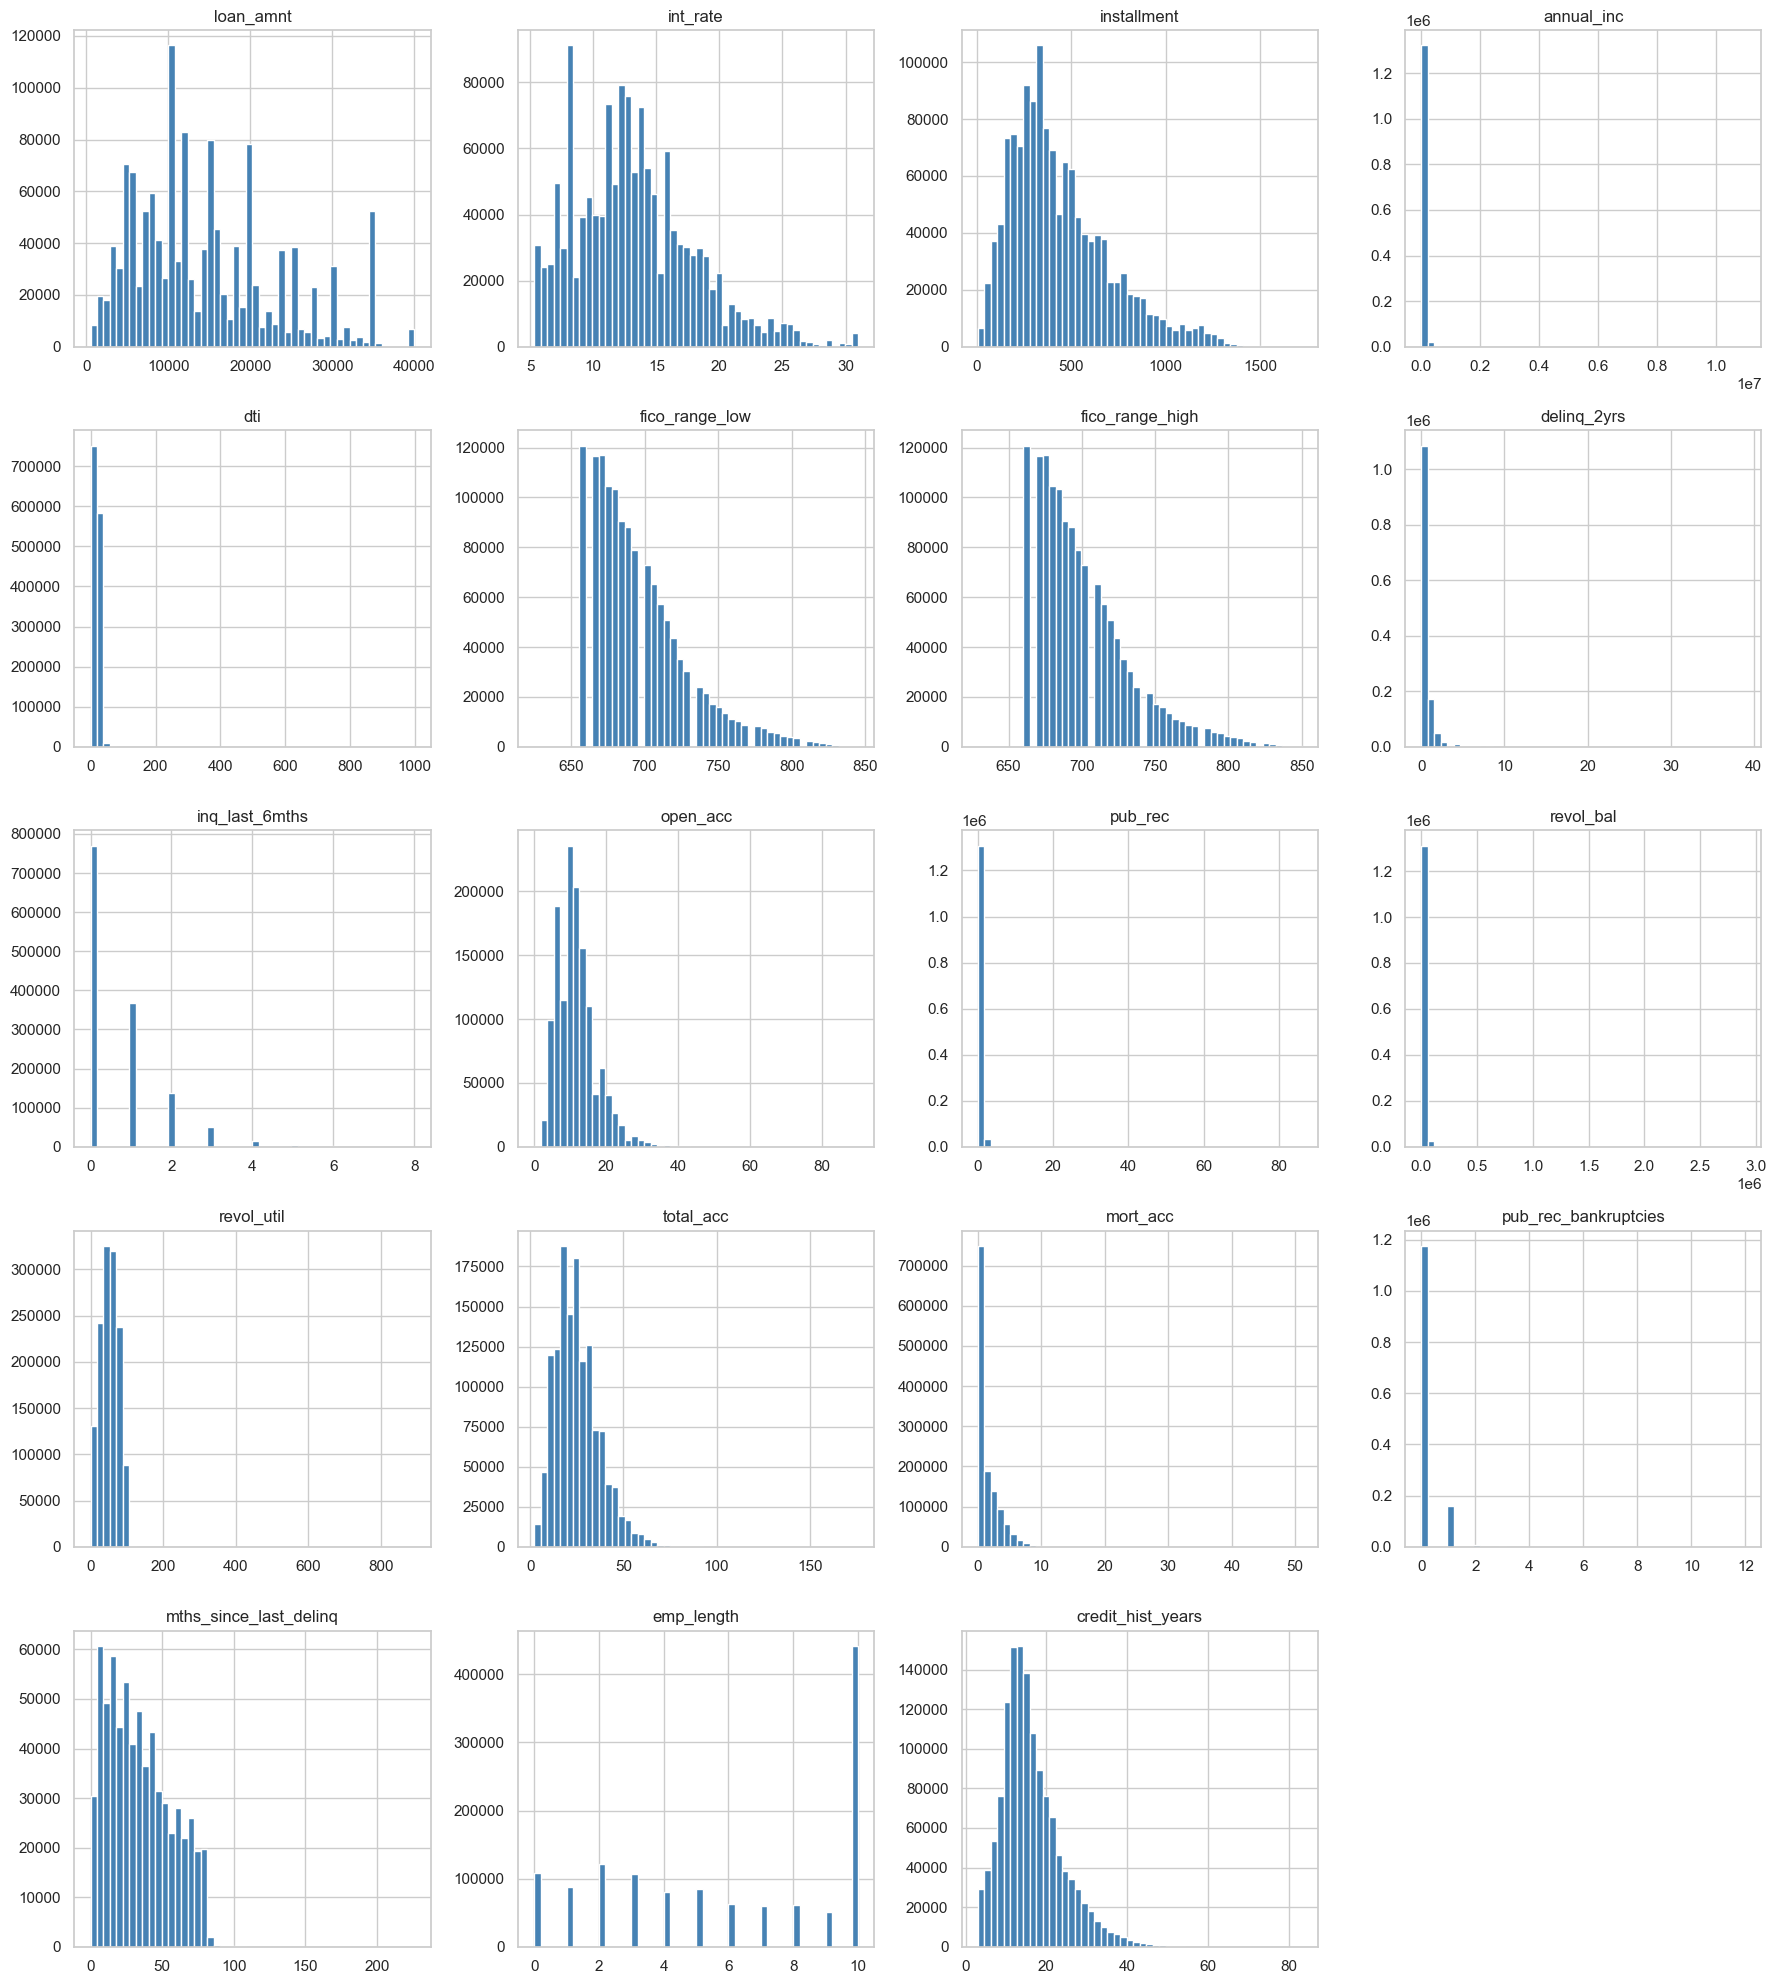

In [15]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))
for ax, c in zip(axes.flat, num_cols):
    ax.hist(df[c].dropna(), bins=50, color='steelblue', edgecolor='white')
    ax.set_title(c)
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Diagramas de caja (boxplots)** para ver asimetría y outliers.

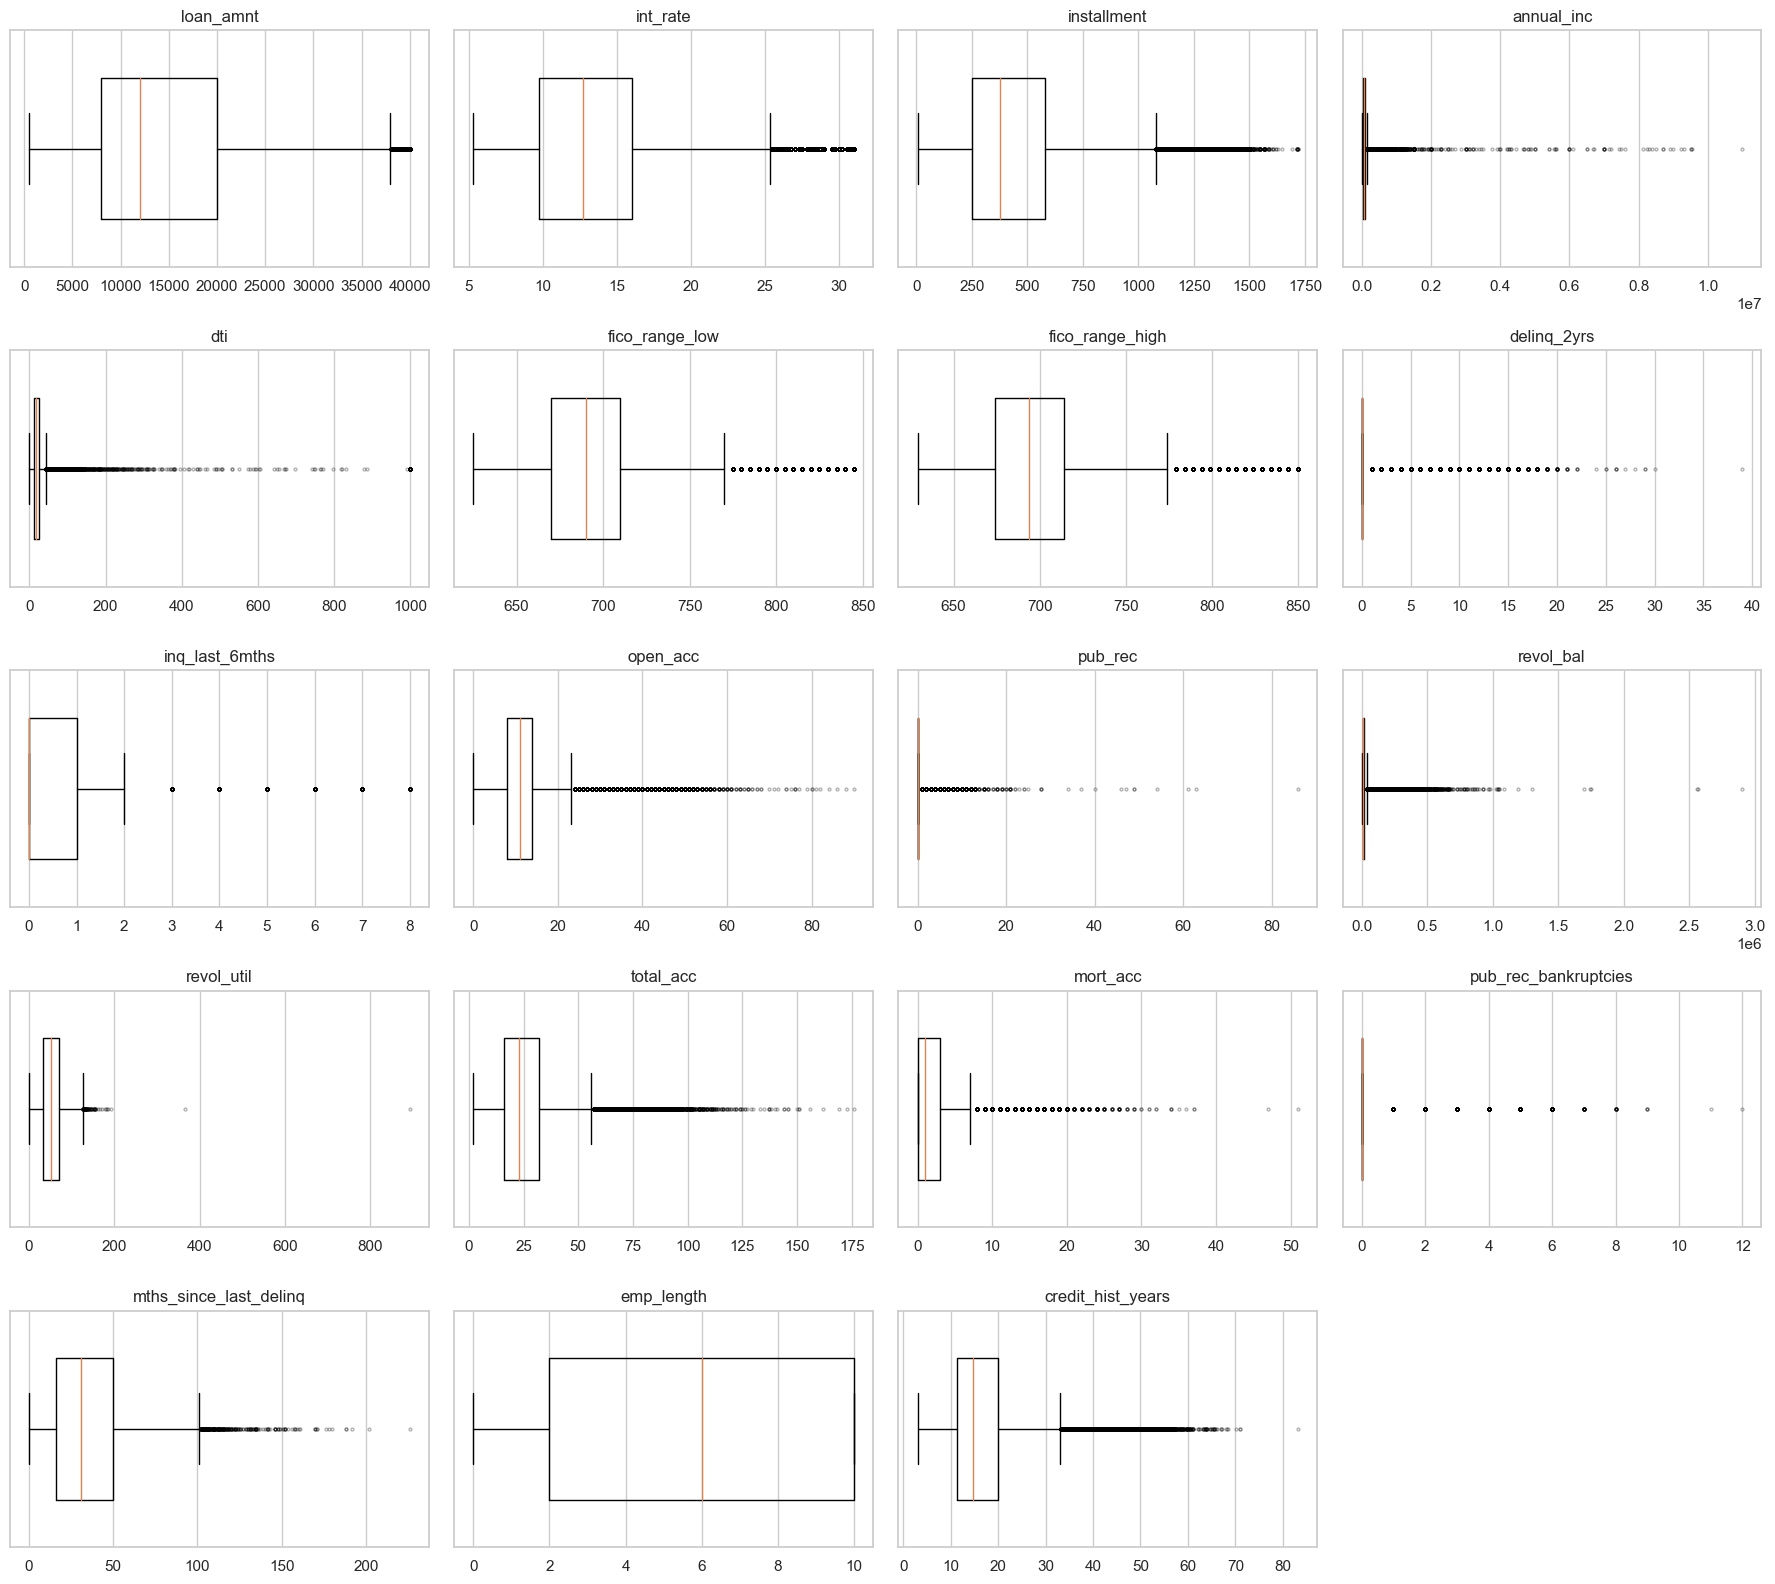

In [16]:
fig, axes = plt.subplots(5, 4, figsize=(18, 16))
for ax, c in zip(axes.flat, num_cols):
    ax.boxplot(df[c].dropna(), vert=False, widths=0.6,
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(c)
    ax.set_yticks([])
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Comentario de histogramas y boxplots.**

- `annual_inc`, `dti`, `revol_bal`, `pub_rec` y `delinq_2yrs` aparecen como una sola barra pegada a la izquierda. Los valores extremos estiran el eje, y el boxplot muestra una nube de puntos atípicos por encima del bigote.
- `loan_amnt` tiene picos en valores redondos (10 000, 15 000, 20 000, ...): los solicitantes piden montos redondos.
- `int_rate` es unimodal con ligera cola a la derecha.
- `fico_range_*` es asimétrica a la derecha y la gran mayoría de los préstamos está por encima de ≈ 660 (lo que sugiere un puntaje mínimo exigido por Lending Club). Solo unos pocos casos llegan hasta 625-629.
- `emp_length` tiene una gran acumulación en **10**, porque la categoría original es "10+ years" y agrupa a todos los que llevan 10 años o más.
- `mths_since_last_delinq` y `credit_hist_years` tienen forma aproximadamente log-normal.

**Normalidad.** La prueba de Shapiro-Wilk de `scipy` solo da p-valores confiables hasta $n \approx 5000$. Por eso se usa la prueba de **D'Agostino-Pearson** (`stats.normaltest`), que combina asimetría y curtosis y funciona con muestras grandes. Además se sigue una regla práctica: si $|\text{asimetría}| > 1$, la distribución es muy asimétrica y conviene considerar una transformación (log o Box-Cox).

In [17]:
filas = []
for c in num_cols:
    s = df[c].dropna()
    k2, p = stats.normaltest(s)
    asim = s.skew()
    if abs(asim) > 1 and s.min() >= 0:
        sugerencia = 'log(1+x) / Box-Cox'
    elif abs(asim) > 1:
        sugerencia = 'Yeo-Johnson (tiene valores <= 0)'
    else:
        sugerencia = 'no necesaria'
    filas.append({'variable': c, 'asimetria': asim, 'curtosis': s.kurt(),
                  'estadistico K2': k2, 'p-value': p, 'transformacion sugerida': sugerencia})
tabla_normalidad = pd.DataFrame(filas).set_index('variable').sort_values('asimetria', ascending=False)
tabla_normalidad.round(3)

,asimetria,curtosis,estadistico K2,p-value,transformacion sugerida
variable,,,,,
annual_inc,46.318,4812.432,4130262.893,0.0,log(1+x) / Box-Cox
dti,27.111,2112.691,3380631.886,0.0,Yeo-Johnson (tiene valores <= 0)
revol_bal,13.750,720.854,2540183.330,0.0,log(1+x) / Box-Cox
pub_rec,11.556,743.521,2364252.368,0.0,log(1+x) / Box-Cox
delinq_2yrs,5.604,58.692,1493218.995,0.0,log(1+x) / Box-Cox
pub_rec_bankruptcies,3.441,20.029,1014035.423,0.0,log(1+x) / Box-Cox
inq_last_6mths,1.696,3.289,429630.794,0.0,log(1+x) / Box-Cox
mort_acc,1.637,5.193,447700.173,0.0,log(1+x) / Box-Cox
open_acc,1.296,3.344,335533.993,0.0,log(1+x) / Box-Cox


Efecto de la transformación `log(1+x)` sobre las variables más asimétricas:

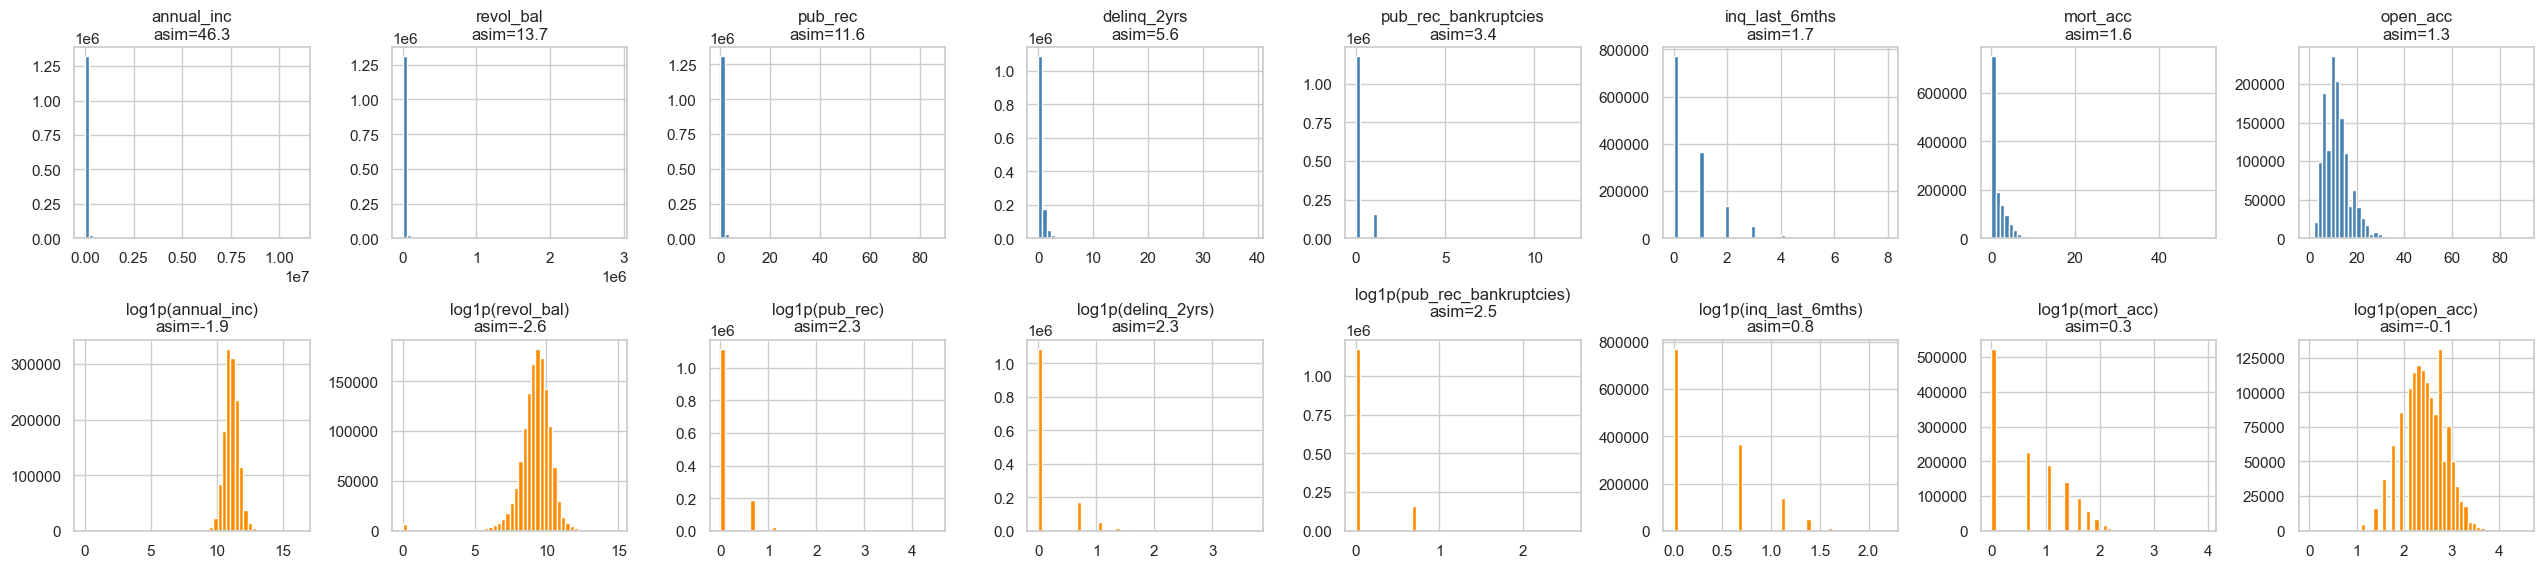

In [18]:
asimetricas = tabla_normalidad[tabla_normalidad['transformacion sugerida'] == 'log(1+x) / Box-Cox'].index[:8]
fig, axes = plt.subplots(2, len(asimetricas), figsize=(3.2 * len(asimetricas), 6))
for j, c in enumerate(asimetricas):
    s = df[c].dropna()
    axes[0, j].hist(s, bins=50, color='steelblue')
    axes[0, j].set_title(f'{c}\nasim={s.skew():.1f}')
    axes[1, j].hist(np.log1p(s), bins=50, color='darkorange')
    axes[1, j].set_title(f'log1p({c})\nasim={np.log1p(s).skew():.1f}')
plt.tight_layout()
plt.show()

**Comentario sobre normalidad y transformaciones.**

- La prueba de D'Agostino-Pearson rechaza la normalidad en **todas** las variables (p ≈ 0). Con 1.3 millones de datos era de esperarse: la prueba detecta hasta la mínima desviación, así que se usa la asimetría como criterio práctico.
- **Transformación recomendada (log(1+x) o Box-Cox):** `annual_inc`, `revol_bal`, `installment`, `mort_acc`, `open_acc`, `inq_last_6mths` y `credit_hist_years`. La figura lo confirma: la asimetría de `annual_inc` pasa de 46 a valores cercanos a 0 con `log1p`, y `revol_bal` queda casi simétrica.
- `dti` tiene valores ≤ 0 (−1), así que `log` no aplica directamente. Primero hay que corregir los valores inválidos (−1 y 999) y luego aplicar `log1p` o Yeo-Johnson.
- En `pub_rec`, `delinq_2yrs` y `pub_rec_bankruptcies` el log no arregla nada, porque la mayoría de los valores son 0. Se recomienda **binarizarlas** (`tiene_registro = valor > 0`).
- Para `fico_range_*` la asimetría (1.29) se debe al límite inferior de la política de crédito. Basta con estandarizar (`StandardScaler`).
- Estas transformaciones importan sobre todo para los modelos lineales (`LogisticRegression`, `LinearSVC`) y para `NaiveBayes` gaussiano. Los árboles (`DecisionTree`, `RandomForest`, `GBT`) son invariantes a transformaciones monótonas.

**Tasa de faltantes por variable numérica** y umbral de decisión. Se toma un umbral del **30 %**: por encima de él la variable es candidata a eliminarse o a un tratamiento especial.

In [19]:
faltantes_num = (100 * df[num_cols].isna().mean()).sort_values(ascending=False).round(3)
print(faltantes_num[faltantes_num > 0])
print('\nVariables numéricas con más de 30 % de faltantes:', list(faltantes_num[faltantes_num > 30].index))

mths_since_last_delinq    50.453
emp_length                 5.836
mort_acc                   3.515
revol_util                 0.064
pub_rec_bankruptcies       0.052
dti                        0.028
dtype: float64

Variables numéricas con más de 30 % de faltantes: ['mths_since_last_delinq']


**Comentario.** Solo `mths_since_last_delinq` supera el umbral del 30 % (50.5 %). Sin embargo, su faltante **no es un error**: el campo está vacío cuando el solicitante **nunca ha tenido una morosidad**, así que el nulo contiene información. En lugar de eliminarla se recomienda crear un indicador `nunca_moroso = mths_since_last_delinq.isna()` y luego imputar el valor numérico (ver 9.10.4.1.4). Las demás variables tienen menos de 6 % de faltantes y se pueden imputar con la mediana.

##### Variables categóricas

Para cada variable se reporta la frecuencia absoluta y relativa de cada categoría. Se marcan las categorías con menos del 1 % de los datos, que podrían agruparse en `"Otros"`.

In [20]:
for c in cat_cols:
    frec = df[c].value_counts(dropna=False)
    tabla = pd.DataFrame({'frecuencia': frec, '% relativo': (100 * frec / len(df)).round(3)})
    tabla['< 1 %'] = np.where(tabla['% relativo'] < 1, 'sí', '')
    print(f'===== {c}  ({df[c].nunique()} categorías, faltantes: {df[c].isna().sum()}) =====')
    with pd.option_context('display.max_rows', 100):
        display(tabla)

===== term  (2 categorías, faltantes: 0) =====


,frecuencia,% relativo,< 1 %
term,,,
36 months,1020743,75.874,
60 months,324567,24.126,


===== grade  (7 categorías, faltantes: 0) =====


,frecuencia,% relativo,< 1 %
grade,,,
B,392741,29.193,
C,381686,28.372,
A,235090,17.475,
D,200953,14.937,
E,93650,6.961,
F,32058,2.383,
G,9132,0.679,sí


===== sub_grade  (35 categorías, faltantes: 0) =====


...

,frecuencia,% relativo,< 1 %
addr_state,,,
CA,196528,14.608,
TX,110169,8.189,
NY,109842,8.165,
FL,95606,7.107,
IL,51720,3.844,
NJ,48449,3.601,
PA,45522,3.384,
OH,43842,3.259,
GA,43376,3.224,


===== application_type  (2 categorías, faltantes: 0) =====


,frecuencia,% relativo,< 1 %
application_type,,,
Individual,1319510,98.082,
Joint App,25800,1.918,


===== initial_list_status  (2 categorías, faltantes: 0) =====


,frecuencia,% relativo,< 1 %
initial_list_status,,,
w,784010,58.277,
f,561300,41.723,


In [21]:
resumen_cat = pd.DataFrame({
    'n_categorias': [df[c].nunique() for c in cat_cols],
    'categorias < 1 %': [int((df[c].value_counts(normalize=True) < 0.01).sum()) for c in cat_cols],
    '% faltantes': [100 * df[c].isna().mean() for c in cat_cols]}, index=cat_cols)
resumen_cat

,n_categorias,categorias < 1 %,% faltantes
term,2,0,0.0
grade,7,1,0.0
sub_grade,35,10,0.0
home_ownership,6,3,0.0
verification_status,3,0,0.0
purpose,14,6,0.0
addr_state,51,23,0.0
application_type,2,0,0.0
initial_list_status,2,0,0.0


**Gráficos de barras** de las variables categóricas.

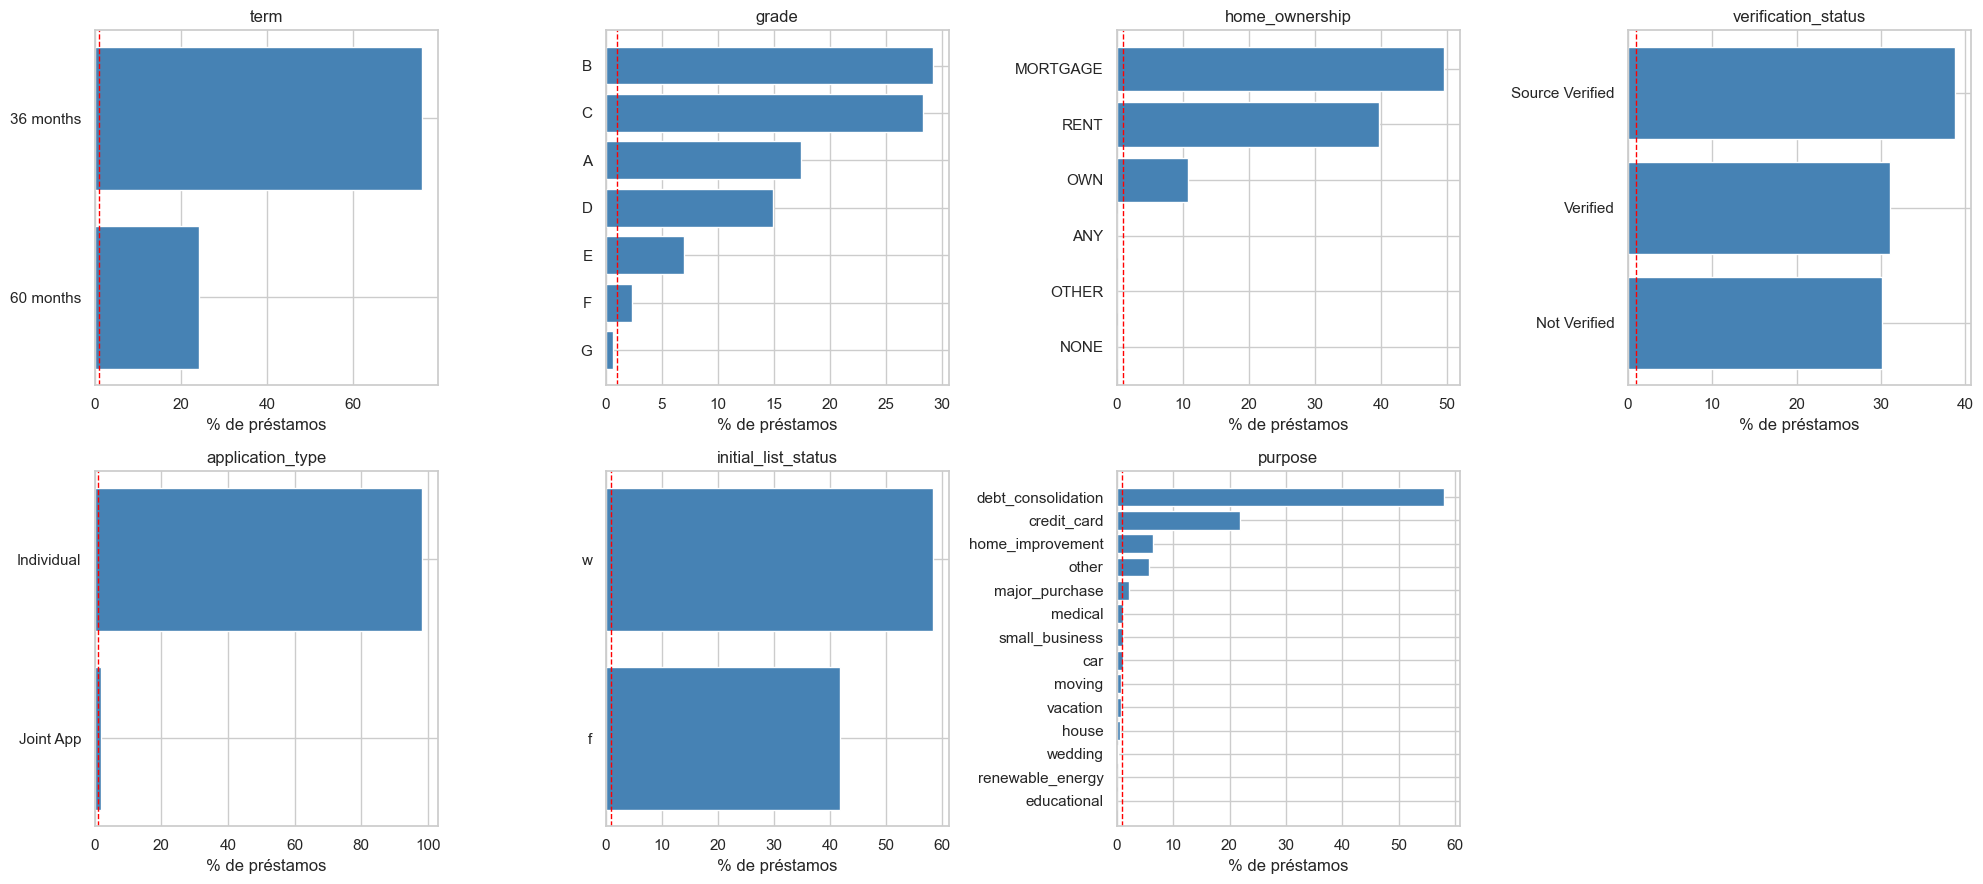

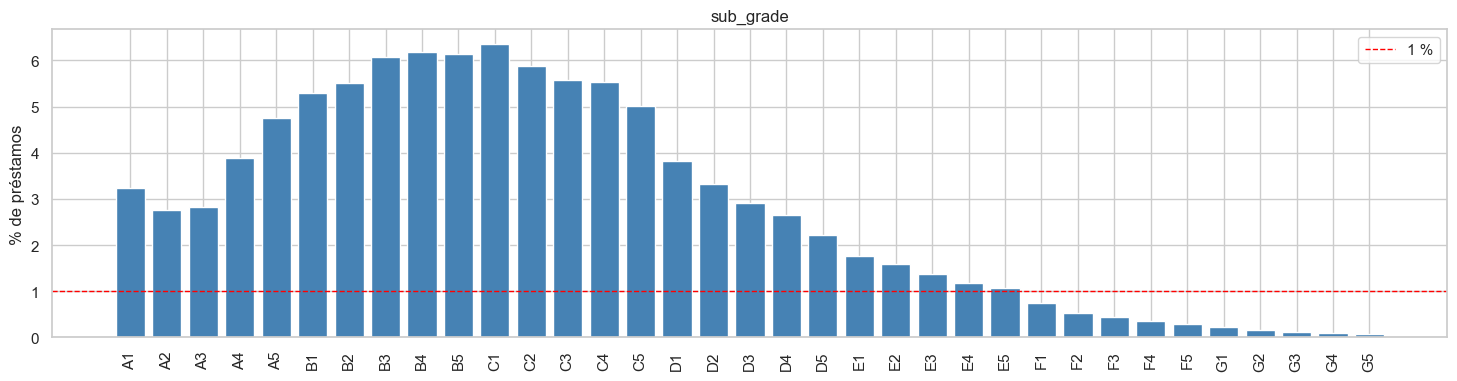

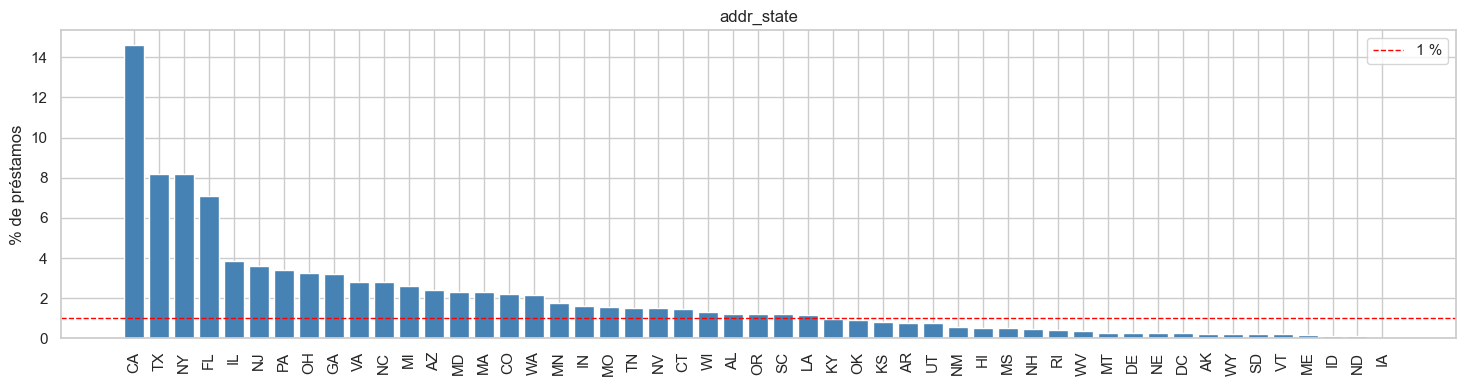

In [22]:
pocas = ['term', 'grade', 'home_ownership', 'verification_status',
         'application_type', 'initial_list_status', 'purpose']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, c in zip(axes.flat, pocas):
    frec = df[c].value_counts(normalize=True).sort_values() * 100
    ax.barh(frec.index.astype(str), frec.values, color='steelblue')
    ax.axvline(1, color='red', ls='--', lw=1)
    ax.set_title(c)
    ax.set_xlabel('% de préstamos')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

for c in ['sub_grade', 'addr_state']:
    frec = df[c].value_counts(normalize=True) * 100
    if c == 'sub_grade':
        frec = frec.sort_index()
    plt.figure(figsize=(18, 4))
    plt.bar(frec.index.astype(str), frec.values, color='steelblue')
    plt.axhline(1, color='red', ls='--', lw=1, label='1 %')
    plt.title(c)
    plt.ylabel('% de préstamos')
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()

**Comentario sobre las variables categóricas.**

- **Faltantes:** ninguna variable categórica del EDA tiene valores nulos, así que no se necesita moda ni categoría "Desconocido".
- **Categorías de baja frecuencia (< 1 %):**
  - `home_ownership`: `ANY` (286), `OTHER` (144) y `NONE` (48) suman solo el 0.04 %. Se recomienda agruparlas en **`OTHER`**, porque las tres significan "ni hipoteca, ni renta, ni propia".
  - `purpose`: `moving`, `vacation`, `house`, `wedding`, `renewable_energy` y `educational` (< 1 % cada una) pueden unirse en `other`, que ya existe (5.8 %).
  - `addr_state`: 23 estados tienen < 1 %; **IA** solo tiene 7 préstamos. En lugar de 51 dummies se puede agrupar en "Otros" o por región.
  - `grade` G (0.68 %) y las subcategorías F1-G5 son poco frecuentes, pero no deben agruparse con otras, porque tienen las tasas de default más altas (ver análisis bidimensional).
- **Redundancias:**
  - `sub_grade` es una subdivisión de `grade` (A1-A5 ⊂ A, ...). Contienen la misma información y **conviene usar solo una**.
  - En `verification_status`, "Verified" y "Source Verified" indican que el ingreso fue verificado (la segunda verifica la fuente). Podrían unificarse en "Verificado" si se busca simplificar.
- **Distribuciones dominantes:** `debt_consolidation` es el 58 % de los préstamos y, junto con `credit_card`, el 80 %. El 76 % son a 36 meses, el 98 % son `Individual` y California concentra el 14.6 %.

##### Variable objetivo (`default`)

,clase,n,%
0,0 = Fully Paid,1076751,80.04
1,1 = Charged Off,268559,19.96


Razón de desbalance (0:1) = 4.01 : 1


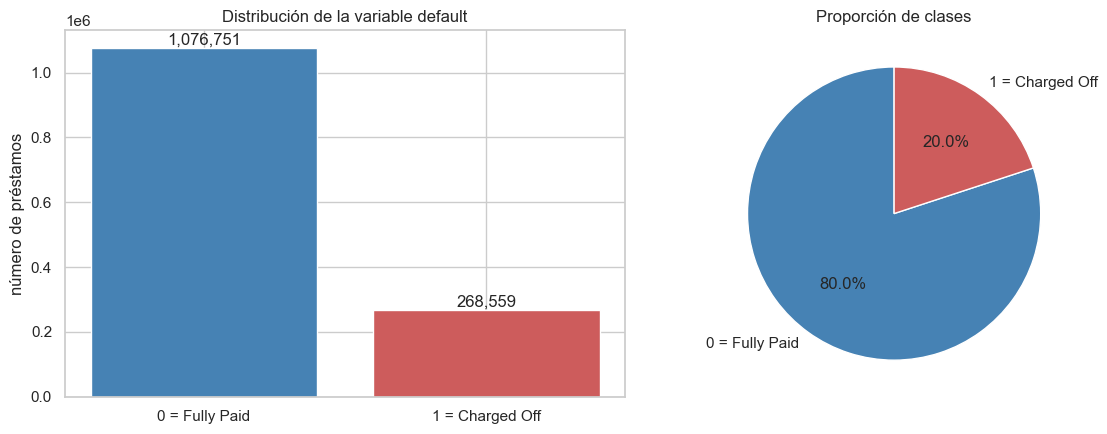

In [23]:
conteo = df['default'].value_counts().sort_index()
tabla_default = pd.DataFrame({'clase': ['0 = Fully Paid', '1 = Charged Off'],
                              'n': conteo.values,
                              '%': (100 * conteo / conteo.sum()).round(2).values})
display(tabla_default)
print(f'Razón de desbalance (0:1) = {conteo[0] / conteo[1]:.2f} : 1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(tabla_default['clase'], tabla_default['n'], color=['steelblue', 'indianred'])
for i, v in enumerate(tabla_default['n']):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')
axes[0].set_title('Distribución de la variable default')
axes[0].set_ylabel('número de préstamos')
axes[1].pie(tabla_default['n'], labels=tabla_default['clase'], autopct='%1.1f%%',
            colors=['steelblue', 'indianred'], startangle=90)
axes[1].set_title('Proporción de clases')
plt.tight_layout()
plt.show()

**Comentario sobre la variable objetivo.** Hay **1 076 751 (80.04 %)** préstamos pagados y **268 559 (19.96 %)** en default, una razón aproximada de **4 : 1**. Es un **desbalance moderado**, no extremo, con impacto directo en el modelado:

- Un modelo trivial que siempre prediga "0" tendría 80 % de *accuracy*. Por eso la exactitud no sirve como métrica principal; hay que usar **AUC-ROC** (que además es la métrica de la prueba de DeLong), *precision*, *recall*, F1 de la clase 1 o *balanced accuracy*.
- La partición train/test debe ser **estratificada** por `default` (lo exige 9.10.4.2.1), para que ambos conjuntos mantengan el 20 %.
- Se puede compensar con `class_weight='balanced'` (scikit-learn) o una columna de pesos (`weightCol` en PySpark). Estas opciones no alteran el número de filas, a diferencia de un submuestreo, que el enunciado prohíbe.
- El umbral de decisión 0.5 probablemente no sea el óptimo. Conviene ajustarlo con la curva precision-recall.

#### 9.10.4.1.3. Análisis bidimensional (relaciones entre variables)

##### Variables numéricas vs `default`

**Boxplots comparativos por clase** (todos los datos):

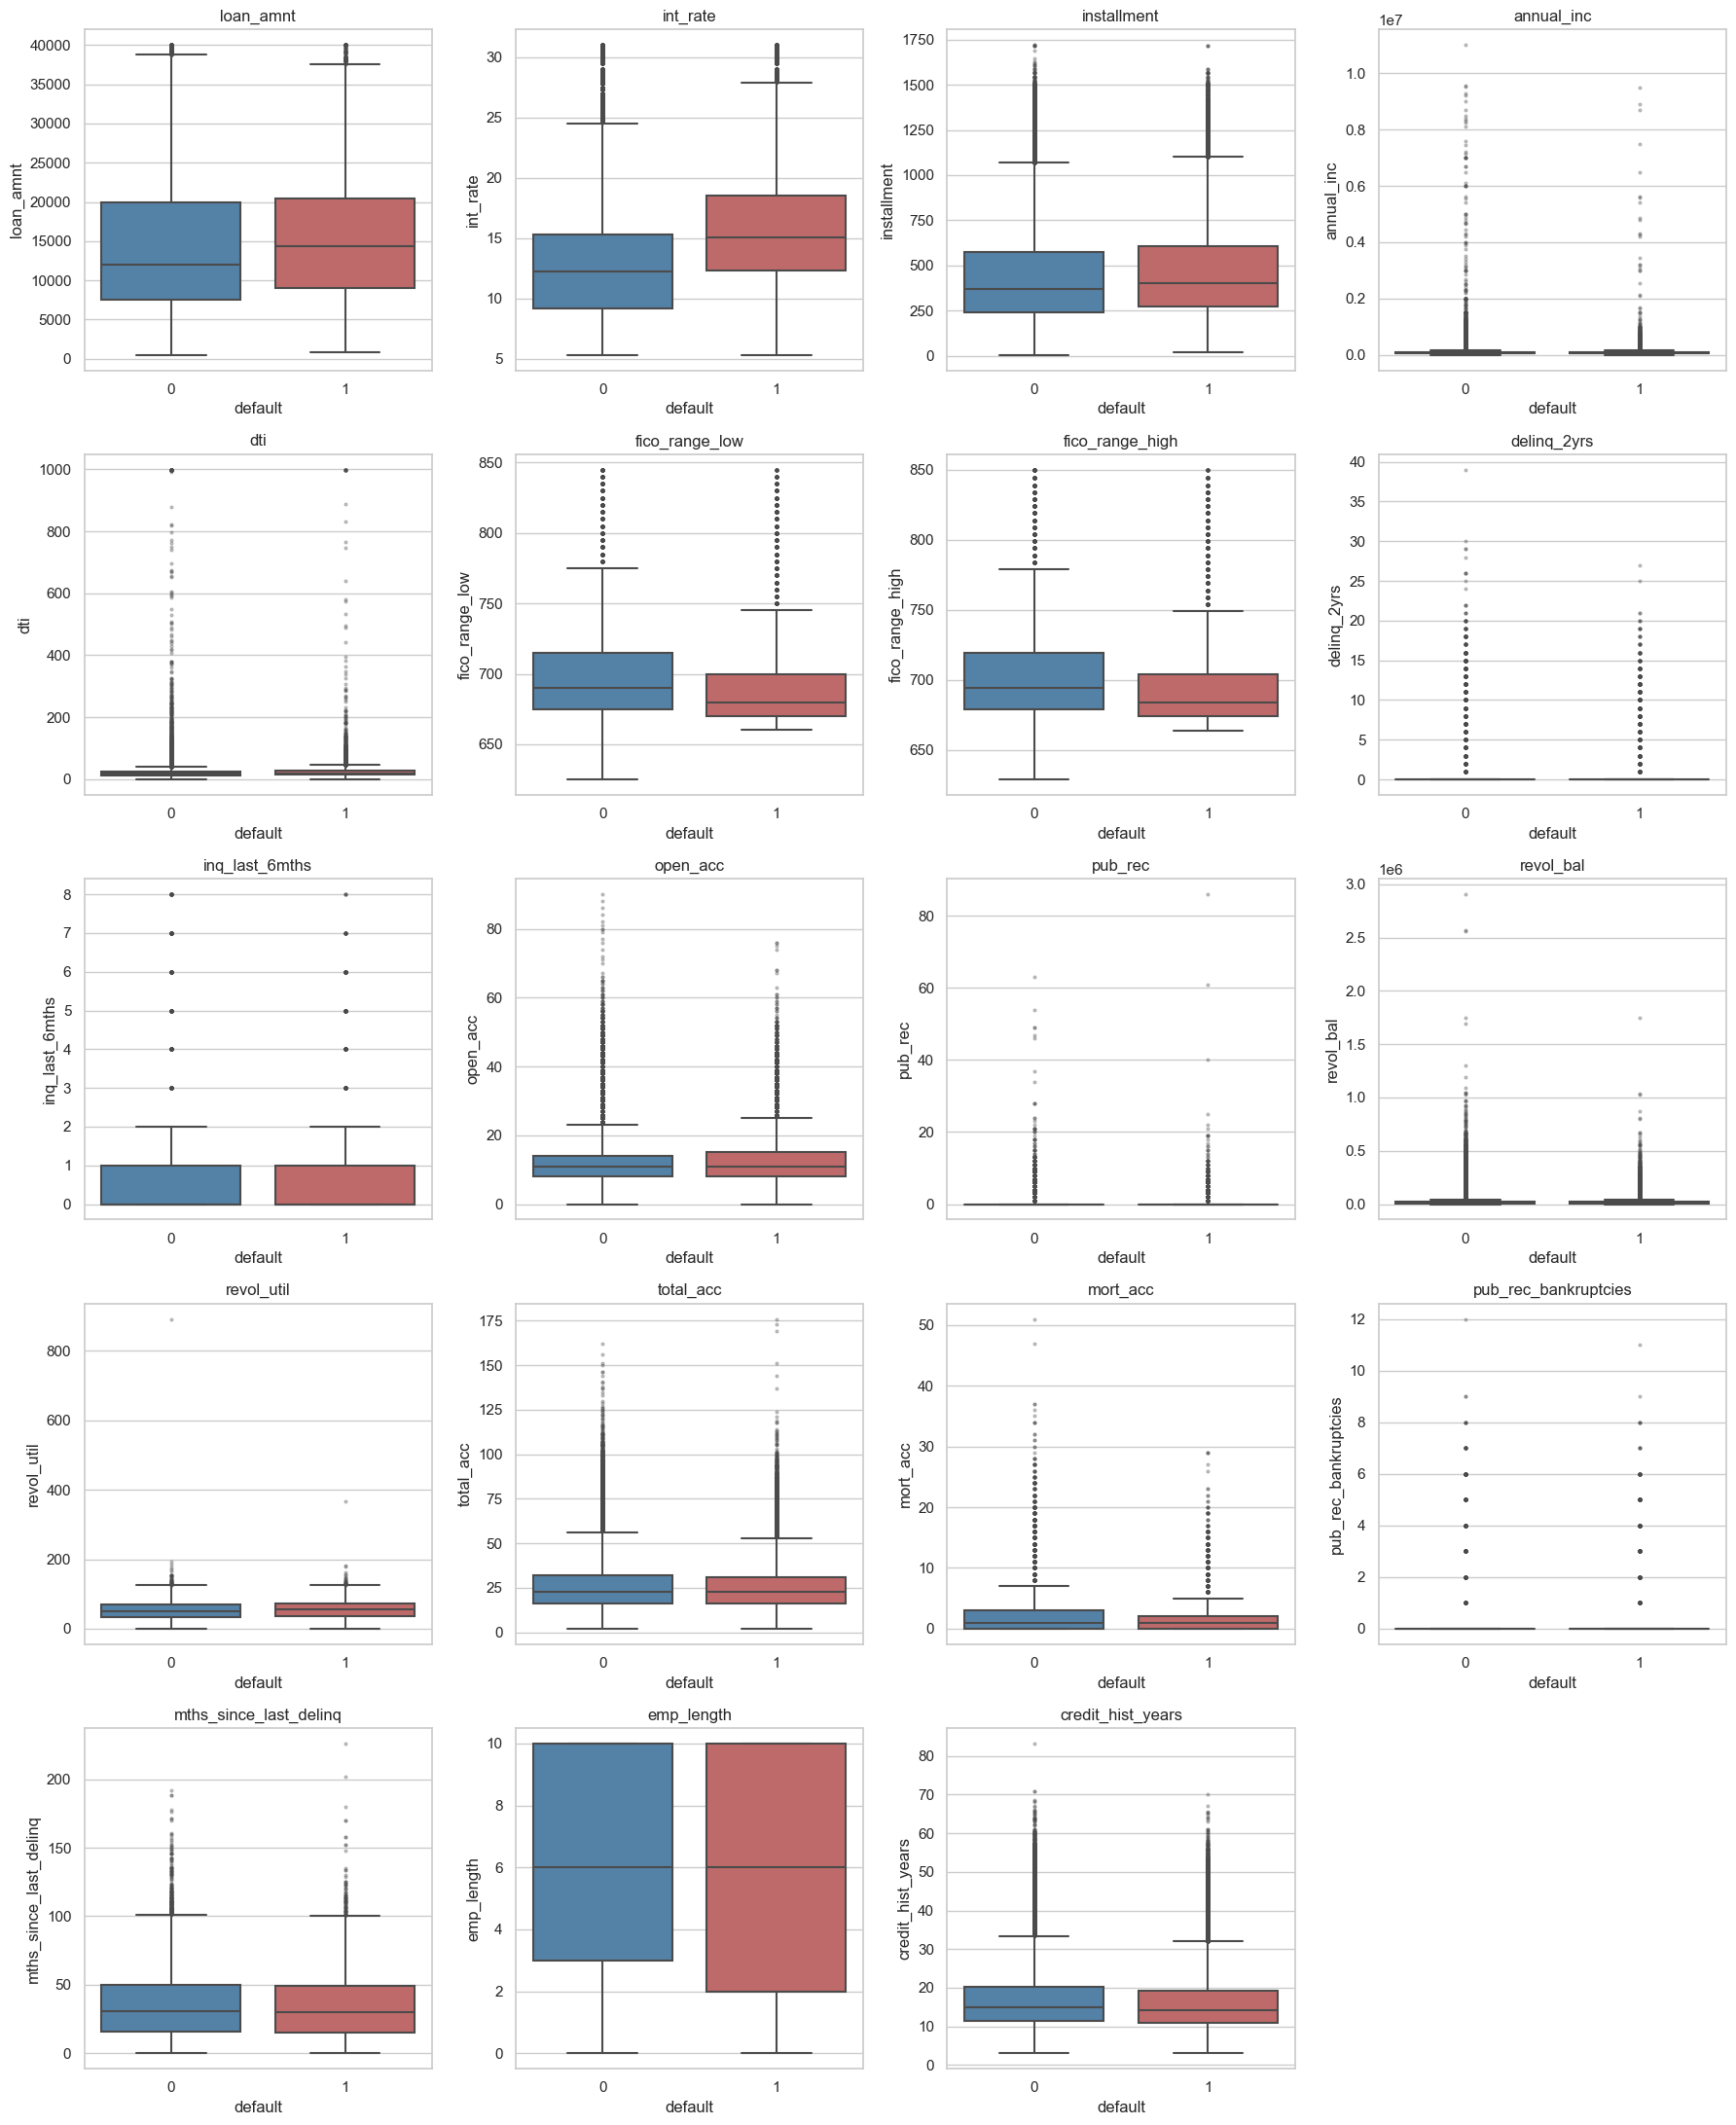

In [24]:
fig, axes = plt.subplots(5, 4, figsize=(18, 22))
for ax, c in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x='default', y=c, ax=ax, palette=['steelblue', 'indianred'],
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(c)
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Violin plots** de las variables más relevantes. Para que la forma de la densidad sea legible, el gráfico se recorta entre los percentiles 1 y 99 de cada variable. El recorte es **solo visual**: los cálculos usan todos los datos.

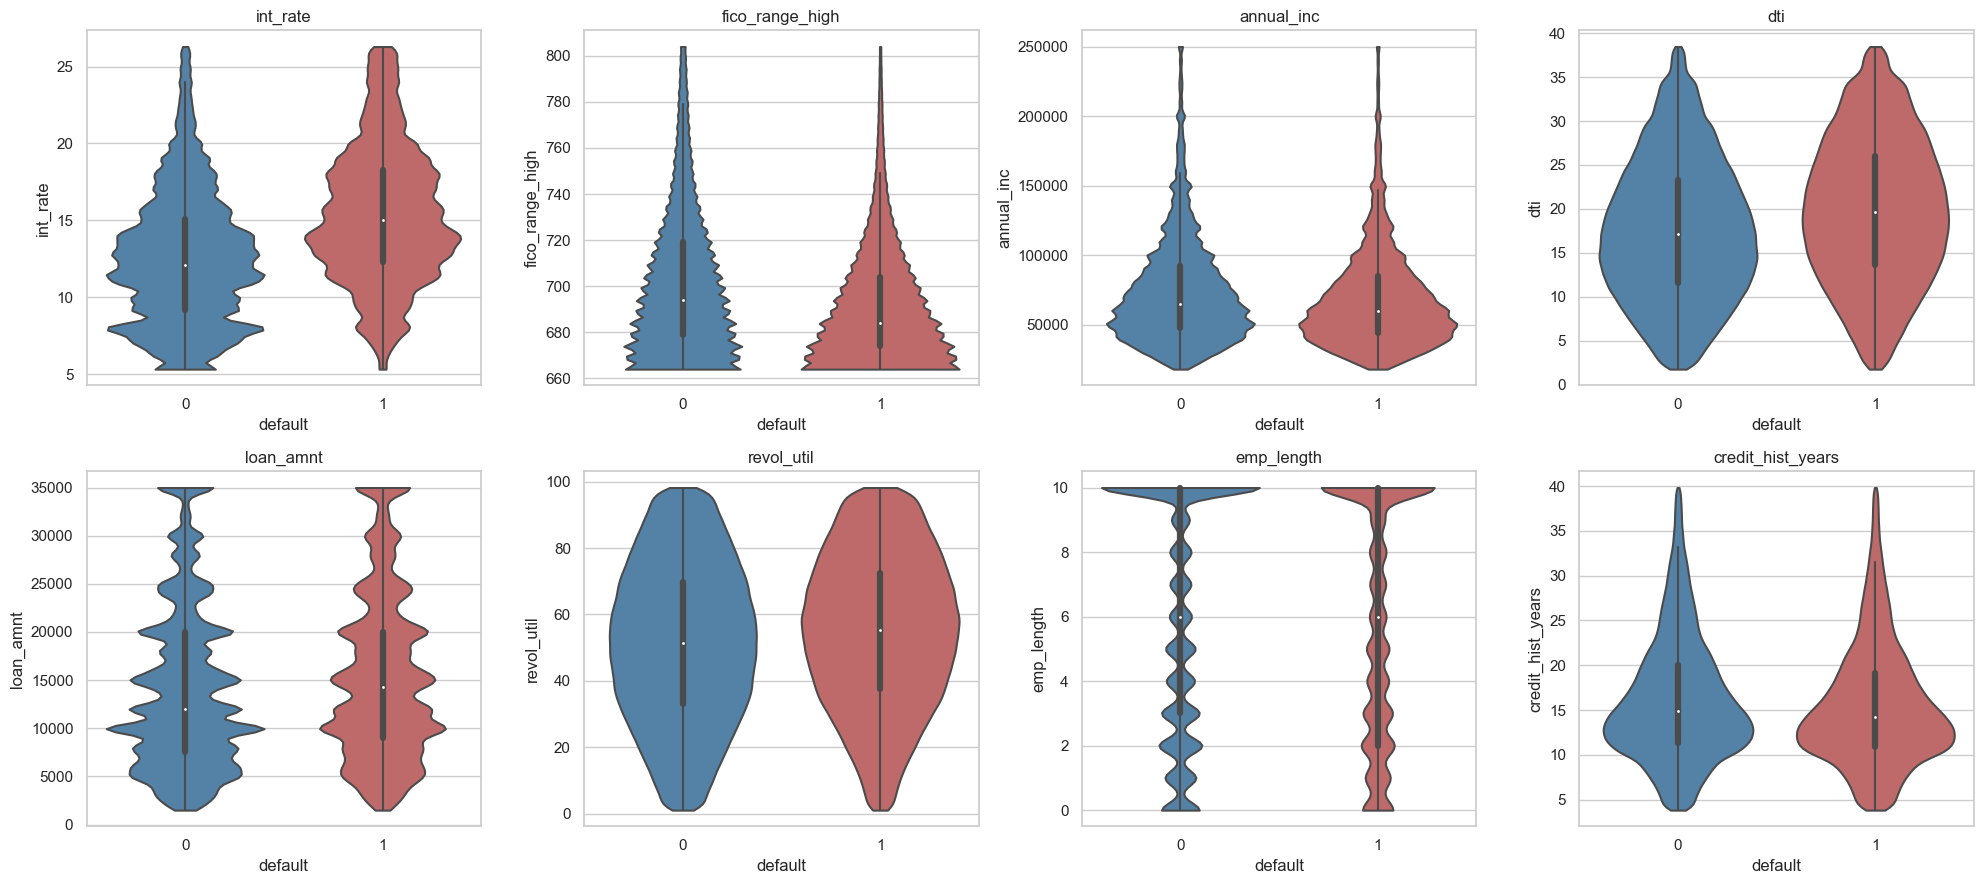

In [25]:
clave = ['int_rate', 'fico_range_high', 'annual_inc', 'dti',
         'loan_amnt', 'revol_util', 'emp_length', 'credit_hist_years']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, c in zip(axes.flat, clave):
    p1, p99 = df[c].quantile([0.01, 0.99])
    sub = df.loc[df[c].between(p1, p99), [c, 'default']]
    sns.violinplot(data=sub, x='default', y=c, ax=ax, cut=0,
                   palette=['steelblue', 'indianred'])
    ax.set_title(c)
plt.tight_layout()
plt.show()

**Comentario de boxplots y violin plots por clase.**

- **`int_rate`** es la variable con mayor separación: la mediana pasa de 12.2 % (pagados) a 15.1 % (default), y toda la caja del grupo 1 está desplazada hacia arriba. Tiene sentido: la tasa ya refleja el riesgo que Lending Club asignó al solicitante.
- **`fico_range_high`:** los que caen en default tienen puntajes más bajos (mediana 684 vs 694) y menos dispersión hacia arriba. El violin muestra más densidad en la zona de 660-700.
- **`dti`, `revol_util` y `loan_amnt`** son ligeramente mayores en el grupo de default. **`annual_inc`, `mort_acc` y `credit_hist_years`**, en cambio, son ligeramente menores.
- `emp_length`, `total_acc`, `open_acc` y `mths_since_last_delinq` tienen cajas prácticamente idénticas en ambas clases, así que por sí solas aportan poca información.
- Los outliers aparecen en **ambas** clases con patrones parecidos. No son exclusivos de los morosos, lo que refuerza que se deben transformar o recortar (*winsorizar*) y no eliminar.

**Pruebas de diferencia entre clases.** Para cada variable numérica se calculan:

- La diferencia de medias entre `default = 1` y `default = 0`.
- La prueba **t de Student** en su versión de Welch (`equal_var=False`), que no supone varianzas iguales.
- La prueba de **Mann-Whitney U**, que no supone normalidad. Es la adecuada aquí, porque ninguna variable es normal.
- La correlación **punto-biserial** $r_{pb}$ entre la variable y `default`.

Con $n > 1.3$ millones casi cualquier diferencia sale "estadísticamente significativa". Por eso, para juzgar la **relevancia práctica** se usan la magnitud de $r_{pb}$ y la diferencia de medianas, y no solo el p-value.

In [26]:
filas = []
for c in num_cols:
    datos = df[[c, 'default']].dropna()
    g0 = datos.loc[datos['default'] == 0, c]
    g1 = datos.loc[datos['default'] == 1, c]
    t, p_t = stats.ttest_ind(g1, g0, equal_var=False)
    u, p_u = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    r, p_r = stats.pointbiserialr(datos['default'], datos[c])
    filas.append({'variable': c, 'media_0': g0.mean(), 'media_1': g1.mean(),
                  'dif_medias': g1.mean() - g0.mean(),
                  'mediana_0': g0.median(), 'mediana_1': g1.median(),
                  't (Welch)': t, 'p t': p_t, 'p Mann-Whitney': p_u,
                  'r punto-biserial': r, 'p r': p_r,
                  'significativa (p<0.05)': 'sí' if p_u < 0.05 else 'no'})
tabla_pruebas = pd.DataFrame(filas).set_index('variable')
tabla_pruebas = tabla_pruebas.reindex(tabla_pruebas['r punto-biserial'].abs().sort_values(ascending=False).index)
tabla_pruebas.round(4)

,media_0,media_1,dif_medias,mediana_0,mediana_1,t (Welch),p t,p Mann-Whitney,r punto-biserial,p r,significativa (p<0.05)
variable,,,,,,,,,,,
int_rate,12.6233,15.7107,3.0874,12.2300,15.0500,295.9698,0.0,0.0,0.2588,0.0,sí
fico_range_low,698.2639,687.8501,-10.4138,690.0000,680.0000,-175.8143,0.0,0.0,-0.1307,0.0,sí
fico_range_high,702.2641,691.8502,-10.4139,694.0000,684.0000,-175.8135,0.0,0.0,-0.1307,0.0,sí
dti,17.8116,20.1712,2.3596,17.1100,19.7600,93.8212,0.0,0.0,0.0845,0.0,sí
mort_acc,1.7465,1.3710,-0.3754,1.0000,1.0000,-91.7823,0.0,0.0,-0.0753,0.0,sí
loan_amnt,14134.3698,15565.0554,1430.6856,12000.0000,14350.0000,75.4978,0.0,0.0,0.0656,0.0,sí
inq_last_6mths,0.6244,0.7780,0.1536,0.0000,0.0000,71.6239,0.0,0.0,0.0655,0.0,sí
revol_util,51.0747,54.7584,3.6838,51.3000,55.5000,71.0796,0.0,0.0,0.0600,0.0,sí
installment,431.3232,465.1480,33.8248,368.2600,402.8300,59.7698,0.0,0.0,0.0517,0.0,sí


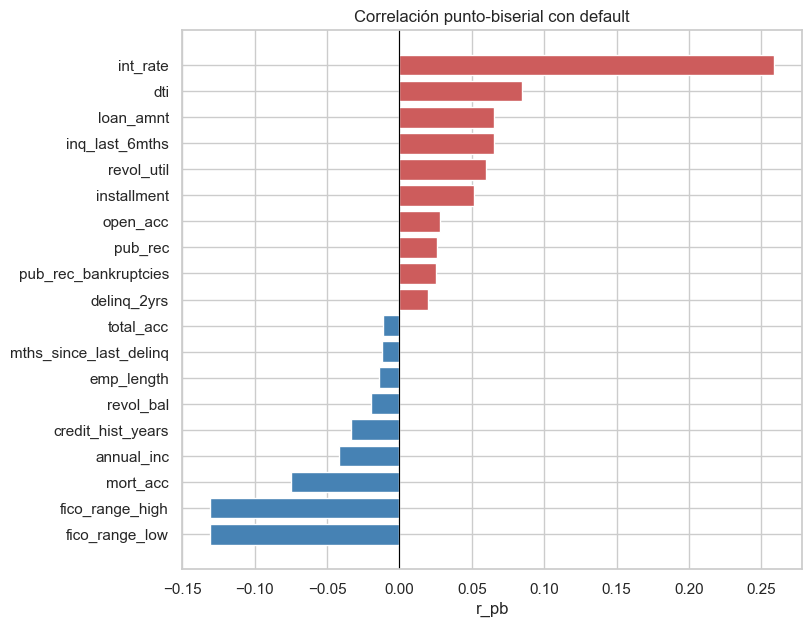

In [27]:
r_pb = tabla_pruebas['r punto-biserial'].sort_values()
plt.figure(figsize=(8, 7))
plt.barh(r_pb.index, r_pb.values, color=np.where(r_pb.values > 0, 'indianred', 'steelblue'))
plt.axvline(0, color='black', lw=0.8)
plt.title('Correlación punto-biserial con default')
plt.xlabel('r_pb')
plt.show()

**Comentario de las pruebas.**

- **Todas** las diferencias son estadísticamente significativas (p ≈ 0 en t de Welch y en Mann-Whitney), incluso en variables cuyas medianas son idénticas (`emp_length`, `total_acc`). Con n = 1.3 M el p-value deja de discriminar: hasta una diferencia de 0.1 años sale significativa.
- Por eso la **relevancia** se juzga con $r_{pb}$:
  - **Mayor asociación:** `int_rate` (r = **0.259**), `fico_range_low/high` (r = **−0.131**), `dti` (0.085), `mort_acc` (−0.075), `loan_amnt` (0.066), `inq_last_6mths` (0.066) y `revol_util` (0.060).
  - **Asociación casi nula (|r| < 0.03):** `total_acc`, `mths_since_last_delinq`, `emp_length`, `delinq_2yrs`, `revol_bal`, `pub_rec`, `pub_rec_bankruptcies` y `open_acc`.
- Todas las correlaciones son **débiles** (|r| < 0.3). Ninguna variable predice el default por sí sola, así que los modelos tendrán que combinar muchas variables y posiblemente relaciones no lineales. Es razonable esperar un AUC moderado, no cercano a 1.
- **Signos:** a mayor tasa, deuda relativa, monto y consultas de crédito recientes, mayor riesgo. A mayor FICO, ingreso, número de hipotecas y antigüedad crediticia, menor riesgo. Todos los signos son coherentes con la intuición financiera.

##### Variables categóricas vs `default`

**Tablas de contingencia** con la tasa de default (% de `Charged Off`) de cada categoría:

In [28]:
tasa_global = 100 * df['default'].mean()
print(f'Tasa global de default: {tasa_global:.2f} %\n')
tablas_ct = {}
for c in cat_cols:
    ct = pd.crosstab(df[c], df['default'])
    ct.columns = ['n_fully_paid', 'n_charged_off']
    ct['n_total'] = ct.sum(axis=1)
    ct['tasa_default_%'] = (100 * ct['n_charged_off'] / ct['n_total']).round(2)
    tablas_ct[c] = ct
    print(f'===== {c} =====')
    with pd.option_context('display.max_rows', 100):
        display(ct.sort_values('tasa_default_%', ascending=False))

Tasa global de default: 19.96 %

===== term =====


,n_fully_paid,n_charged_off,n_total,tasa_default_%
term,,,,
60 months,219260,105307,324567,32.45
36 months,857491,163252,1020743,15.99


===== grade =====


,n_fully_paid,n_charged_off,n_total,tasa_default_%
grade,,,,
G,4572,4560,9132,49.93
F,17567,14491,32058,45.20
E,57615,36035,93650,38.48
D,139899,61054,200953,30.38
C,296037,85649,381686,22.44
B,340172,52569,392741,13.39
A,220889,14201,235090,6.04


===== sub_grade =====


...

,n_fully_paid,n_charged_off,n_total,tasa_default_%
addr_state,,,,
MS,4870,1718,6588,26.08
NE,2683,903,3586,25.18
AR,7627,2420,10047,24.09
AL,12687,3926,16613,23.63
OK,9398,2883,12281,23.48
LA,11906,3593,15499,23.18
NY,85629,24213,109842,22.04
NV,15824,4443,20267,21.92
FL,75075,20531,95606,21.47


===== application_type =====


,n_fully_paid,n_charged_off,n_total,tasa_default_%
application_type,,,,
Joint App,19456,6344,25800,24.59
Individual,1057295,262215,1319510,19.87


===== initial_list_status =====


,n_fully_paid,n_charged_off,n_total,tasa_default_%
initial_list_status,,,,
w,625570,158440,784010,20.21
f,451181,110119,561300,19.62


**Barras apiladas** con la proporción de cada clase por categoría. Las categorías están ordenadas por tasa de default, y la línea punteada marca la tasa global.

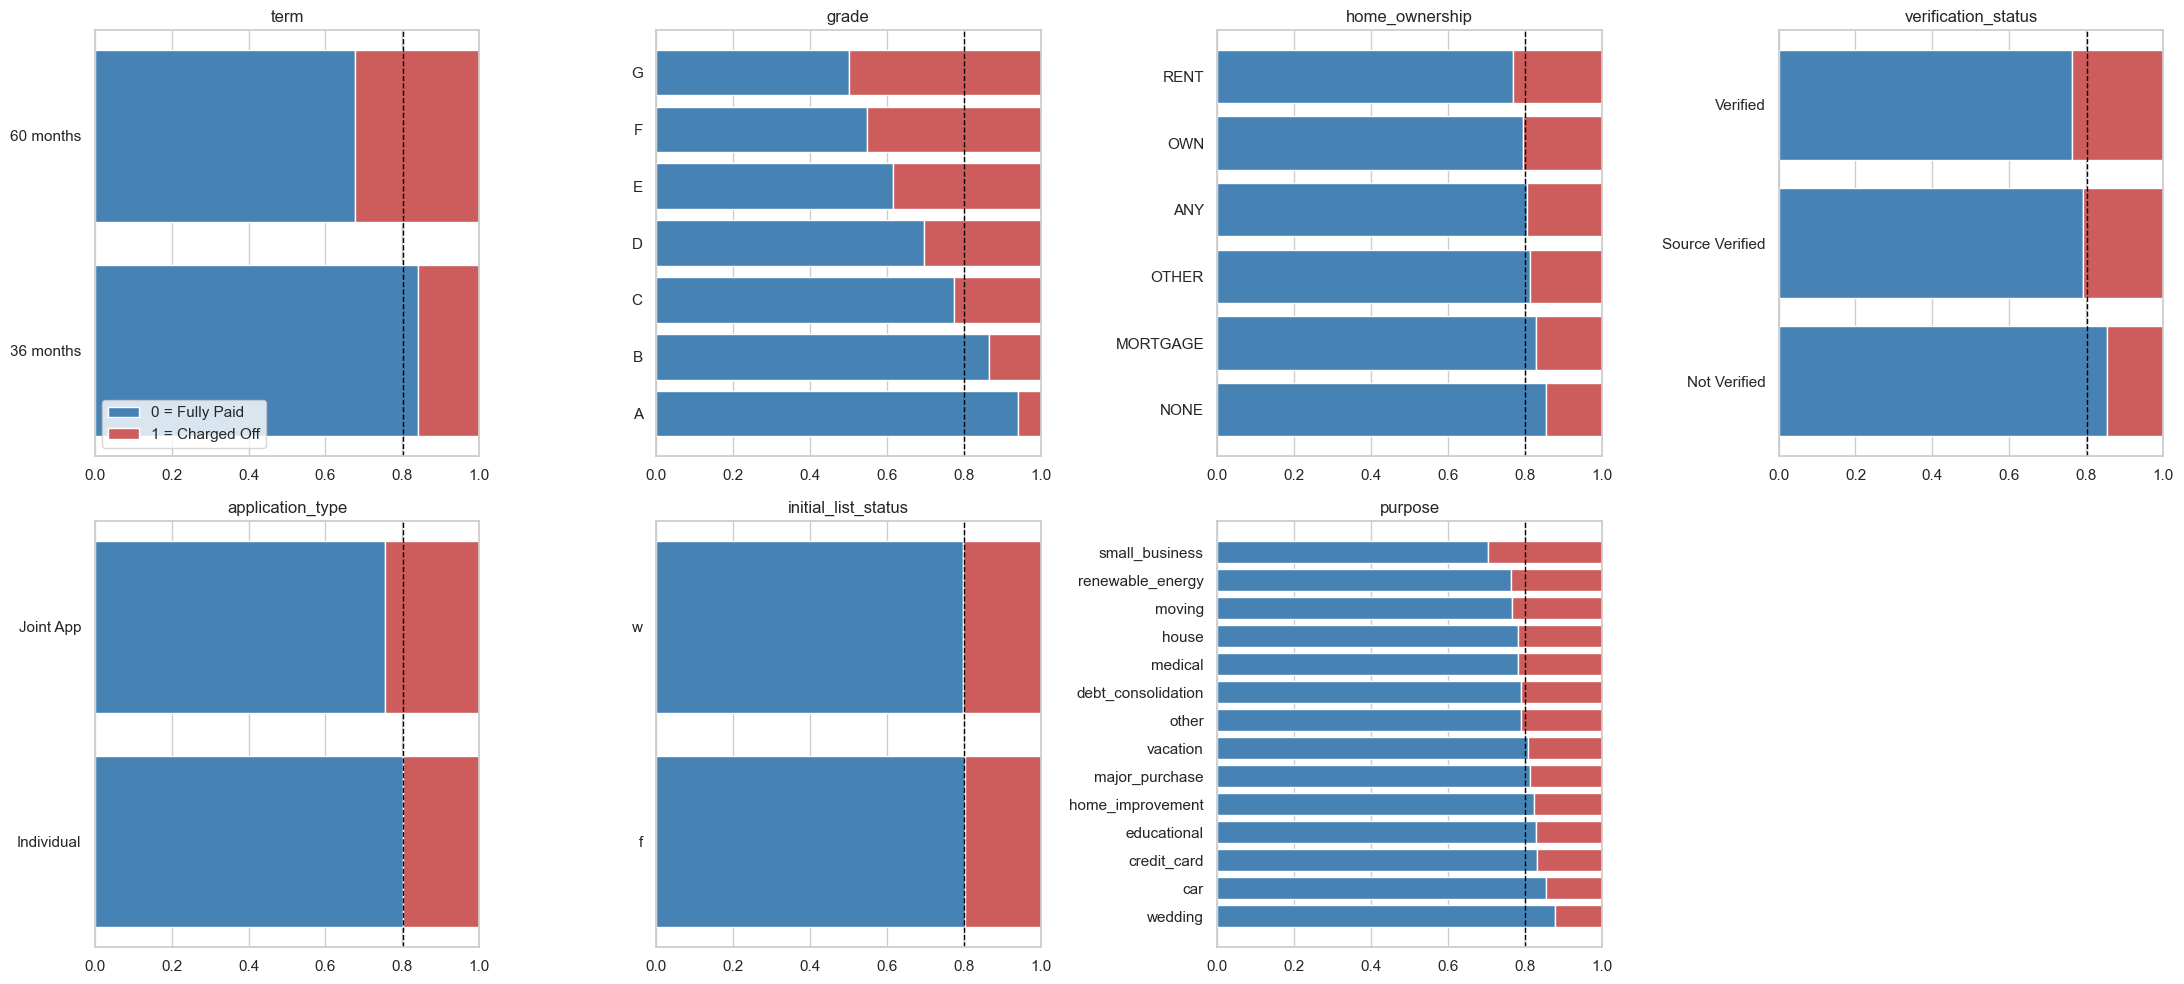

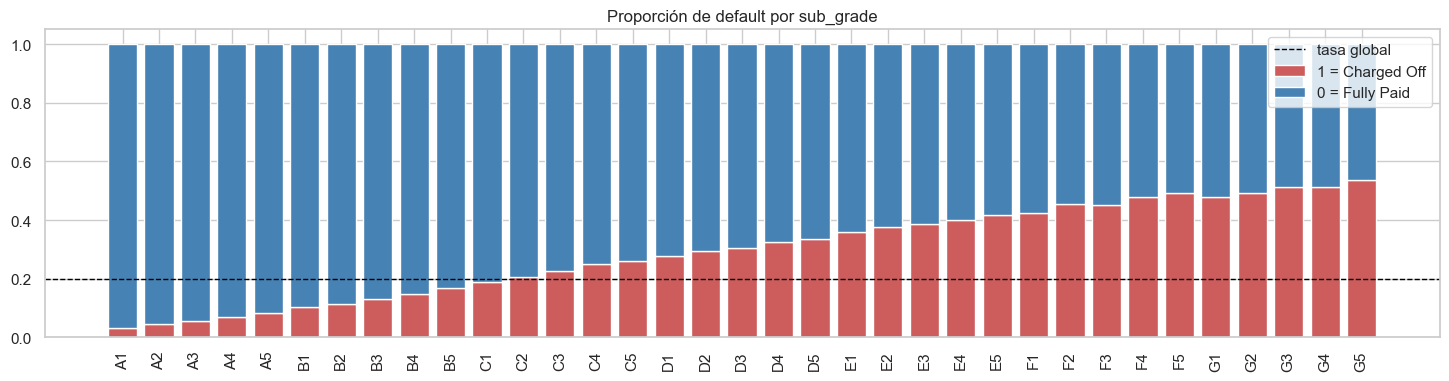

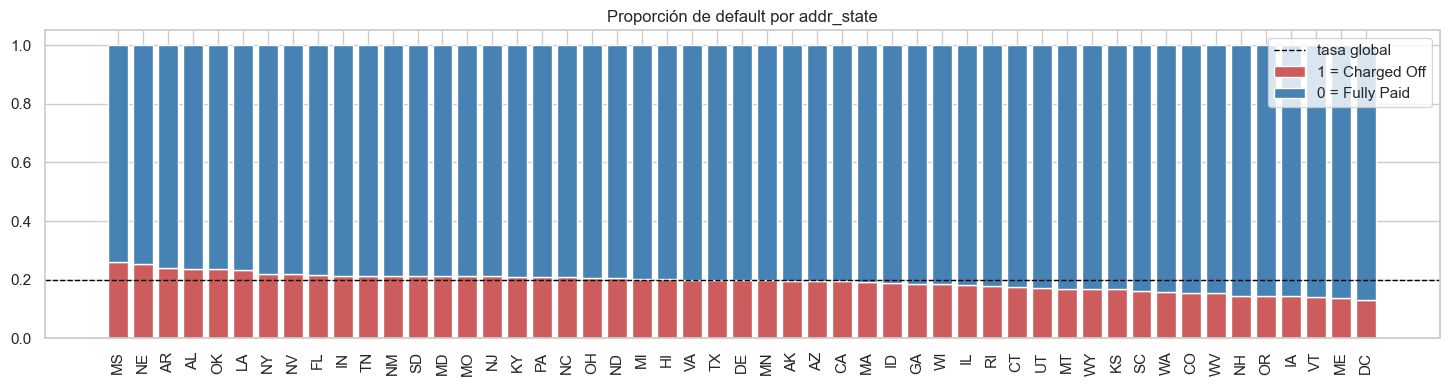

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, c in zip(axes.flat, pocas):
    prop = pd.crosstab(df[c], df['default'], normalize='index').sort_values(1)
    ax.barh(prop.index.astype(str), prop[0], color='steelblue', label='0 = Fully Paid')
    ax.barh(prop.index.astype(str), prop[1], left=prop[0], color='indianred', label='1 = Charged Off')
    ax.axvline(1 - tasa_global / 100, color='black', ls='--', lw=1)
    ax.set_title(c)
    ax.set_xlim(0, 1)
axes.flat[0].legend(loc='lower left')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

for c in ['sub_grade', 'addr_state']:
    prop = pd.crosstab(df[c], df['default'], normalize='index')
    prop = prop.sort_index() if c == 'sub_grade' else prop.sort_values(1, ascending=False)
    plt.figure(figsize=(18, 4))
    plt.bar(prop.index.astype(str), prop[1], color='indianred', label='1 = Charged Off')
    plt.bar(prop.index.astype(str), prop[0], bottom=prop[1], color='steelblue', label='0 = Fully Paid')
    plt.axhline(tasa_global / 100, color='black', ls='--', lw=1, label='tasa global')
    plt.title(f'Proporción de default por {c}')
    plt.xticks(rotation=90)
    plt.legend(loc='upper right')
    plt.show()

**Prueba chi-cuadrado de independencia** entre cada variable categórica y `default`. Como con $n$ tan grande el p-value será casi siempre ≈ 0, se reporta también la **V de Cramér**, que mide la fuerza de la asociación en una escala de 0 a 1:

$$V = \sqrt{\frac{\chi^2 / n}{\min(k-1,\, r-1)}}$$

In [30]:
def v_cramer(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    return chi2, p, dof, np.sqrt((chi2 / n) / (min(ct.shape) - 1))

filas = []
for c in cat_cols:
    chi2, p, dof, v = v_cramer(df[c], df['default'])
    filas.append({'variable': c, 'chi2': chi2, 'gl': dof, 'p-value': p, 'V de Cramer': v,
                  'independiente (p>=0.05)': 'sí' if p >= 0.05 else 'no'})
tabla_chi2 = pd.DataFrame(filas).set_index('variable').sort_values('V de Cramer', ascending=False)
tabla_chi2.round(4)

,chi2,gl,p-value,V de Cramer,independiente (p>=0.05)
variable,,,,,
sub_grade,96525.3877,34,0.0,0.2679,no
grade,92284.2511,6,0.0,0.2619,no
term,41716.8301,1,0.0,0.1761,no
verification_status,11387.4390,2,0.0,0.0920,no
home_ownership,6743.1900,5,0.0,0.0708,no
purpose,4144.1960,13,0.0,0.0555,no
addr_state,3403.5833,50,0.0,0.0503,no
application_type,352.1009,1,0.0,0.0162,no
initial_list_status,71.3174,1,0.0,0.0073,no


**Categorías con mayor tasa de default** (solo categorías con al menos 1 000 préstamos, para que la tasa sea estable):

In [31]:
filas = []
for c, ct in tablas_ct.items():
    for cat, fila in ct.iterrows():
        filas.append({'variable': c, 'categoria': cat, 'n_total': fila['n_total'],
                      'tasa_default_%': fila['tasa_default_%']})
top_cat = pd.DataFrame(filas)
top_cat = top_cat[top_cat['n_total'] >= 1000].sort_values('tasa_default_%', ascending=False)
top_cat['veces la tasa global'] = (top_cat['tasa_default_%'] / tasa_global).round(2)
top_cat.head(15)

,variable,categoria,n_total,tasa_default_%,veces la tasa global
43,sub_grade,G5,1110.0,53.60,2.69
41,sub_grade,G3,1614.0,51.36,2.57
42,sub_grade,G4,1280.0,51.17,2.56
8,grade,G,9132.0,49.93,2.50
38,sub_grade,F5,3943.0,49.18,2.46
40,sub_grade,G2,2131.0,49.13,2.46
37,sub_grade,F4,4859.0,47.89,2.40
39,sub_grade,G1,2997.0,47.85,2.40
35,sub_grade,F2,7198.0,45.35,2.27
7,grade,F,32058.0,45.20,2.26


**Comentario de las variables categóricas vs default.**

- La prueba chi-cuadrado rechaza la independencia para **todas** las variables (p ≈ 0). Igual que con las numéricas, la fuerza de la asociación se mide con la V de Cramér:
  - **`grade` / `sub_grade`** (V ≈ 0.26-0.27): la tasa de default crece de forma casi monótona con el grado, desde **6.0 % en A** hasta **49.9 % en G**. En las subcategorías G3-G5 **más de la mitad** de los préstamos cae en default (2.6 veces la tasa global).
  - **`term`** (V = 0.18): los préstamos a **60 meses** tienen un default de **32.5 %**, el doble que los de 36 meses (16.0 %).
  - **`verification_status`** (V = 0.09): paradójicamente, los ingresos **verificados** tienen *más* default (23.9 %) que los no verificados (14.7 %). Lending Club verifica con más frecuencia a los solicitantes que considera más riesgosos, así que esta variable actúa como un indicador indirecto de riesgo.
  - **`home_ownership`** (V = 0.07): RENT 23.2 % vs MORTGAGE 17.2 %.
  - **`purpose`** (V = 0.06): `small_business` (29.7 %) es claramente el propósito más riesgoso; `wedding` (12.2 %) y `car` (14.7 %) son los menos riesgosos.
  - **`addr_state`** (V = 0.05): diferencias moderadas. MS, NE, AR, AL y OK superan el 23 %.
- `initial_list_status` (V = 0.007) y `application_type` (V = 0.016) tienen asociación prácticamente nula con el default.
- **Predictores categóricos más relevantes:** `sub_grade`/`grade`, `term`, `verification_status`, `home_ownership` y `purpose`.

##### Relaciones entre variables independientes (multicolinealidad)

**Matriz de correlación de Pearson** entre todas las variables numéricas:

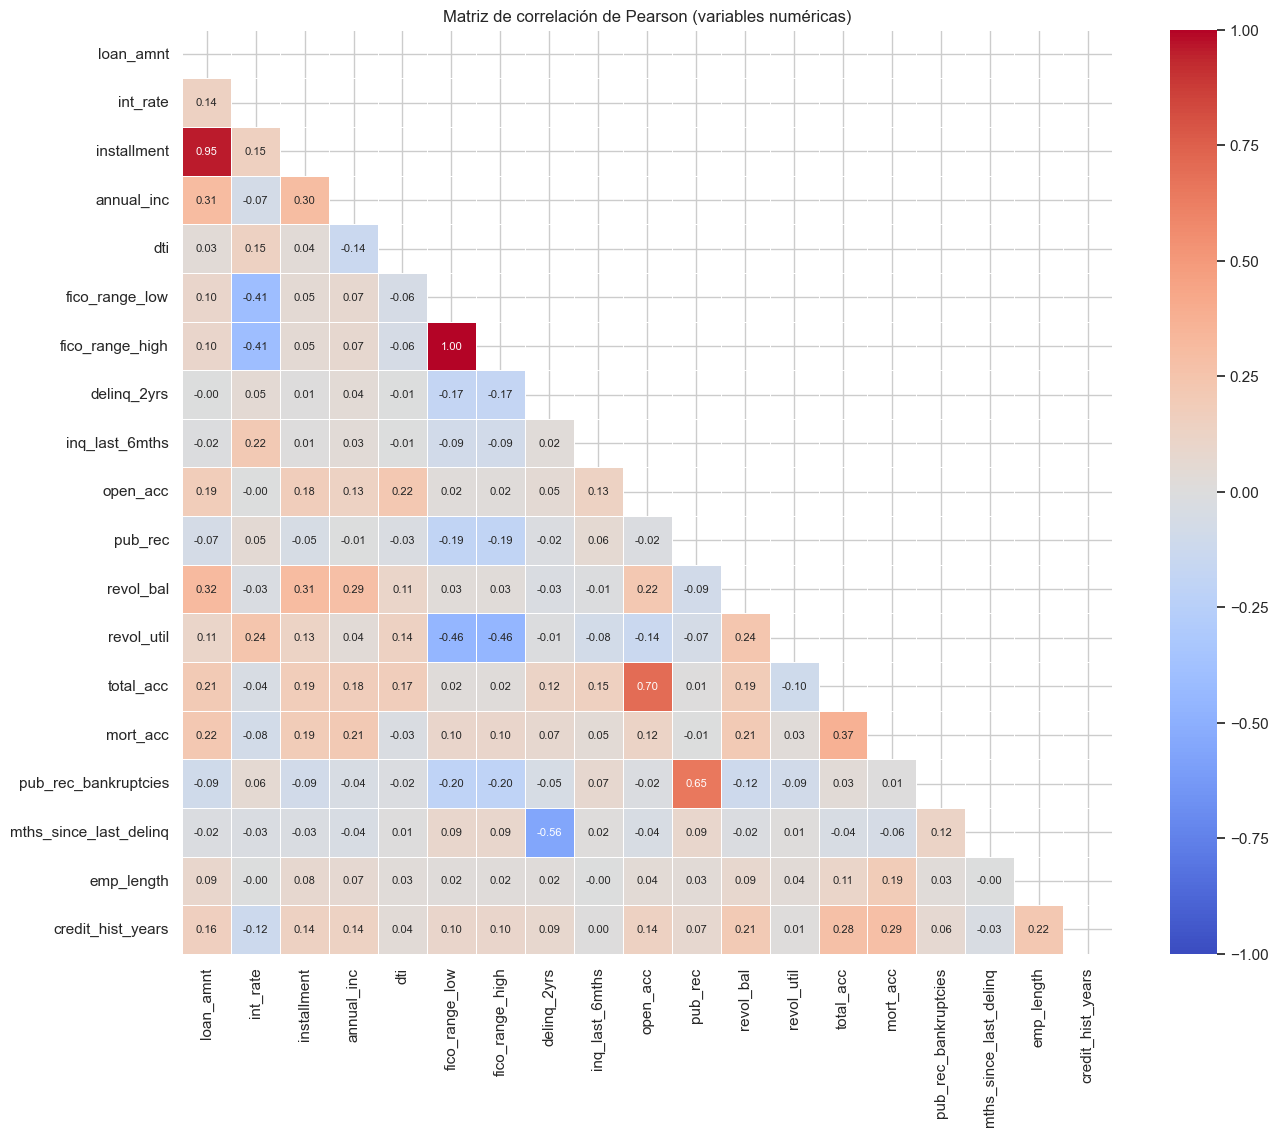

In [32]:
corr = df[num_cols].corr(method='pearson')
plt.figure(figsize=(15, 12))
mascara = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mascara, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, annot_kws={'size': 8}, linewidths=0.5)
plt.title('Matriz de correlación de Pearson (variables numéricas)')
plt.show()

In [33]:
pares = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        pares.append({'var_1': num_cols[i], 'var_2': num_cols[j], 'r': corr.iloc[i, j]})
pares = pd.DataFrame(pares)
pares['|r|'] = pares['r'].abs()
pares = pares.sort_values('|r|', ascending=False)
print('Pares con |r| > 0.7 (posible multicolinealidad):')
display(pares[pares['|r|'] > 0.7].round(3))
print('Siguientes pares más correlacionados:')
display(pares[pares['|r|'] <= 0.7].head(8).round(3))
print(f"Correlación fico_range_high vs int_rate: {corr.loc['fico_range_high', 'int_rate']:.3f}")

Pares con |r| > 0.7 (posible multicolinealidad):


,var_1,var_2,r,|r|
80,fico_range_low,fico_range_high,1.000,1.000
1,loan_amnt,installment,0.953,0.953
129,open_acc,total_acc,0.701,0.701


Siguientes pares más correlacionados:


,var_1,var_2,r,|r|
139,pub_rec,pub_rec_bankruptcies,0.650,0.650
113,delinq_2yrs,mths_since_last_delinq,-0.556,0.556
86,fico_range_low,revol_util,-0.460,0.460
98,fico_range_high,revol_util,-0.460,0.460
21,int_rate,fico_range_low,-0.405,0.405
22,int_rate,fico_range_high,-0.405,0.405
156,total_acc,mort_acc,0.368,0.368
10,loan_amnt,revol_bal,0.318,0.318


Correlación fico_range_high vs int_rate: -0.405


**V de Cramér entre pares de variables categóricas:**

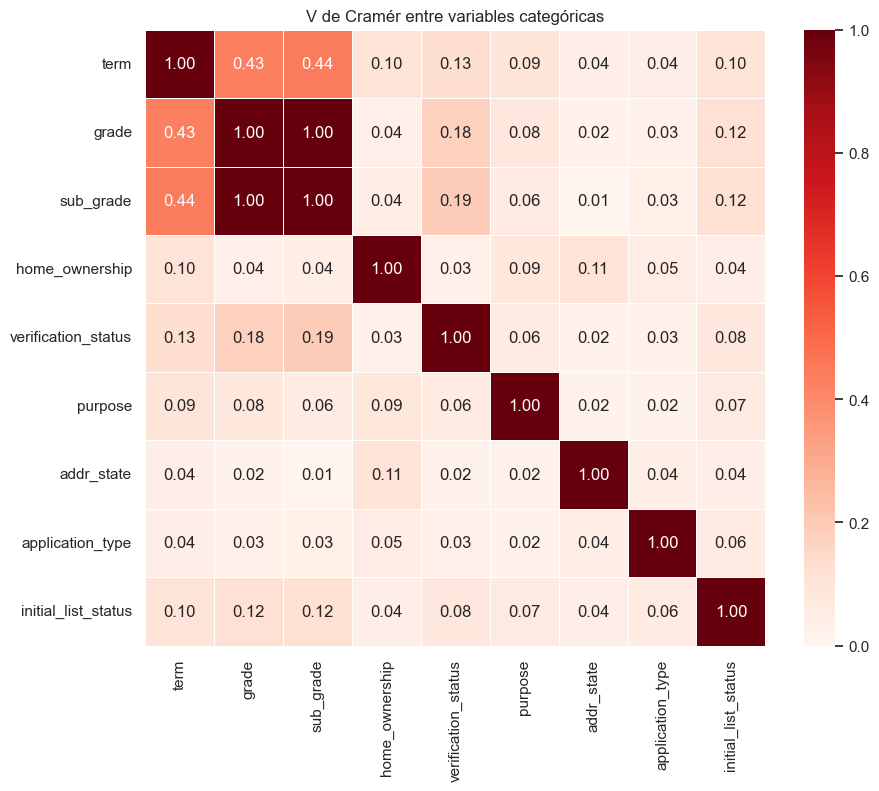

In [34]:
cramer = pd.DataFrame(np.eye(len(cat_cols)), index=cat_cols, columns=cat_cols)
for i in range(len(cat_cols)):
    for j in range(i + 1, len(cat_cols)):
        v = v_cramer(df[cat_cols[i]], df[cat_cols[j]])[3]
        cramer.iloc[i, j] = cramer.iloc[j, i] = v

plt.figure(figsize=(10, 8))
sns.heatmap(cramer, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1, linewidths=0.5)
plt.title('V de Cramér entre variables categóricas')
plt.show()

**Redundancia entre `grade` / `sub_grade` e `int_rate`.** Lending Club asigna la tasa de interés según el grado del préstamo. Para medir qué parte de la variación de `int_rate` explica `grade` se usa la razón de correlación $\eta^2$ (varianza entre grupos / varianza total):

eta^2 int_rate ~ grade:     0.909
eta^2 int_rate ~ sub_grade: 0.955


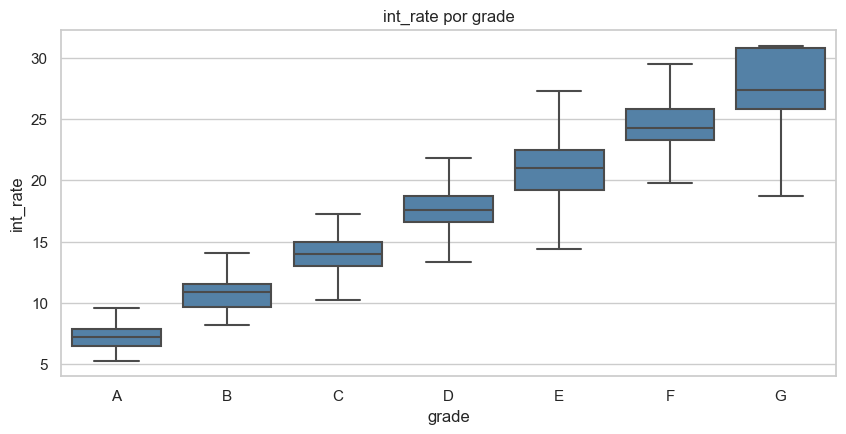

In [35]:
def eta_cuadrado(cat, y):
    media_grupo = y.groupby(cat, observed=True).transform('mean')
    return ((media_grupo - y.mean()) ** 2).sum() / ((y - y.mean()) ** 2).sum()

print(f"eta^2 int_rate ~ grade:     {eta_cuadrado(df['grade'], df['int_rate']):.3f}")
print(f"eta^2 int_rate ~ sub_grade: {eta_cuadrado(df['sub_grade'], df['int_rate']):.3f}")

plt.figure(figsize=(10, 4.5))
sns.boxplot(data=df, x='grade', y='int_rate', color='steelblue', showfliers=False)
plt.title('int_rate por grade')
plt.show()

**Comentario sobre multicolinealidad.**

- **Pares con |r| > 0.7:**
  - `fico_range_low` y `fico_range_high` (**r = 1.000**): redundancia total, porque son los dos extremos del mismo rango de 4 puntos. **Se conserva solo `fico_range_high`** (o su promedio).
  - `loan_amnt` e `installment` (**r = 0.953**): la cuota se calcula a partir del monto, la tasa y el plazo. Mantener ambas afectaría a la regresión logística y a LinearSVC, así que **se recomienda eliminar `installment`**.
  - `open_acc` y `total_acc` (**r = 0.701**): justo en el límite. Se puede conservar `total_acc`, eliminar `open_acc` o reemplazarlas por su razón.
  - Correlaciones moderadas: `pub_rec` y `pub_rec_bankruptcies` (0.65), porque las bancarrotas son un tipo de registro público; y `delinq_2yrs` y `mths_since_last_delinq` (−0.56).
- **`fico_range_high` vs `int_rate`:** r = **−0.405**, correlación moderada y no redundante. Ambas aportan información propia.
- **`int_rate` vs `grade`/`sub_grade`:** esta sí es una redundancia fuerte. El grado explica el **91 %** de la varianza de la tasa (η² = 0.909) y el sub-grado el **95.5 %** (η² = 0.955). En el boxplot las cajas por grado casi no se solapan, porque Lending Club fija la tasa según el sub-grado. Incluir `int_rate` y `sub_grade` juntos es casi repetir la misma variable. Se recomienda conservar **`int_rate`**, que es numérica, tiene la mayor correlación con el default y no genera 35 dummies, o bien `grade` con un tratamiento cuidadoso.
- **Entre categóricas (V de Cramér):** `grade` y `sub_grade` tienen V = 1.00 (una se deduce de la otra). `term` se asocia moderadamente con el grado (V ≈ 0.43), porque los préstamos a 60 meses suelen tener grados peores. El resto de pares tiene V < 0.2, asociación débil.

##### Visualizaciones avanzadas

**Gráficos de densidad (KDE) por clase** para las variables más relevantes (todos los datos). Cada curva está normalizada dentro de su clase (`common_norm=False`), de modo que se comparan las formas y no los tamaños de las clases.

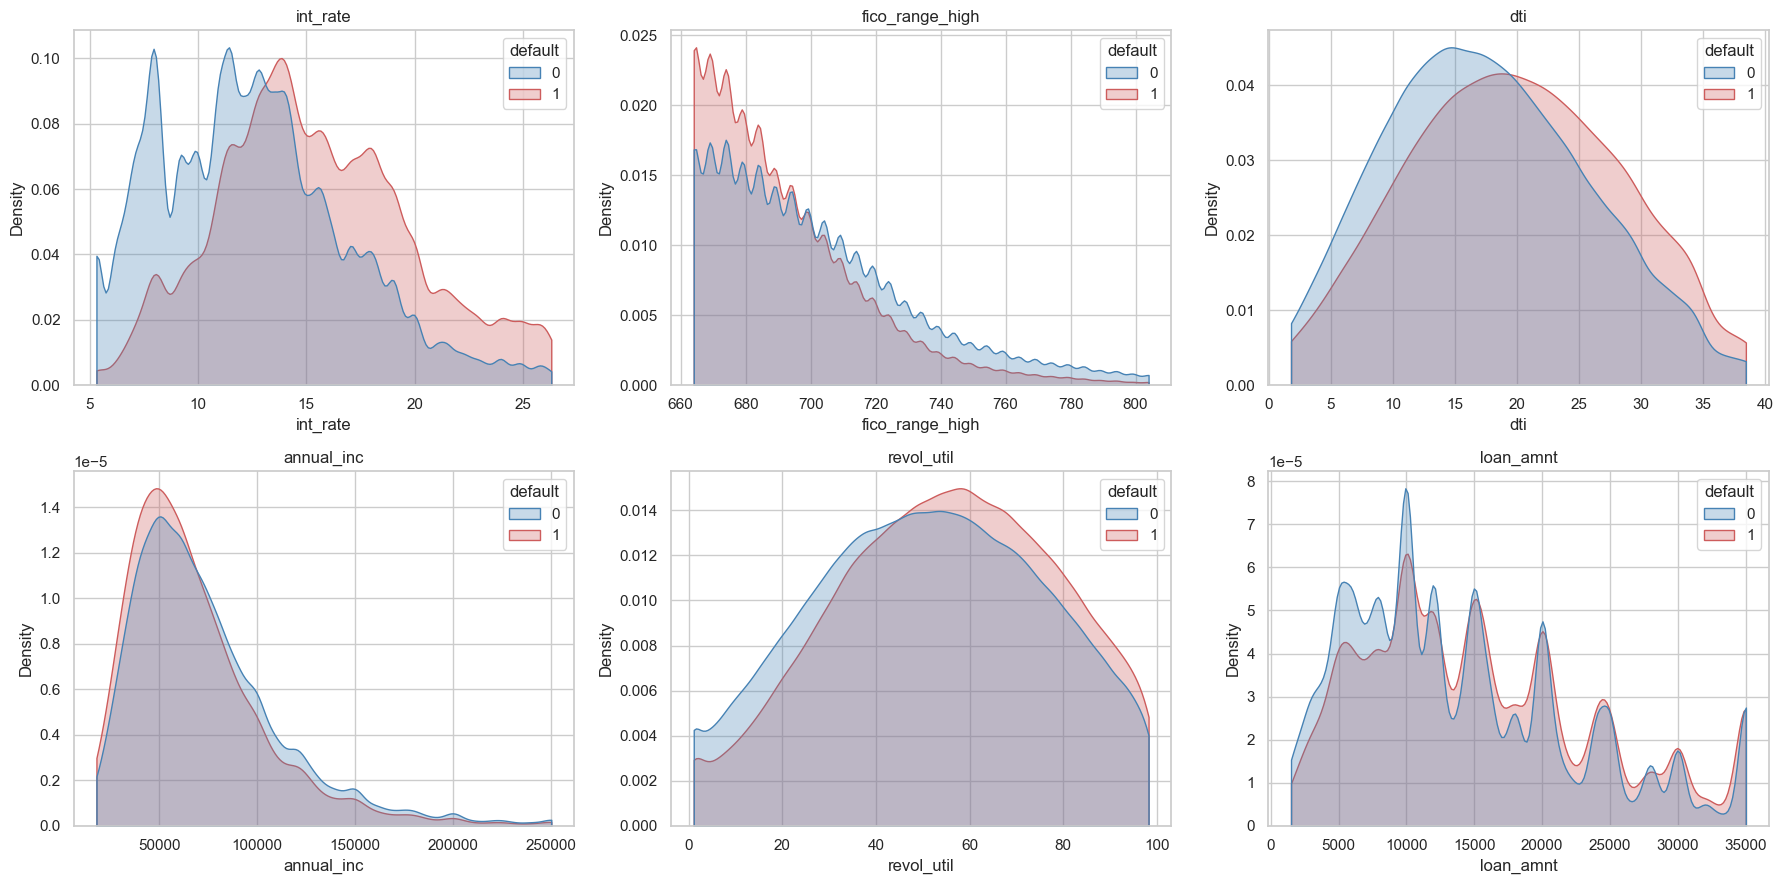

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, c in zip(axes.flat, ['int_rate', 'fico_range_high', 'dti', 'annual_inc', 'revol_util', 'loan_amnt']):
    p1, p99 = df[c].quantile([0.01, 0.99])
    sns.kdeplot(data=df, x=c, hue='default', common_norm=False, fill=True, alpha=0.3,
                clip=(p1, p99), palette=['steelblue', 'indianred'], ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

**Pairplot y scatter matrix.** Un pairplot con 1.3 millones de puntos por panel es ilegible y muy costoso de dibujar. El enunciado permite usar **una muestra representativa** para esta visualización, así que se toma una muestra **estratificada por `default`** de 5 000 préstamos (`random_state=42`), que conserva la proporción de clases. La muestra se usa **solo para estos dos gráficos**.

Tamaño de la muestra: 5000
Proporción de default en la muestra: 0.1996 | en el total: 0.1996


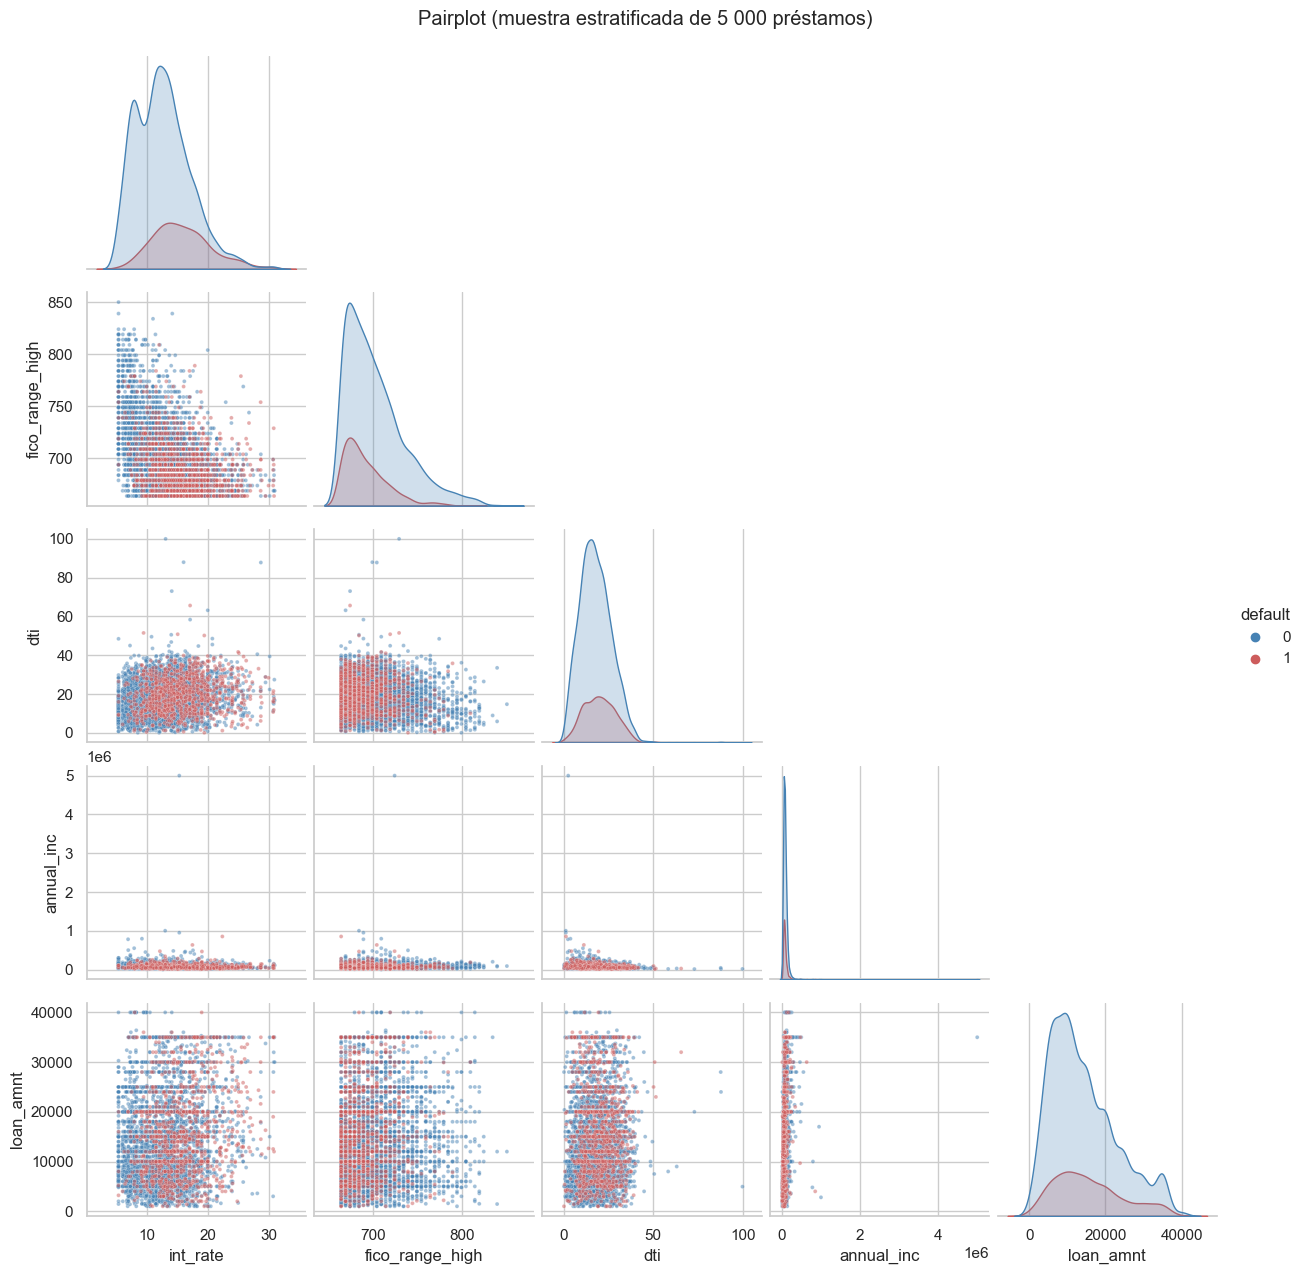

In [37]:
muestra = df.groupby('default').sample(frac=5000 / len(df), random_state=42)
print('Tamaño de la muestra:', len(muestra))
print('Proporción de default en la muestra:', round(muestra['default'].mean(), 4),
      '| en el total:', round(df['default'].mean(), 4))

vars_pair = ['int_rate', 'fico_range_high', 'dti', 'annual_inc', 'loan_amnt']
g = sns.pairplot(muestra[vars_pair + ['default']], hue='default', corner=True,
                 palette=['steelblue', 'indianred'], plot_kws={'s': 8, 'alpha': 0.5})
g.fig.suptitle('Pairplot (muestra estratificada de 5 000 préstamos)', y=1.02)
plt.show()

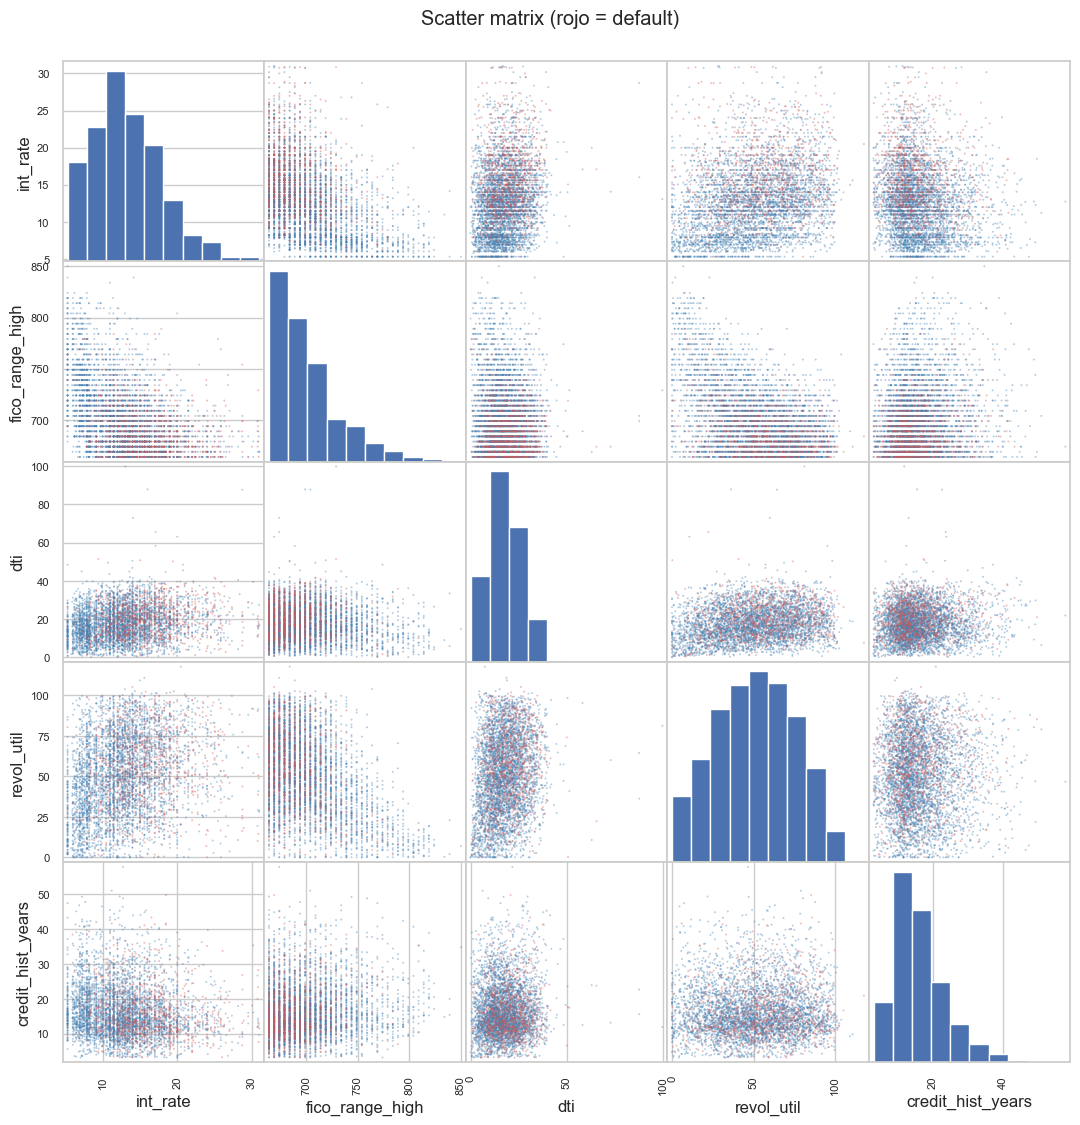

In [38]:
vars_sm = ['int_rate', 'fico_range_high', 'dti', 'revol_util', 'credit_hist_years']
sm = muestra[vars_sm + ['default']].dropna()   # scatter_matrix no admite nulos al colorear
colores = sm['default'].map({0: 'steelblue', 1: 'indianred'})
pd.plotting.scatter_matrix(sm[vars_sm], c=colores, figsize=(13, 13), alpha=0.4, s=8, diagonal='hist')
plt.suptitle('Scatter matrix (rojo = default)', y=0.92)
plt.show()

**Comentario de las visualizaciones avanzadas.**

- **KDE por clase:**
  - La curva de `int_rate` para default está claramente desplazada a la derecha y la de `fico_range_high` a la izquierda. Son las dos variables con mayor poder discriminante.
  - En `dti` y `revol_util` el desplazamiento es leve.
  - En `annual_inc` y `loan_amnt` las curvas casi se superponen.
  - En ninguna variable se separan las dos distribuciones: el solapamiento es grande, lo que confirma que el problema es difícil de clasificar.
- **Pairplot y scatter matrix (muestra estratificada de 5 000):**
  - Los puntos rojos (default) y azules están mezclados en todos los pares de variables; no hay regiones claramente separables.
  - La estructura más visible es la relación negativa entre `int_rate` y `fico_range_high`: los FICO altos solo aparecen con tasas bajas. Las bandas horizontales se deben a que el FICO toma valores discretos (saltos de 5 puntos), y los préstamos en default (rojo) se concentran en la zona de FICO bajo y tasa alta.
  - `annual_inc` sigue dominada por pocos valores extremos, lo que refuerza la necesidad de la transformación logarítmica.
  - No se observan patrones no lineales fuertes. Aun así, los modelos de árboles podrían capturar interacciones que estos gráficos 2D no muestran.

#### 9.10.4.1.4. Valores faltantes (análisis detallado)

**Número y porcentaje de nulos por columna** en los 1.3 millones de préstamos finalizados, para las **151 columnas** del archivo (conteos acumulados durante la lectura por bloques):

In [39]:
tabla_nulos = info_completo[['nulos', '% nulos']].sort_values('% nulos', ascending=False)
tabla_nulos['rango'] = pd.cut(tabla_nulos['% nulos'], [-0.01, 0, 5, 30, 70, 100],
                              labels=['0 %', '(0, 5] %', '(5, 30] %', '(30, 70] %', '> 70 %'])
print(tabla_nulos['rango'].value_counts().sort_index())
with pd.option_context('display.max_rows', 200):
    display(tabla_nulos)

rango
0 %           52
(0, 5] %      15
(5, 30] %     26
(30, 70] %    16
> 70 %        42
Name: count, dtype: int64


,nulos,% nulos,rango
next_pymnt_d,1345310,100.00,> 70 %
member_id,1345310,100.00,> 70 %
orig_projected_additional_accrued_interest,1341551,99.72,> 70 %
hardship_start_date,1339556,99.57,> 70 %
hardship_length,1339556,99.57,> 70 %
hardship_type,1339556,99.57,> 70 %
hardship_reason,1339556,99.57,> 70 %
hardship_status,1339556,99.57,> 70 %
deferral_term,1339556,99.57,> 70 %
hardship_amount,1339556,99.57,> 70 %


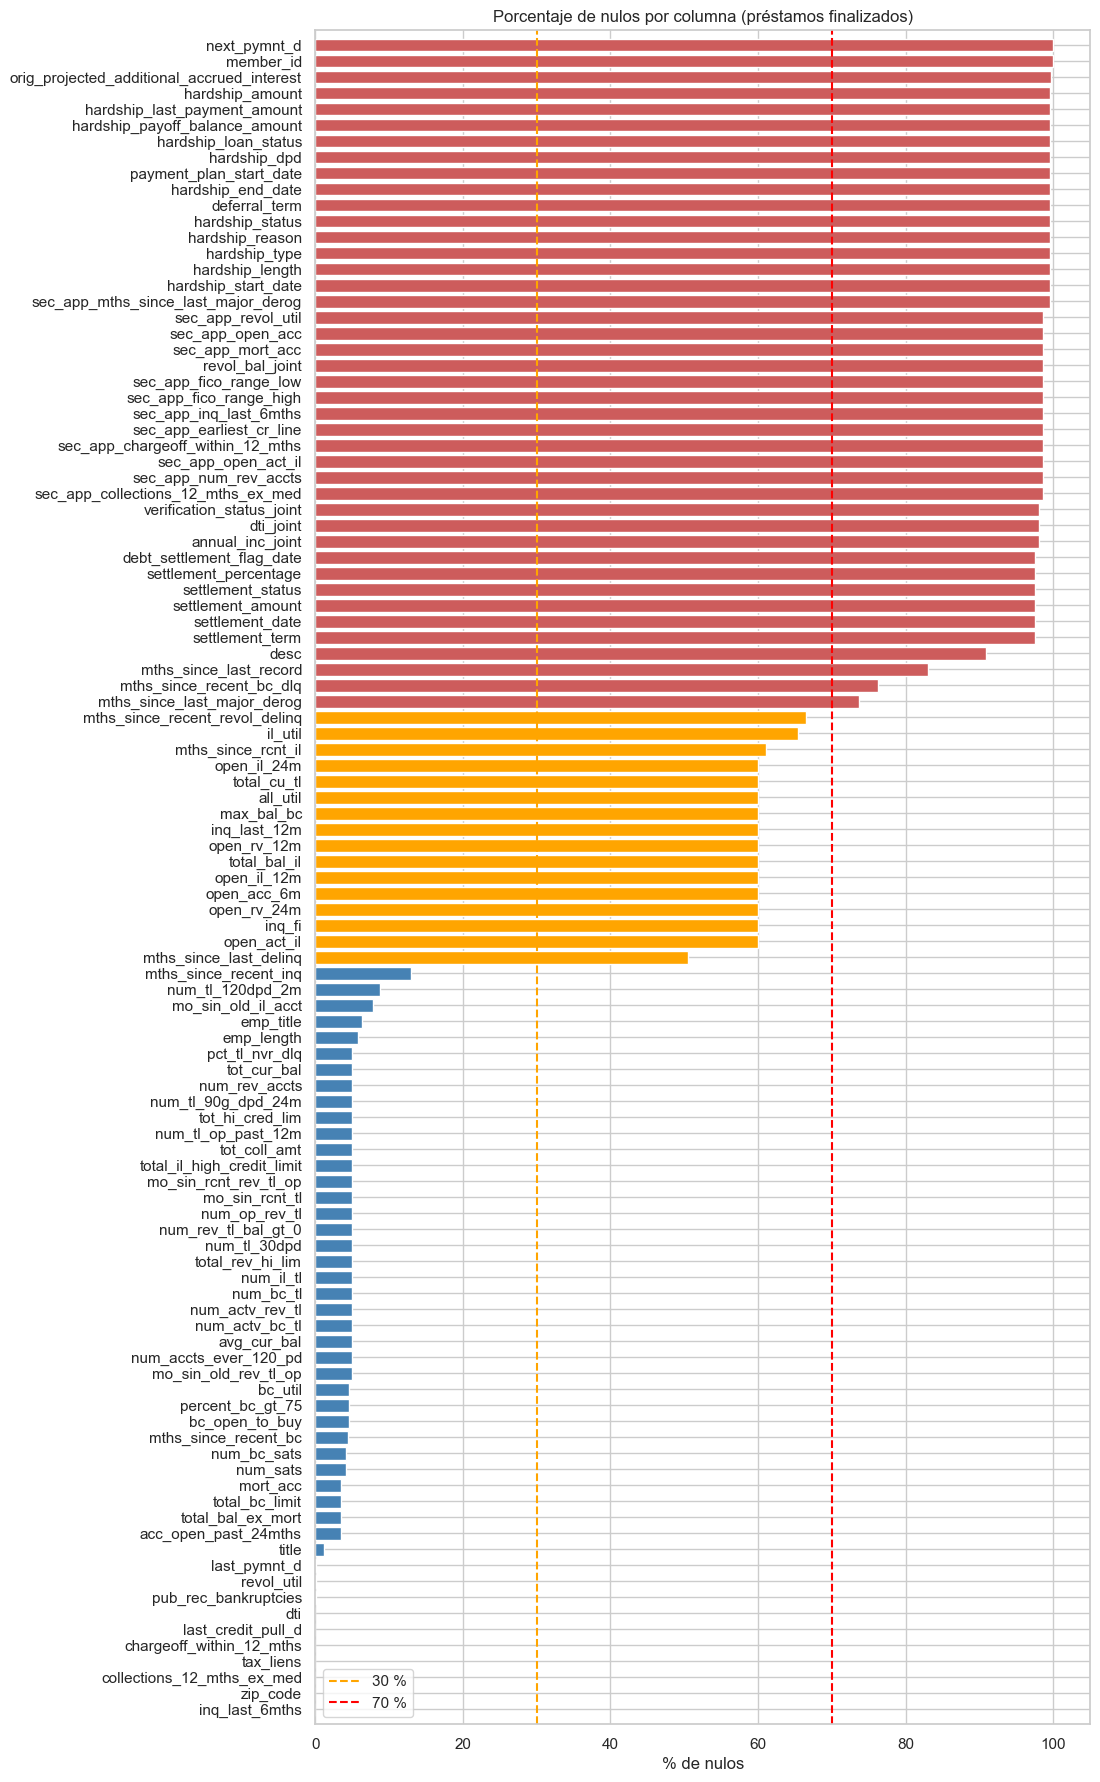

In [40]:
con_nulos = tabla_nulos[tabla_nulos['nulos'] > 0]['% nulos'].sort_values()
plt.figure(figsize=(10, 22))
plt.barh(con_nulos.index, con_nulos.values,
         color=np.where(con_nulos.values > 70, 'indianred',
                        np.where(con_nulos.values > 30, 'orange', 'steelblue')))
plt.axvline(30, color='orange', ls='--', label='30 %')
plt.axvline(70, color='red', ls='--', label='70 %')
plt.xlabel('% de nulos')
plt.title('Porcentaje de nulos por columna (préstamos finalizados)')
plt.legend()
plt.margins(y=0.005)
plt.show()

**Mapa de calor de nulos por año de emisión.** Muestra el % de nulos de cada columna (filas del mapa) en cada año (columnas del mapa). Así se ve si los faltantes son **sistemáticos**, por ejemplo variables que Lending Club empezó a registrar en cierto año.

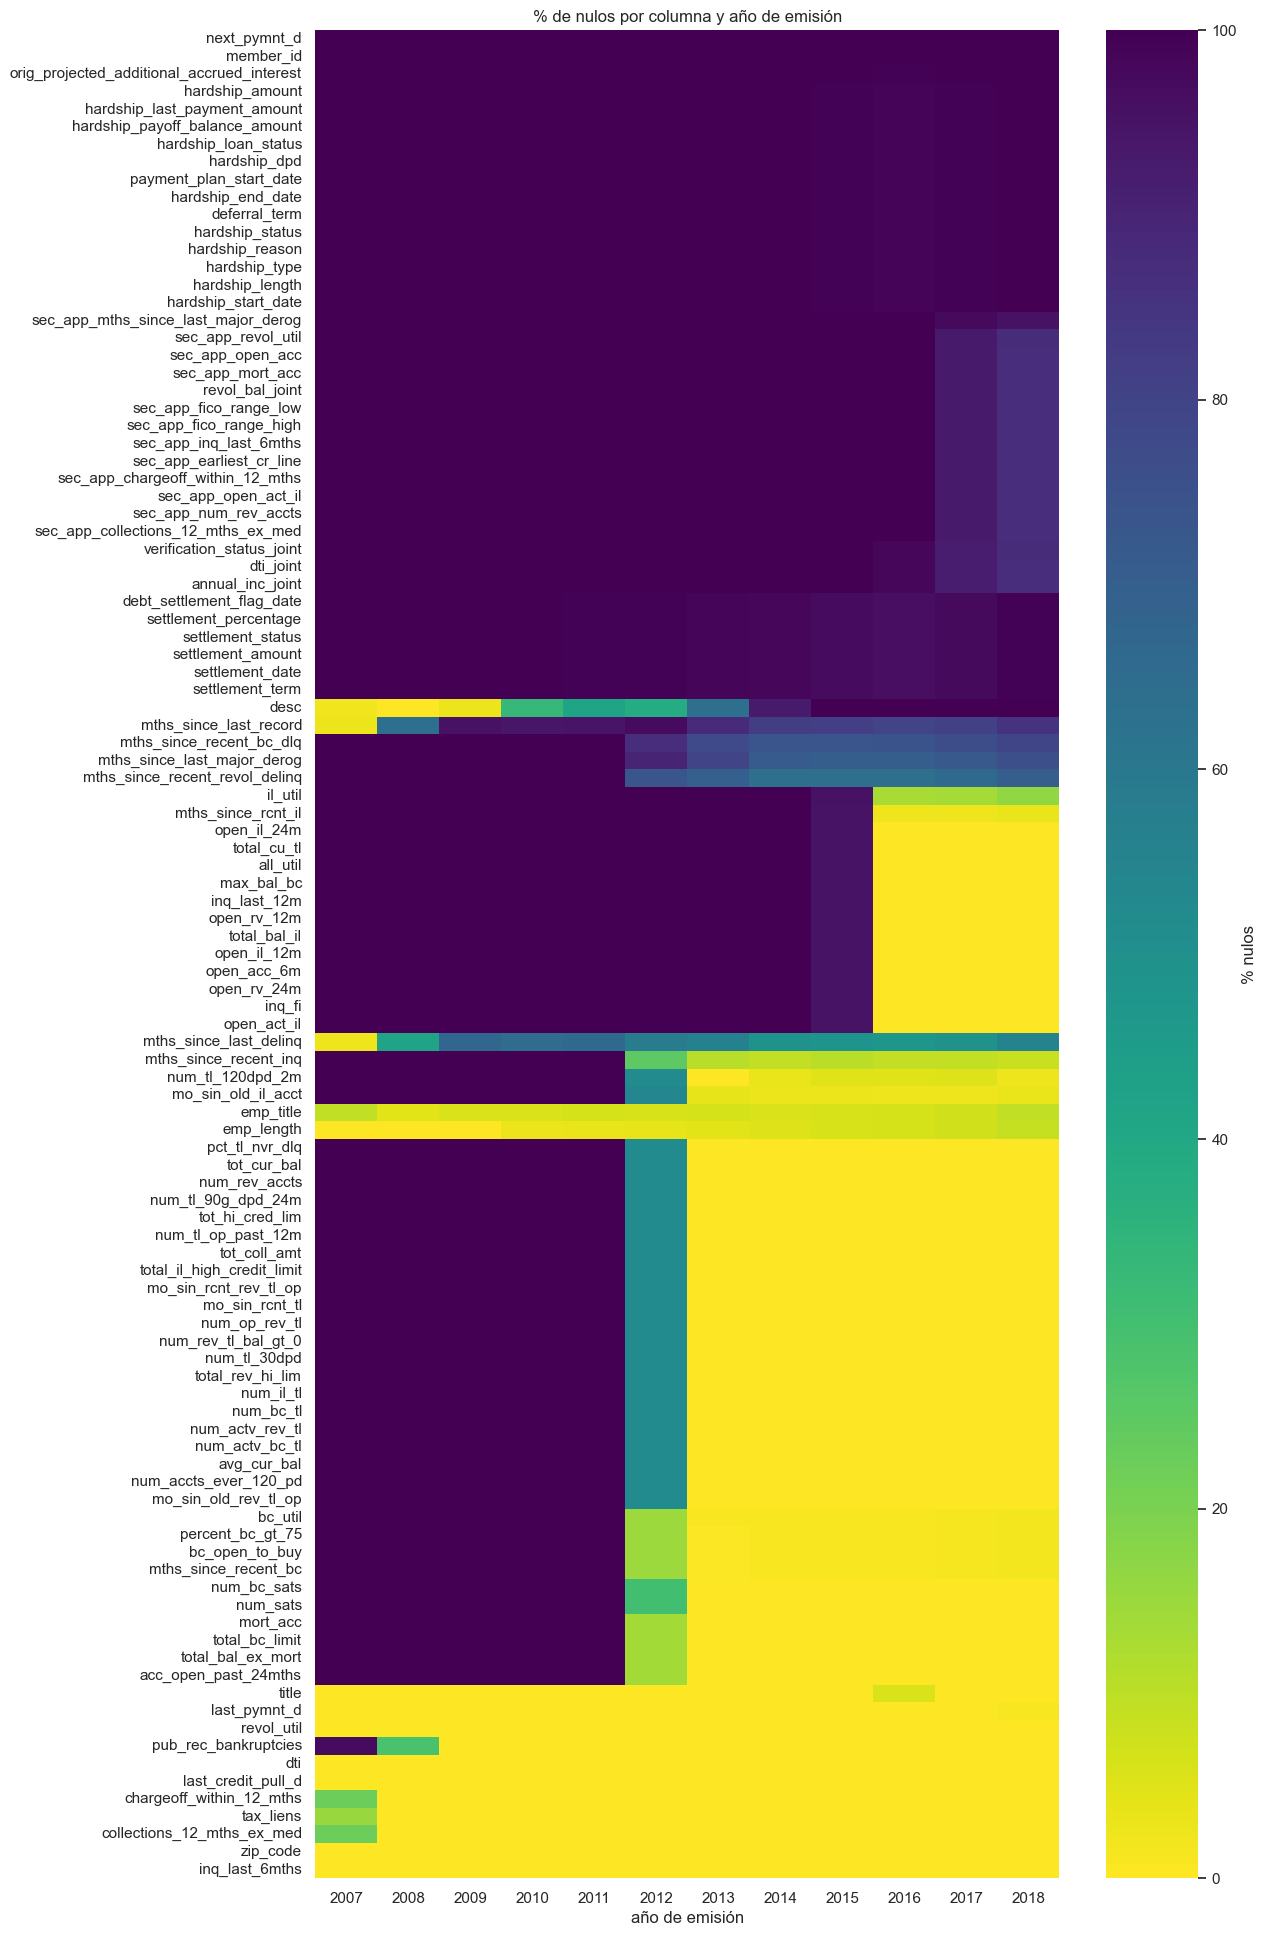

Préstamos finalizados por año:
issue_d
2007       251
2008      1562
2009      4716
2010     11536
2011     21721
2012     53367
2013    134804
2014    223102
2015    375545
2016    293095
2017    169300
2018     56311


In [41]:
pct_anio = (100 * nulos_anio.div(filas_anio, axis=0)).T
pct_anio = pct_anio.loc[con_nulos.index[::-1]]
plt.figure(figsize=(12, 24))
sns.heatmap(pct_anio, cmap='viridis_r', vmin=0, vmax=100, cbar_kws={'label': '% nulos'})
plt.title('% de nulos por columna y año de emisión')
plt.xlabel('año de emisión')
plt.show()
print('Préstamos finalizados por año:')
print(filas_anio.to_string())

**¿Se concentran los nulos en ciertas filas?** Distribución del número de columnas nulas por fila, primero sobre las 151 columnas y luego sobre las variables del EDA:

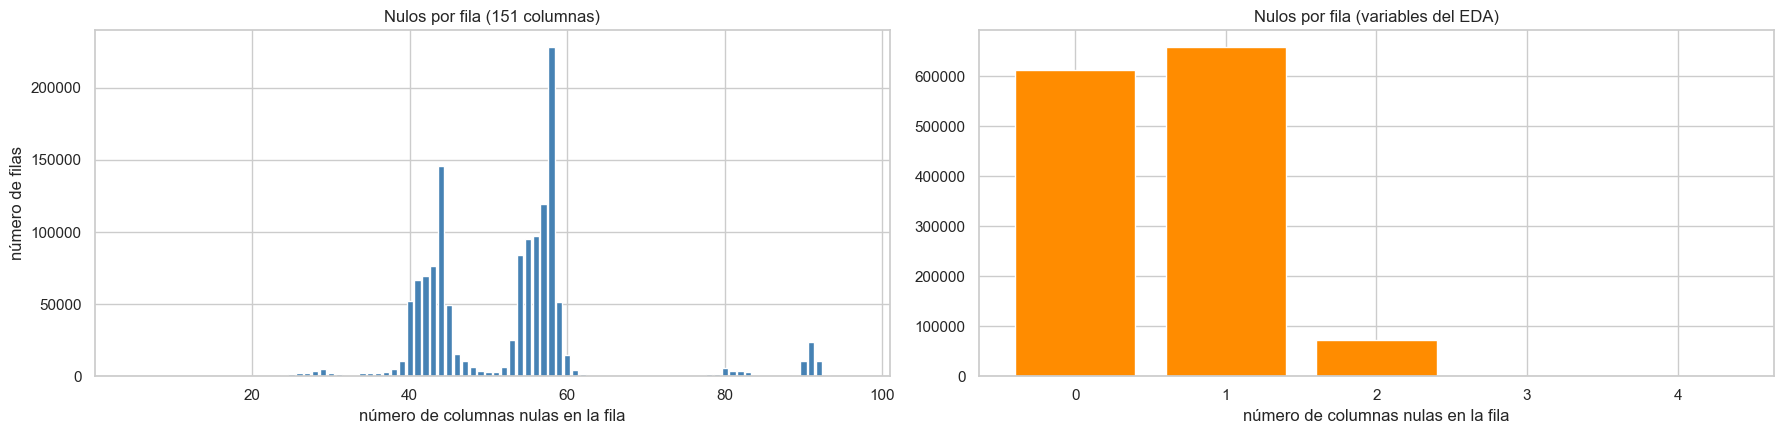

Filas según número de nulos (variables del EDA):
    filas       %
0  613054  45.570
1  659256  49.004
2   71796   5.337
3    1200   0.089
4       4   0.000


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
npf = nulos_por_fila.sort_index()
axes[0].bar(npf.index, npf.values, color='steelblue')
axes[0].set_title('Nulos por fila (151 columnas)')
axes[0].set_xlabel('número de columnas nulas en la fila')
axes[0].set_ylabel('número de filas')

nulos_fila_eda = df[num_cols + cat_cols].isna().sum(axis=1).value_counts().sort_index()
axes[1].bar(nulos_fila_eda.index.astype(str), nulos_fila_eda.values, color='darkorange')
axes[1].set_title('Nulos por fila (variables del EDA)')
axes[1].set_xlabel('número de columnas nulas en la fila')
plt.tight_layout()
plt.show()
print('Filas según número de nulos (variables del EDA):')
print(pd.DataFrame({'filas': nulos_fila_eda, '%': (100 * nulos_fila_eda / len(df)).round(3)}))

**Relación de los faltantes con `default` (¿MCAR?).** Si los faltantes fueran *completamente al azar* (MCAR), la tasa de default debería ser la misma en las filas donde la variable falta y en las filas donde no falta. Para cada columna con nulos se construye la tabla 2×2 (nulo / no nulo × default) y se aplica la prueba chi-cuadrado:

- $H_0$: el hecho de que falte el dato es independiente de `default`, lo que es consistente con MCAR.
- p < 0.05: se rechaza $H_0$. El faltante **no** es MCAR y el hecho de que falte ya es informativo.

Se calcula para todas las columnas con nulos del archivo, usando los conteos acumulados en la lectura.

In [43]:
n_def = df['default'].sum()
filas = []
for c in con_nulos.index:
    if nulos_fin[c] == n_fin:          # 100 % nulos: no hay nada que comparar
        continue
    nulo_def = nulos_fin_default[c]
    nulo_nodef = nulos_fin[c] - nulo_def
    tabla = np.array([[nulo_nodef, nulo_def],
                      [(n_fin - n_def) - nulo_nodef, n_def - nulo_def]])
    chi2, p, _, _ = stats.chi2_contingency(tabla)
    filas.append({'variable': c, '% nulos': 100 * nulos_fin[c] / n_fin,
                  'tasa_default si nulo %': 100 * nulo_def / nulos_fin[c],
                  'tasa_default si no nulo %': 100 * (n_def - nulo_def) / (n_fin - nulos_fin[c]),
                  'chi2': chi2, 'p-value': p})
tabla_mcar = pd.DataFrame(filas).set_index('variable')
tabla_mcar['dif (pp)'] = tabla_mcar['tasa_default si nulo %'] - tabla_mcar['tasa_default si no nulo %']
tabla_mcar['compatible con MCAR'] = np.where(tabla_mcar['p-value'] >= 0.05, 'sí', 'no')
print(tabla_mcar['compatible con MCAR'].value_counts())
with pd.option_context('display.max_rows', 200):
    display(tabla_mcar.round(4))

compatible con MCAR
no    95
sí     8
Name: count, dtype: int64


,% nulos,tasa_default si nulo %,tasa_default si no nulo %,chi2,p-value,dif (pp),compatible con MCAR
variable,,,,,,,
inq_last_6mths,0.0001,0.0000,19.9626,0.0000,1.0000,-19.9626,sí
zip_code,0.0001,0.0000,19.9626,0.0000,1.0000,-19.9626,sí
collections_12_mths_ex_med,0.0042,10.7143,19.9630,2.4470,0.1177,-9.2487,sí
tax_liens,0.0029,2.5641,19.9631,6.3402,0.0118,-17.3990,no
chargeoff_within_12_mths,0.0042,10.7143,19.9630,2.4470,0.1177,-9.2487,sí
last_credit_pull_d,0.0041,18.1818,19.9627,0.0262,0.8715,-1.7809,sí
dti,0.0278,18.9840,19.9629,0.1672,0.6826,-0.9789,sí
pub_rec_bankruptcies,0.0518,16.9297,19.9642,3.8272,0.0504,-3.0345,sí
revol_util,0.0637,21.0035,19.9619,0.5181,0.4716,1.0416,sí


Detalle para las variables del EDA que tienen nulos:

In [44]:
eda_con_nulos = [c for c in num_cols + cat_cols if df[c].isna().any()]
filas = []
for c in eda_con_nulos:
    falta = df[c].isna()
    ct = pd.crosstab(falta, df['default'])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    filas.append({'variable': c, 'n nulos': falta.sum(), '% nulos': 100 * falta.mean(),
                  'tasa_default si nulo %': 100 * df.loc[falta, 'default'].mean(),
                  'tasa_default si no nulo %': 100 * df.loc[~falta, 'default'].mean(),
                  'p-value chi2': p})
tabla_mcar_eda = pd.DataFrame(filas).set_index('variable').sort_values('% nulos', ascending=False)
display(tabla_mcar_eda.round(4))

print('% de nulos por año de emisión (variables del EDA con nulos):')
display((100 * df[eda_con_nulos].isna().groupby(df['issue_year']).mean()).round(2).T)

,n nulos,% nulos,tasa_default si nulo %,tasa_default si no nulo %,p-value chi2
variable,,,,,
mths_since_last_delinq,678743,50.4525,19.2624,20.6756,0.0000
emp_length,78511,5.8359,26.9134,19.5318,0.0000
mort_acc,47281,3.5145,14.5640,20.1593,0.0000
revol_util,857,0.0637,21.0035,19.9619,0.4716
pub_rec_bankruptcies,697,0.0518,16.9297,19.9642,0.0504
dti,374,0.0278,18.9840,19.9629,0.6826
inq_last_6mths,1,0.0001,0.0000,19.9626,1.0000


% de nulos por año de emisión (variables del EDA con nulos):


issue_year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
dti,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.11,0.27
inq_last_6mths,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
revol_util,0.00,0.51,0.30,0.16,0.04,0.09,0.06,0.05,0.04,0.06,0.09,0.13
mort_acc,100.00,100.00,100.00,100.00,100.00,14.04,0.00,0.00,0.00,0.00,0.00,0.00
pub_rec_bankruptcies,97.21,28.81,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
mths_since_last_delinq,2.39,41.93,67.24,65.14,66.21,58.84,56.50,49.15,48.29,47.41,49.84,55.25
emp_length,0.00,0.00,0.00,2.77,3.49,3.61,4.42,5.18,5.87,6.44,7.16,8.76


**Comentario del análisis de faltantes.**

- **Por columnas** (151 columnas del archivo, préstamos finalizados): 52 columnas están completas, 15 tienen ≤ 5 % de nulos, 26 entre 5 % y 30 %, 16 entre 30 % y 70 % y **42 superan el 70 %**. Las de más de 70 % son:
  - `member_id` y `next_pymnt_d` (100 % vacías).
  - Las variables del codeudor (`sec_app_*`, `*_joint`, ≈ 98.6 %), que solo existen en solicitudes conjuntas (2 % de los préstamos).
  - Las variables `hardship_*` y `settlement_*` (≈ 97-99.6 %), que solo existen para préstamos con planes de alivio o acuerdos de pago. Además son información *posterior* al préstamo (leakage).
- **Patrón sistemático en el tiempo:** el mapa de calor por año muestra que la mayoría de los faltantes **no son al azar, sino estructurales**. Hay bloques enteros de variables 100 % vacías hasta cierto año, porque Lending Club empezó a registrarlas después:
  - Unas 30 variables del buró de crédito (`tot_cur_bal`, `mort_acc`, `num_*`, `bc_util`, `total_rev_hi_lim`, ...) están vacías entre 2007 y 2011 y empiezan a llenarse desde 2012.
  - Las variables `open_acc_6m`, `il_util`, `inq_fi`, `all_util`, etc. solo existen desde finales de 2015 / 2016.
  - `desc` (descripción libre) dejó de usarse en 2014.
  - `pub_rec_bankruptcies` falta casi solo en 2007-2008.
- **Por filas:** en las variables del EDA, el 45.6 % de las filas está completa, el 49 % tiene 1 nulo (casi siempre `mths_since_last_delinq`) y solo el 0.09 % tiene 3 o más. Los nulos **no se concentran en unas pocas filas problemáticas**, así que no se justifica eliminar filas.
- **Relación con `default` (MCAR):** de 103 columnas con nulos, **95 rechazan MCAR** (p < 0.05). La tasa de default cambia según si el dato falta o no:
  - `emp_length` faltante → **26.9 %** de default vs 19.5 % cuando está presente. No reportar antigüedad laboral (desempleados o trabajadores independientes) es una señal de riesgo.
  - `emp_title` faltante: 26.2 % vs 19.5 %.
  - `mort_acc` faltante → 14.6 % vs 20.2 %. Estos nulos son préstamos de 2007-2012, un periodo con otra composición de riesgo.
  - `mths_since_last_delinq` faltante (nunca moroso) → 19.3 % vs 20.7 %.
  - Solo `dti` (p = 0.68), `revol_util` (p = 0.47) y `pub_rec_bankruptcies` (p = 0.05) son **compatibles con MCAR**. Además son las que tienen menos nulos (< 0.07 %).
- **Conclusión:** en la mayoría de las variables el faltante es **MAR/MNAR** (depende del año o del perfil del cliente). Imputar sin más perdería esa información, así que para las variables relevantes conviene añadir **indicadores de faltante**.

**Plan de tratamiento de faltantes, diferenciado por variable.** Todos los parámetros de imputación (medianas, modas) se calcularán **solo con el conjunto de entrenamiento** (ver 9.10.4.2.1).

| Variable / grupo | % nulos | Tratamiento propuesto | Justificación |
|---|---|---|---|
| `member_id`, `next_pymnt_d`, `sec_app_*`, `*_joint`, `hardship_*`, `settlement_*`, `desc`, `mths_since_last_record`, `mths_since_recent_bc_dlq`, `mths_since_last_major_derog`, `mths_since_recent_revol_delinq` | > 70 % | **Eliminar** | Demasiado vacías; varias además son posteriores al préstamo (leakage) o solo aplican a solicitudes conjuntas |
| `open_acc_6m`, `il_util`, `inq_fi`, `all_util` y demás variables creadas en 2015-2016 | 60-65 % | **Eliminar** | Faltan de forma sistemática en todos los préstamos anteriores a 2016; imputarlas sería inventar el 60 % de los valores |
| `mths_since_last_delinq` | 50.5 % | **Indicador `nunca_moroso` + imputar con la mediana** (o un valor alto como 999 para árboles) | El nulo significa "sin morosidad previa", es informativo |
| `emp_length` | 5.8 % | **Indicador `emp_length_missing` + imputar con la mediana (6)** | No es MCAR: faltante → 26.9 % de default |
| `mort_acc` | 3.5 % | **Imputar con la mediana (1)** + indicador opcional | Faltante estructural (préstamos 2007-2012) |
| `revol_util`, `dti`, `pub_rec_bankruptcies` | < 0.07 % | **Imputar con la mediana** | Compatibles con MCAR, muy pocos casos |
| `inq_last_6mths` | 1 fila | Imputar con la mediana (0) | Caso aislado |
| Variables categóricas del EDA | 0 % | Nada | Sin faltantes |
| `emp_title`, `title`, `zip_code`, `url` | 0-6 % | **Eliminar** | Texto libre o de altísima cardinalidad; fuera del alcance del modelo |
| Valores inválidos `dti` < 0 o > 100, `revol_util` > 100, `annual_inc` = 0 | < 0.5 % | Convertir en `NaN` e imputar, o recortar (*clip*) a un máximo razonable | No son valores posibles |

#### 9.10.4.1.5. Resumen ejecutivo del EDA

| Aspecto | Hallazgos | Decisión preliminar para el preprocesamiento |
|---|---|---|
| **Datos y población** | 2 260 701 filas × 151 columnas. Se usan los **1 345 310 préstamos finalizados** (Fully Paid / Charged Off), sin muestreo. Las 2 últimas filas del CSV son totales, no préstamos | Filtrar por `loan_status ∈ {Fully Paid, Charged Off}`; conservar `id` para la partición común |
| **Calidad de los datos** | 42 columnas con > 70 % de nulos y muchas variables *post-préstamo* (pagos, recuperaciones, hardship, settlement) que causarían leakage. Valores imposibles en `dti` (−1, 999), `revol_util` (hasta 892 %) y `annual_inc` (0 y 11 M) | Eliminar las columnas con leakage y con > 70 % de nulos; corregir o recortar los valores inválidos |
| **Desbalance** | 80.04 % pagados vs **19.96 % default** (4 : 1) | Partición **estratificada**, `class_weight='balanced'` / `weightCol`, métricas **AUC**, F1 y recall de la clase 1 (no *accuracy*) |
| **Outliers y asimetría** | `annual_inc` (asim. 46), `dti` (27), `revol_bal` (14) con colas extremas; conteos (`pub_rec`, `delinq_2yrs`) concentrados en 0 | `log1p` para `annual_inc`, `revol_bal`, `installment`, `credit_hist_years`; binarizar conteos; `StandardScaler` para modelos lineales y SVM |
| **Variables más prometedoras** | `int_rate` (r = 0.26), `grade`/`sub_grade` (V = 0.27; default de 6 % en A a 50 % en G), `term` (60 m: 32.5 % vs 16 %), `fico_range_high` (r = −0.13), `dti`, `verification_status`, `home_ownership`, `purpose` (`small_business` 29.7 %), `mort_acc`, `loan_amnt`, `inq_last_6mths`, `revol_util`, `annual_inc` | Núcleo de variables para scikit-learn y PySpark: `loan_amnt`, `int_rate`, `term`, `fico_range_high`, `emp_length`, `annual_inc`, `dti`, `revol_util`, `mort_acc`, `inq_last_6mths`, `home_ownership`, `verification_status`, `purpose`, `addr_state` (agrupado), etc. |
| **Variables poco útiles** | `initial_list_status` (V = 0.007), `application_type` (0.016), `total_acc`, `emp_length`, `mths_since_last_delinq` (\|r\| < 0.015) | Candidatas a eliminarse o a quedar en segundo plano |
| **Multicolinealidad** | `fico_range_low` ≡ `fico_range_high` (r = 1); `loan_amnt` ~ `installment` (0.95); `open_acc` ~ `total_acc` (0.70); `grade` ≡ `sub_grade` (V = 1) y ambas explican > 90 % de `int_rate` (η²) | Quitar `fico_range_low`, `installment` y `open_acc` (o `total_acc`); usar `int_rate` **o** `sub_grade`, no ambas |
| **Faltantes** | Mayormente **estructurales/sistemáticos** (dependen del año de emisión) y **no MCAR** (95 de 103 columnas). En las variables del EDA: `mths_since_last_delinq` 50 % (= nunca moroso), `emp_length` 5.8 % (faltante → 26.9 % default), `mort_acc` 3.5 % | Indicadores de faltante + imputación con mediana (ajustada solo en *train*); eliminar las variables > 60-70 % que no tienen interpretación |
| **Categorías raras** | `home_ownership` ANY/OTHER/NONE (0.04 %), 6 propósitos < 1 %, 23 estados < 1 % (IA: 7 préstamos) | Agrupar en `OTHER` / `other` / "Otros" antes del One-Hot Encoding |

**Conclusión general.** Los datos son abundantes y, en las variables disponibles al momento del préstamo, de buena calidad. Aun así, **ninguna variable separa las clases por sí sola**: todas las asociaciones individuales son débiles (|r| ≤ 0.26, V ≤ 0.27) y las distribuciones se solapan mucho. El desempeño de los modelos dependerá de combinar varias variables, manejar el desbalance 4 : 1 y evitar la fuga de información de las variables posteriores al préstamo.

### 9.10.4.2. Preprocesamiento

En esta sección se prepara el DataFrame del EDA (`df`, 1 345 310 préstamos finalizados) para el modelado. Todo se hace con el dataset completo, sin muestreo.

#### 9.10.4.2.1. Partición común de los datos

La prueba de DeLong compara AUC calculados sobre **las mismas observaciones**. Por eso scikit-learn y PySpark deben usar exactamente la misma partición de entrenamiento y prueba. La partición se hace así:

1. Se define **una sola vez**: 80 % entrenamiento / 20 % prueba, **estratificada** por `default` y con semilla fija `random_state=42`.
2. Se conserva el identificador único de cada préstamo (`id`) y se guarda la asignación (`id`, `split`) en el archivo `resultados/particion_train_test.csv`.
3. Tanto scikit-learn (este cuaderno) como PySpark **leen ese mismo archivo** para separar los conjuntos.

El archivo se guarda en CSV y no en Parquet, porque escribir Parquet con pandas requiere instalar una librería adicional (`pyarrow`). PySpark lee CSV directamente (`spark.read.csv(..., header=True)`), así que el resultado es el mismo.

In [45]:
import os
import gc
from sklearn.model_selection import train_test_split

os.makedirs('resultados', exist_ok=True)

df['id'] = pd.to_numeric(df['id']).astype('int64')
print('¿id es único?', df['id'].is_unique)

idx_train, idx_test = train_test_split(df.index, test_size=0.2, stratify=df['default'],
                                       random_state=42)

particion = pd.DataFrame({'id': df['id'], 'split': 'train'})
particion.loc[idx_test, 'split'] = 'test'
particion.to_csv('resultados/particion_train_test.csv', index=False)
print('Partición guardada en resultados/particion_train_test.csv')

¿id es único? True


Partición guardada en resultados/particion_train_test.csv


Ahora se **lee la asignación desde el disco**, como lo hará PySpark, y se une a `df` por `id`. Así se garantiza que el modelado usa exactamente lo que quedó guardado en el archivo.

In [46]:
particion = pd.read_csv('resultados/particion_train_test.csv')
df = df.merge(particion, on='id', how='left', validate='one_to_one')

es_train = df['split'] == 'train'
es_test = df['split'] == 'test'

resumen_particion = df.groupby('split')['default'].agg(n='size', n_default='sum', tasa_default='mean')
resumen_particion['%_filas'] = 100 * resumen_particion['n'] / len(df)
resumen_particion['tasa_default'] = (100 * resumen_particion['tasa_default']).round(3)
resumen_particion

,n,n_default,tasa_default,%_filas
split,,,,
test,269062,53712,19.963,20.0
train,1076248,214847,19.963,80.0


**Comentario.** La partición quedó en **1 076 248 préstamos de entrenamiento (80 %)** y **269 062 de prueba (20 %)**. Gracias a la estratificación, la tasa de default es idéntica en ambos conjuntos (19.963 %): 214 847 defaults en train y 53 712 en test. El `id` es único, así que el archivo `resultados/particion_train_test.csv` (columnas `id`, `split`) identifica sin ambigüedad cada préstamo, y PySpark puede reproducir exactamente la misma separación.

#### 9.10.4.2.2. scikit-learn

**Selección de variables.** Se parte de las conclusiones del EDA (9.10.4.1.5). Solo se usan variables conocidas **al momento de otorgar el préstamo**:

| Variable del modelo | Origen | Transformación | Motivo (EDA) |
|---|---|---|---|
| `loan_amnt`, `int_rate`, `fico_range_high`, `emp_length`, `inq_last_6mths`, `mort_acc`, `total_acc`, `credit_hist_years` | numéricas | ninguna (solo imputación y escalado) | asociadas con `default` y sin asimetría extrema |
| `dti` | numérica | valores fuera de [0, 100] → `NaN` | había valores imposibles (−1, 999) |
| `revol_util` | numérica | recorte a un máximo de 100 | había valores de hasta 892 % |
| `log_annual_inc`, `log_revol_bal` | `annual_inc`, `revol_bal` | `log(1+x)` | asimetría extrema (46 y 14) |
| `tiene_delinq`, `tiene_pub_rec` | `delinq_2yrs`, `pub_rec` | indicador `> 0` | conteos concentrados en 0 |
| `nunca_moroso` | `mths_since_last_delinq` | indicador de nulo | el nulo significa "sin morosidad previa" (50 %) |
| `emp_length_faltante` | `emp_length` | indicador de nulo | faltante no MCAR (26.9 % de default) |
| `term`, `verification_status`, `home_ownership`, `purpose`, `addr_state` | categóricas | One-Hot | asociadas con `default` (V de Cramér) |

**Variables excluidas** y el motivo:

- `fico_range_low`: r = 1 con `fico_range_high`.
- `installment`: r = 0.95 con `loan_amnt`.
- `open_acc`: r = 0.70 con `total_acc`.
- `grade` y `sub_grade`: explican más del 90 % de la varianza de `int_rate`. Se conserva `int_rate`, que es numérica y tiene la mayor correlación con `default`.
- `pub_rec_bankruptcies`: correlacionada con `pub_rec` (0.65).
- `application_type` e `initial_list_status`: asociación prácticamente nula con `default`.
- Todas las variables posteriores al préstamo (*leakage*).

**Categorías raras.**

- En `home_ownership`, `ANY` y `NONE` se unen a `OTHER`.
- En `purpose` y `addr_state`, las categorías con menos del 1 % de los préstamos **del conjunto de entrenamiento** se agrupan en `other` / `OTROS`.

**Regla principal:** todo lo que *aprende* de los datos se ajusta **solo con el conjunto de entrenamiento** y después se aplica al de prueba:

- la lista de categorías raras;
- las medianas del `SimpleImputer`;
- las medias y desviaciones del `StandardScaler`;
- las categorías del `OneHotEncoder`.

Las transformaciones fila a fila (`log1p`, indicadores, recortes con valores fijos) no aprenden nada de los datos, así que se pueden aplicar a todo el DataFrame.

In [47]:
X = pd.DataFrame(index=df.index)

for c in ['loan_amnt', 'int_rate', 'fico_range_high', 'emp_length', 'inq_last_6mths',
          'mort_acc', 'total_acc', 'credit_hist_years']:
    X[c] = df[c]
X['dti'] = df['dti'].where(df['dti'].between(0, 100))      # fuera de [0, 100] -> NaN
X['revol_util'] = df['revol_util'].clip(upper=100)
X['log_annual_inc'] = np.log1p(df['annual_inc'])
X['log_revol_bal'] = np.log1p(df['revol_bal'])
X['tiene_delinq'] = (df['delinq_2yrs'] > 0).astype(float)
X['tiene_pub_rec'] = (df['pub_rec'] > 0).astype(float)
X['nunca_moroso'] = df['mths_since_last_delinq'].isna().astype(float)
X['emp_length_faltante'] = df['emp_length'].isna().astype(float)
vars_num = list(X.columns)

X['term'] = df['term'].astype(str)
X['verification_status'] = df['verification_status'].astype(str)
X['home_ownership'] = df['home_ownership'].astype(str).replace({'ANY': 'OTHER', 'NONE': 'OTHER'})
for c, nombre_otros in [('purpose', 'other'), ('addr_state', 'OTROS')]:
    frec_train = df.loc[es_train, c].value_counts(normalize=True)   # solo entrenamiento
    raras = list(frec_train[frec_train < 0.01].index)
    X[c] = df[c].astype(str).where(~df[c].isin(raras), nombre_otros)
    print(f'{c}: {len(raras)} categorías raras agrupadas en "{nombre_otros}" -> {raras}')
vars_cat = ['term', 'verification_status', 'home_ownership', 'purpose', 'addr_state']

print(f'\n{len(vars_num)} variables numéricas: {vars_num}')
print(f'{len(vars_cat)} variables categóricas: {vars_cat}')

purpose: 6 categorías raras agrupadas en "other" -> ['moving', 'vacation', 'house', 'wedding', 'renewable_energy', 'educational']
addr_state: 23 categorías raras agrupadas en "OTROS" -> ['KY', 'OK', 'KS', 'AR', 'UT', 'NM', 'HI', 'MS', 'NH', 'RI', 'WV', 'MT', 'DE', 'NE', 'DC', 'AK', 'WY', 'SD', 'VT', 'ME', 'ID', 'ND', 'IA']

16 variables numéricas: ['loan_amnt', 'int_rate', 'fico_range_high', 'emp_length', 'inq_last_6mths', 'mort_acc', 'total_acc', 'credit_hist_years', 'dti', 'revol_util', 'log_annual_inc', 'log_revol_bal', 'tiene_delinq', 'tiene_pub_rec', 'nunca_moroso', 'emp_length_faltante']
5 variables categóricas: ['term', 'verification_status', 'home_ownership', 'purpose', 'addr_state']


**Imputación, escalado y codificación.**

- Las variables numéricas se imputan con la **mediana** y luego se estandarizan con `StandardScaler`, que es necesario para `LogisticRegression` y `LinearSVC`.
- Las categóricas se codifican con `OneHotEncoder` (`handle_unknown='ignore'`: si en prueba apareciera una categoría no vista, simplemente queda con todas las columnas en 0).

Se usa una única matriz escalada para los seis modelos. Los árboles son invariantes a transformaciones monótonas como el escalado, así que el resultado es el mismo y se evita tener dos copias de los datos en memoria. Además, la matriz se guarda en `float32`, que ocupa la mitad de memoria que `float64`.

In [48]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X_train_df, X_test_df = X.loc[es_train], X.loc[es_test]
y_train = df.loc[es_train, 'default'].values
y_test = df.loc[es_test, 'default'].values
id_test = df.loc[es_test, 'id'].values

imputador = SimpleImputer(strategy='median').fit(X_train_df[vars_num])        # solo train
escalador = StandardScaler().fit(imputador.transform(X_train_df[vars_num]))   # solo train
codificador = OneHotEncoder(handle_unknown='ignore', sparse_output=False,
                            dtype=np.float32).fit(X_train_df[vars_cat])        # solo train

def transformar(datos):
    num = escalador.transform(imputador.transform(datos[vars_num])).astype(np.float32)
    cat = codificador.transform(datos[vars_cat])
    return np.hstack([num, cat])

X_train = transformar(X_train_df)
X_test = transformar(X_test_df)
nombres_variables = vars_num + list(codificador.get_feature_names_out(vars_cat))

del X, X_train_df, X_test_df
gc.collect()

print('X_train:', X_train.shape, f'({X_train.nbytes / 2**20:.0f} MB)')
print('X_test: ', X_test.shape, f'({X_test.nbytes / 2**20:.0f} MB)')
print('Tasa de default  train: %.4f | test: %.4f' % (y_train.mean(), y_test.mean()))
print('Medianas usadas en la imputación:')
print(pd.Series(imputador.statistics_, index=vars_num).round(3).to_string())

X_train: (1076248, 62) (255 MB)
X_test:  (269062, 62) (64 MB)
Tasa de default  train: 0.1996 | test: 0.1996
Medianas usadas en la imputación:
loan_amnt              12000.000
int_rate                  12.740
fico_range_high          694.000
emp_length                 6.000
inq_last_6mths             0.000
mort_acc                   1.000
total_acc                 23.000
credit_hist_years         14.749
dti                       17.610
revol_util                52.200
log_annual_inc            11.082
log_revol_bal              9.318
tiene_delinq               0.000
tiene_pub_rec              0.000
nunca_moroso               1.000
emp_length_faltante        0.000


**Comentario.**

- Con las frecuencias del conjunto de entrenamiento se agruparon:
  - 6 propósitos raros (`moving`, `vacation`, `house`, `wedding`, `renewable_energy`, `educational`) en `other`;
  - 23 estados con menos del 1 % de los préstamos en `OTROS`. En vez de 51 columnas para `addr_state` quedan 29.
- La matriz final tiene **62 columnas**: 16 numéricas (incluidos los 4 indicadores binarios) y 46 dummies de las 5 variables categóricas. Ocupa 255 MB en entrenamiento y 64 MB en prueba, en `float32`.
- Las medianas de imputación se calcularon solo con el conjunto de entrenamiento. Coinciden con las del EDA (p. ej. `emp_length` = 6, `mort_acc` = 1, `dti` = 17.61), lo esperable con una partición estratificada tan grande.
- Estas son las variables y transformaciones que debe replicar la parte de PySpark.

#### 9.10.4.2.3. PySpark

Esta parte la desarrolla otro integrante del grupo. Para que la comparación con DeLong sea válida, PySpark debe:

- leer `resultados/particion_train_test.csv` y separar train/test filtrando por la columna `split`, sin `randomSplit`;
- construir las **mismas variables** descritas en 9.10.4.2.2.

### 9.10.4.3. Modelos y espacios de búsqueda

Se implementan los seis modelos con los espacios de búsqueda del enunciado y el mismo criterio de selección (AUC ROC) que en PySpark:

| Modelo | scikit-learn | PySpark | Espacio de búsqueda |
|---|---|---|---|
| Regresión logística | `LogisticRegression` | `LogisticRegression` | `regParam` ∈ {1e-6, 1e-5, 1e-4}; en scikit-learn $C = 1/(\text{regParam} \times n)$, con $n$ = tamaño del entrenamiento |
| Árbol de decisión | `DecisionTreeClassifier` | `DecisionTreeClassifier` | `max_depth` ∈ {5, 10, 15} |
| Bosque aleatorio | `RandomForestClassifier` | `RandomForestClassifier` | `n_estimators` ∈ {10, 50, 100} y `max_depth` ∈ {5, 10, 15} |
| Gradient boosting | `GradientBoostingClassifier` | `GBTClassifier` | `n_estimators` ∈ {50, 100} y `max_depth` ∈ {3, 5}, `learning_rate` = 0.1 |
| SVM lineal | `LinearSVC(loss="hinge")` | `LinearSVC` | los mismos valores de $C$ que la regresión logística |
| Naive Bayes | `GaussianNB` | `NaiveBayes(modelType="gaussian")` | sin búsqueda (configuración por defecto) |

**Consideraciones de equivalencia (lado scikit-learn):**

- **Regularización L2** en la regresión logística y en LinearSVC (`penalty='l2'`, que es el valor por defecto).
- **$C = 1/(\text{regParam} \times n)$.** La relación es **aproximada**: en scikit-learn, $C$ multiplica la *suma* de las pérdidas, mientras que en PySpark `regParam` multiplica el término de regularización frente al *promedio* de las pérdidas. Además, dentro de la validación cruzada cada modelo se entrena con 2/3 de $n$, así que la equivalencia exacta solo se da en el ajuste final.
- **`LinearSVC(loss="hinge")`:** el valor por defecto de scikit-learn es `squared_hinge`, pero PySpark minimiza la pérdida hinge, así que se fija `loss="hinge"`. Con esta pérdida liblinear exige `dual=True`.
- **Árboles:** scikit-learn evalúa **todos los cortes exactos** de cada variable continua, mientras que PySpark discretiza cada variable en `maxBins` intervalos (32 por defecto). Con pocos intervalos, los árboles de PySpark pueden encontrar cortes algo peores, pero entrenan más rápido.
- **Naive Bayes gaussiano** en ambos entornos, porque las variables estandarizadas tienen valores negativos que el NB multinomial o de Bernoulli no admiten.
- **Gradient boosting:** se usa el `GradientBoostingClassifier` exacto que pide la tabla (no `HistGradientBoostingClassifier`).
- **Sin pesos de clase**, para que ambos entornos entrenen exactamente el mismo problema. El desbalance (20 % de default) se maneja con la estratificación y con el AUC como criterio de selección, que no depende del umbral.

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

n = X_train.shape[0]
reg_params = [1e-6, 1e-5, 1e-4]
valores_C = [1 / (r * n) for r in reg_params]
print(f'n = {n:,}')
for r, c in zip(reg_params, valores_C):
    print(f'regParam = {r:.0e}  ->  C = {c:.6f}')

modelos = {
    'LogisticRegression': (LogisticRegression(penalty='l2', max_iter=1000),
                           {'C': valores_C}),
    'DecisionTree': (DecisionTreeClassifier(random_state=42),
                     {'max_depth': [5, 10, 15]}),
    'RandomForest': (RandomForestClassifier(random_state=42),
                     {'n_estimators': [10, 50, 100], 'max_depth': [5, 10, 15]}),
    'GradientBoosting': (GradientBoostingClassifier(learning_rate=0.1, random_state=42),
                         {'n_estimators': [50, 100], 'max_depth': [3, 5]}),
    'LinearSVC': (LinearSVC(loss='hinge', penalty='l2', dual=True, max_iter=1000, random_state=42),
                  {'C': valores_C}),
    'GaussianNB': (GaussianNB(), None),
}

n = 1,076,248
regParam = 1e-06  ->  C = 0.929154
regParam = 1e-05  ->  C = 0.092915
regParam = 1e-04  ->  C = 0.009292


### 9.10.4.4. Modelado con scikit-learn

**Hardware utilizado.** Los tiempos solo se pueden interpretar sabiendo en qué equipo se midieron:

In [50]:
import platform
import psutil
import sklearn

print('Sistema operativo:', platform.platform())
print('Procesador:       ', platform.processor())
print('Núcleos lógicos:  ', os.cpu_count())
print('Núcleos físicos:  ', psutil.cpu_count(logical=False))
print(f'Memoria RAM:       {psutil.virtual_memory().total / 2**30:.1f} GB')
print('Python:', platform.python_version(), '| scikit-learn:', sklearn.__version__)

N_JOBS = 4   # trabajadores en paralelo para GridSearchCV (ver explicación abajo)

Sistema operativo: Windows-10-10.0.26200-SP0
Procesador:        Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
Núcleos lógicos:   12
Núcleos físicos:   8
Memoria RAM:       7.7 GB
Python: 3.9.25 | scikit-learn: 1.3.0


**Procedimiento para cada modelo:**

1. `GridSearchCV` **sin `Pipeline`** (los datos ya están transformados), con `cv=3` (el mismo número de pliegues que en PySpark) y `scoring='roc_auc'`.

   **Sobre `n_jobs`:** el enunciado indica `n_jobs=-1` (usar los 12 núcleos lógicos), pero se usa `n_jobs=4`. Cada trabajador en paralelo hace su propia copia del pliegue de entrenamiento (~720 mil filas). Además, `LogisticRegression` (lbfgs) y `LinearSVC` (liblinear) convierten los datos a `float64`, así que cada copia ocupa entre 350 y 500 MB. Con 12 trabajadores eso supera los 7.7 GB de RAM del equipo. En la primera ejecución con `n_jobs=-1` se produjo un `MemoryError`. Con 4 trabajadores la búsqueda es la misma (mismos pliegues, mismos hiperparámetros, mismos resultados); solo tarda más.
2. Con el mejor modelo (reentrenado sobre todo el conjunto de entrenamiento, `refit=True`) se predice el conjunto de prueba.
3. Se calculan Accuracy, Precision, Recall, F1 y ROC AUC, más la matriz de confusión.
4. Se guarda la **puntuación continua** de cada observación de prueba (`predict_proba(X_test)[:, 1]`, o `decision_function(X_test)` en `LinearSVC`), que se usará en la prueba de DeLong.
5. Se mide con `time.time()` el tiempo de entrenamiento (búsqueda completa con validación cruzada + reentrenamiento final) y el de predicción.

Las clases predichas (`predict`) usan el umbral por defecto: probabilidad ≥ 0.5, o `decision_function` ≥ 0 en LinearSVC. El ROC AUC, en cambio, no depende del umbral.

GaussianNB no tiene hiperparámetros que buscar, así que se entrena directamente. Por coherencia, igual se reporta su AUC de validación cruzada con `cross_val_score` (cv=3).

In [51]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)

resultados = {}
scores_test = pd.DataFrame({'id': id_test, 'default': y_test})

def entrenar_y_evaluar(nombre):
    modelo, grid = modelos[nombre]
    t0 = time.time()
    if grid is not None:
        busqueda = GridSearchCV(modelo, grid, cv=3, scoring='roc_auc', n_jobs=N_JOBS)
        busqueda.fit(X_train, y_train)
        mejor = busqueda.best_estimator_
        mejores_params, auc_cv = busqueda.best_params_, busqueda.best_score_
        tabla_cv = pd.DataFrame(busqueda.cv_results_)[['params', 'mean_test_score', 'std_test_score',
                                                        'mean_fit_time', 'rank_test_score']]
    else:
        auc_cv = cross_val_score(modelo, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=N_JOBS).mean()
        mejor = modelo.fit(X_train, y_train)
        mejores_params, tabla_cv = {}, None
    t_entrenamiento = time.time() - t0

    t0 = time.time()
    y_pred = mejor.predict(X_test)
    if hasattr(mejor, 'predict_proba'):
        score = mejor.predict_proba(X_test)[:, 1]
    else:
        score = mejor.decision_function(X_test)
    t_prediccion = time.time() - t0

    scores_test[f'score_{nombre}'] = score
    resultados[nombre] = {
        'mejores_params': mejores_params,
        'AUC_cv': auc_cv,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, score),
        't_entrenamiento_s': t_entrenamiento,
        't_prediccion_s': t_prediccion,
        'matriz_confusion': confusion_matrix(y_test, y_pred),
        'modelo': mejor,
    }
    r = resultados[nombre]
    print(f'{nombre}: mejores hiperparámetros = {mejores_params}')
    print(f'  AUC CV = {auc_cv:.4f} | AUC test = {r["ROC_AUC"]:.4f} | Accuracy = {r["Accuracy"]:.4f} | '
          f'Precision = {r["Precision"]:.4f} | Recall = {r["Recall"]:.4f} | F1 = {r["F1"]:.4f}')
    print(f'  Tiempo de entrenamiento = {t_entrenamiento:.1f} s | tiempo de predicción = {t_prediccion:.2f} s')
    if tabla_cv is not None:
        display(tabla_cv.sort_values('rank_test_score').round(4))

#### Regresión logística (`LogisticRegression`)

In [52]:
entrenar_y_evaluar('LogisticRegression')

LogisticRegression: mejores hiperparámetros = {'C': 0.009291538753149831}
  AUC CV = 0.7097 | AUC test = 0.7113 | Accuracy = 0.8021 | Precision = 0.5271 | Recall = 0.0836 | F1 = 0.1444
  Tiempo de entrenamiento = 79.6 s | tiempo de predicción = 0.29 s


,params,mean_test_score,std_test_score,mean_fit_time,rank_test_score
2,{'C': 0.009291538753149831},0.7097,0.0140,16.0932,1
1,{'C': 0.09291538753149832},0.7096,0.0140,25.2814,2
0,{'C': 0.9291538753149833},0.7096,0.0141,18.6529,3


#### Árbol de decisión (`DecisionTree`)

In [53]:
entrenar_y_evaluar('DecisionTree')

DecisionTree: mejores hiperparámetros = {'max_depth': 10}
  AUC CV = 0.6967 | AUC test = 0.7028 | Accuracy = 0.8009 | Precision = 0.5104 | Recall = 0.0676 | F1 = 0.1194
  Tiempo de entrenamiento = 62.1 s | tiempo de predicción = 0.10 s


,params,mean_test_score,std_test_score,mean_fit_time,rank_test_score
1,{'max_depth': 10},0.6967,0.0141,14.1734,1
0,{'max_depth': 5},0.6930,0.0180,8.0635,2
2,{'max_depth': 15},0.6636,0.0119,18.7119,3


#### Bosque aleatorio (`RandomForest`)

In [54]:
entrenar_y_evaluar('RandomForest')

RandomForest: mejores hiperparámetros = {'max_depth': 15, 'n_estimators': 100}
  AUC CV = 0.7117 | AUC test = 0.7150 | Accuracy = 0.8027 | Precision = 0.5904 | Recall = 0.0379 | F1 = 0.0712
  Tiempo de entrenamiento = 1018.4 s | tiempo de predicción = 10.62 s


,params,mean_test_score,std_test_score,mean_fit_time,rank_test_score
8,"{'max_depth': 15, 'n_estimators': 100}",0.7117,0.0160,243.4665,1
7,"{'max_depth': 15, 'n_estimators': 50}",0.7105,0.0159,95.0480,2
5,"{'max_depth': 10, 'n_estimators': 100}",0.7081,0.0174,167.2147,3
4,"{'max_depth': 10, 'n_estimators': 50}",0.7077,0.0173,114.6988,4
3,"{'max_depth': 10, 'n_estimators': 10}",0.7048,0.0173,21.4326,5
6,"{'max_depth': 15, 'n_estimators': 10}",0.7018,0.0153,26.1801,6
2,"{'max_depth': 5, 'n_estimators': 100}",0.6999,0.0190,103.7304,7
1,"{'max_depth': 5, 'n_estimators': 50}",0.6997,0.0191,42.2533,8
0,"{'max_depth': 5, 'n_estimators': 10}",0.6986,0.0191,9.2135,9


#### Gradient boosting (`GradientBoosting`)

In [55]:
entrenar_y_evaluar('GradientBoosting')

GradientBoosting: mejores hiperparámetros = {'max_depth': 5, 'n_estimators': 100}
  AUC CV = 0.7148 | AUC test = 0.7187 | Accuracy = 0.8039 | Precision = 0.5670 | Recall = 0.0740 | F1 = 0.1310
  Tiempo de entrenamiento = 2866.9 s | tiempo de predicción = 2.10 s


,params,mean_test_score,std_test_score,mean_fit_time,rank_test_score
3,"{'max_depth': 5, 'n_estimators': 100}",0.7148,0.0152,766.6979,1
2,"{'max_depth': 5, 'n_estimators': 50}",0.7124,0.0157,402.8163,2
1,"{'max_depth': 3, 'n_estimators': 100}",0.7119,0.0157,473.8668,3
0,"{'max_depth': 3, 'n_estimators': 50}",0.7084,0.0168,240.8928,4


#### SVM lineal (`LinearSVC`)

In [56]:
entrenar_y_evaluar('LinearSVC')

LinearSVC: mejores hiperparámetros = {'C': 0.09291538753149832}
  AUC CV = 0.5459 | AUC test = 0.4700 | Accuracy = 0.8004 | Precision = 0.0000 | Recall = 0.0000 | F1 = 0.0000
  Tiempo de entrenamiento = 138.8 s | tiempo de predicción = 0.18 s


,params,mean_test_score,std_test_score,mean_fit_time,rank_test_score
1,{'C': 0.09291538753149832},0.5459,0.0247,14.2801,1
0,{'C': 0.9291538753149833},0.5158,0.0979,120.9404,2
2,{'C': 0.009291538753149831},0.4956,0.0483,3.5990,3


**Diagnóstico de LinearSVC.** El AUC de prueba de LinearSVC (0.47) es peor que el azar, y el modelo clasifica todos los préstamos como `0`. No es un error de código ni de convergencia: es una propiedad de la **pérdida hinge** en este problema.

- La pérdida hinge es $\max(0,\, 1 - y_i f(x_i))$ con $y_i \in \{-1, +1\}$.
- La solución trivial $w = 0$, $b = -1$ deja **sin pérdida al 80 % de las observaciones** (todos los pagados) y cuesta 2 por cada préstamo en default.
- Como las clases se solapan mucho (en el EDA ninguna variable tiene $|r| > 0.26$), mover $w$ en cualquier dirección aumenta la pérdida de muchos negativos más de lo que la reduce en los positivos. Por eso el óptimo **colapsa a $w \approx 0$** y las puntuaciones quedan prácticamente constantes. El pequeño $w$ que queda es ruido numérico, así que el orden de las puntuaciones, y con él el AUC, es arbitrario.

La celda siguiente lo comprueba con tres evidencias:

1. Las puntuaciones de prueba son casi constantes.
2. El valor de la función objetivo en la solución de liblinear es prácticamente igual al de la solución trivial.
3. Si se da más peso a la clase minoritaria (`class_weight='balanced'`), el mismo LinearSVC hinge sí aprende (AUC ≈ 0.71, igual que la regresión logística).

El modelo que se reporta y se compara es el **sin pesos**, porque es el que pide el enunciado y el que se entrena en PySpark. El modelo balanceado aparece aquí solo como referencia y no se incluye en las comparaciones.

In [57]:
svc = resultados['LinearSVC']['modelo']
ys = np.where(y_train == 1, 1, -1)      # la pérdida hinge usa etiquetas -1 / +1

def objetivo_hinge(w, b, C):
    # 0.5 ||w||^2 + C * suma de pérdidas hinge (liblinear además regulariza b, efecto despreciable)
    return 0.5 * (w @ w) + C * np.maximum(0, 1 - ys * (X_train @ w + b)).sum()

score_svc = scores_test['score_LinearSVC']
print(f'C elegido: {svc.C:.6f}')
print(f'Puntuaciones en test: min = {score_svc.min():.4f}, max = {score_svc.max():.4f}, '
      f'desviación estándar = {score_svc.std():.6f}')
print(f'Objetivo hinge en la solución de liblinear:           {objetivo_hinge(svc.coef_[0], svc.intercept_[0], svc.C):,.2f}')
print(f'Objetivo hinge en la solución trivial (w = 0, b = -1): {objetivo_hinge(np.zeros(X_train.shape[1]), -1.0, svc.C):,.2f}')

t0 = time.time()
control = LinearSVC(loss='hinge', C=svc.C, class_weight='balanced', dual=True,
                    max_iter=1000, random_state=42).fit(X_train, y_train)
auc_control = roc_auc_score(y_test, control.decision_function(X_test))
print(f'\nReferencia: LinearSVC hinge con class_weight="balanced" -> AUC test = {auc_control:.4f} '
      f'({time.time() - t0:.0f} s)')

C elegido: 0.092915
Puntuaciones en test: min = -1.0000, max = -1.0000, desviación estándar = 0.000000


Objetivo hinge en la solución de liblinear:           39,925.31
Objetivo hinge en la solución trivial (w = 0, b = -1): 39,925.18



Referencia: LinearSVC hinge con class_weight="balanced" -> AUC test = 0.7113 (41 s)


#### Naive Bayes gaussiano (`GaussianNB`)

In [58]:
entrenar_y_evaluar('GaussianNB')

GaussianNB: mejores hiperparámetros = {}
  AUC CV = 0.6579 | AUC test = 0.6587 | Accuracy = 0.6973 | Precision = 0.3229 | Recall = 0.4704 | F1 = 0.3829
  Tiempo de entrenamiento = 2.8 s | tiempo de predicción = 0.64 s


#### Resumen de métricas en el conjunto de prueba

In [59]:
tabla_resultados = pd.DataFrame(resultados).T.drop(columns=['matriz_confusion', 'modelo'])
tabla_resultados = tabla_resultados.sort_values('ROC_AUC', ascending=False)
for c in ['AUC_cv', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']:
    tabla_resultados[c] = tabla_resultados[c].astype(float).round(4)
for c in ['t_entrenamiento_s', 't_prediccion_s']:
    tabla_resultados[c] = tabla_resultados[c].astype(float).round(2)
tabla_resultados.to_csv('resultados/metricas_sklearn.csv')
tabla_resultados

,mejores_params,AUC_cv,Accuracy,Precision,Recall,F1,ROC_AUC,t_entrenamiento_s,t_prediccion_s
GradientBoosting,"{'max_depth': 5, 'n_estimators': 100}",0.7148,0.8039,0.5670,0.0740,0.1310,0.7187,2866.91,2.10
RandomForest,"{'max_depth': 15, 'n_estimators': 100}",0.7117,0.8027,0.5904,0.0379,0.0712,0.7150,1018.40,10.62
LogisticRegression,{'C': 0.009291538753149831},0.7097,0.8021,0.5271,0.0836,0.1444,0.7113,79.65,0.29
DecisionTree,{'max_depth': 10},0.6967,0.8009,0.5104,0.0676,0.1194,0.7028,62.06,0.10
GaussianNB,{},0.6579,0.6973,0.3229,0.4704,0.3829,0.6587,2.84,0.64
LinearSVC,{'C': 0.09291538753149832},0.5459,0.8004,0.0000,0.0000,0.0000,0.4700,138.80,0.18


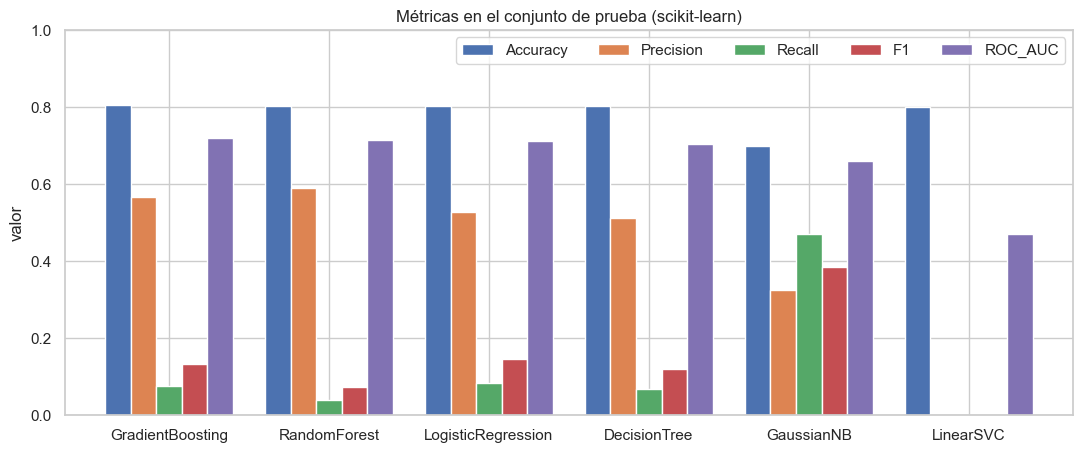

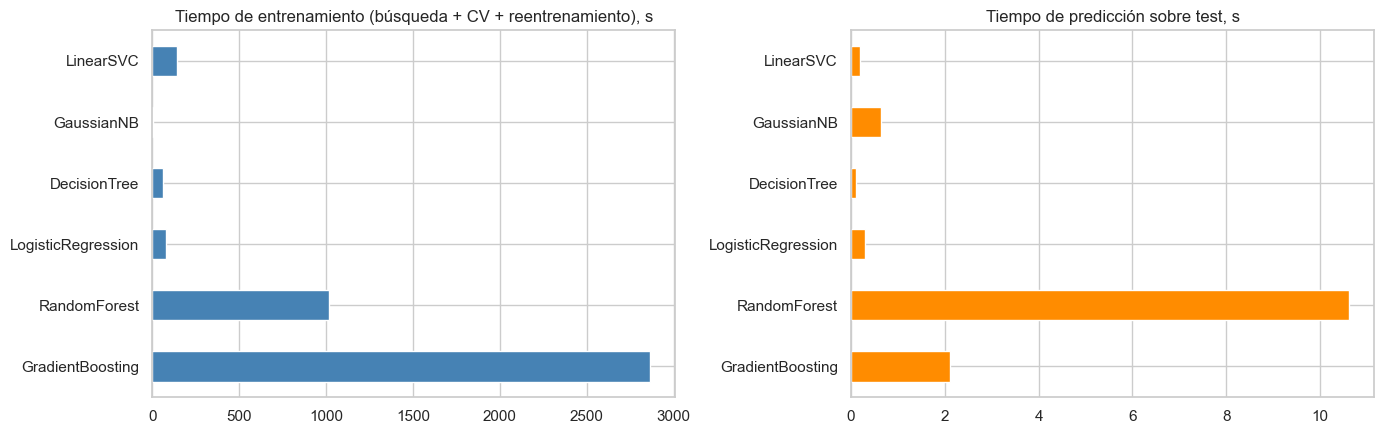

In [60]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
tabla_resultados[metricas].plot(kind='bar', figsize=(13, 5), width=0.8)
plt.title('Métricas en el conjunto de prueba (scikit-learn)')
plt.ylabel('valor')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='upper right', ncol=5)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
tabla_resultados['t_entrenamiento_s'].astype(float).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Tiempo de entrenamiento (búsqueda + CV + reentrenamiento), s')
tabla_resultados['t_prediccion_s'].astype(float).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Tiempo de predicción sobre test, s')
plt.tight_layout()
plt.show()

**Matrices de confusión** (umbral por defecto):

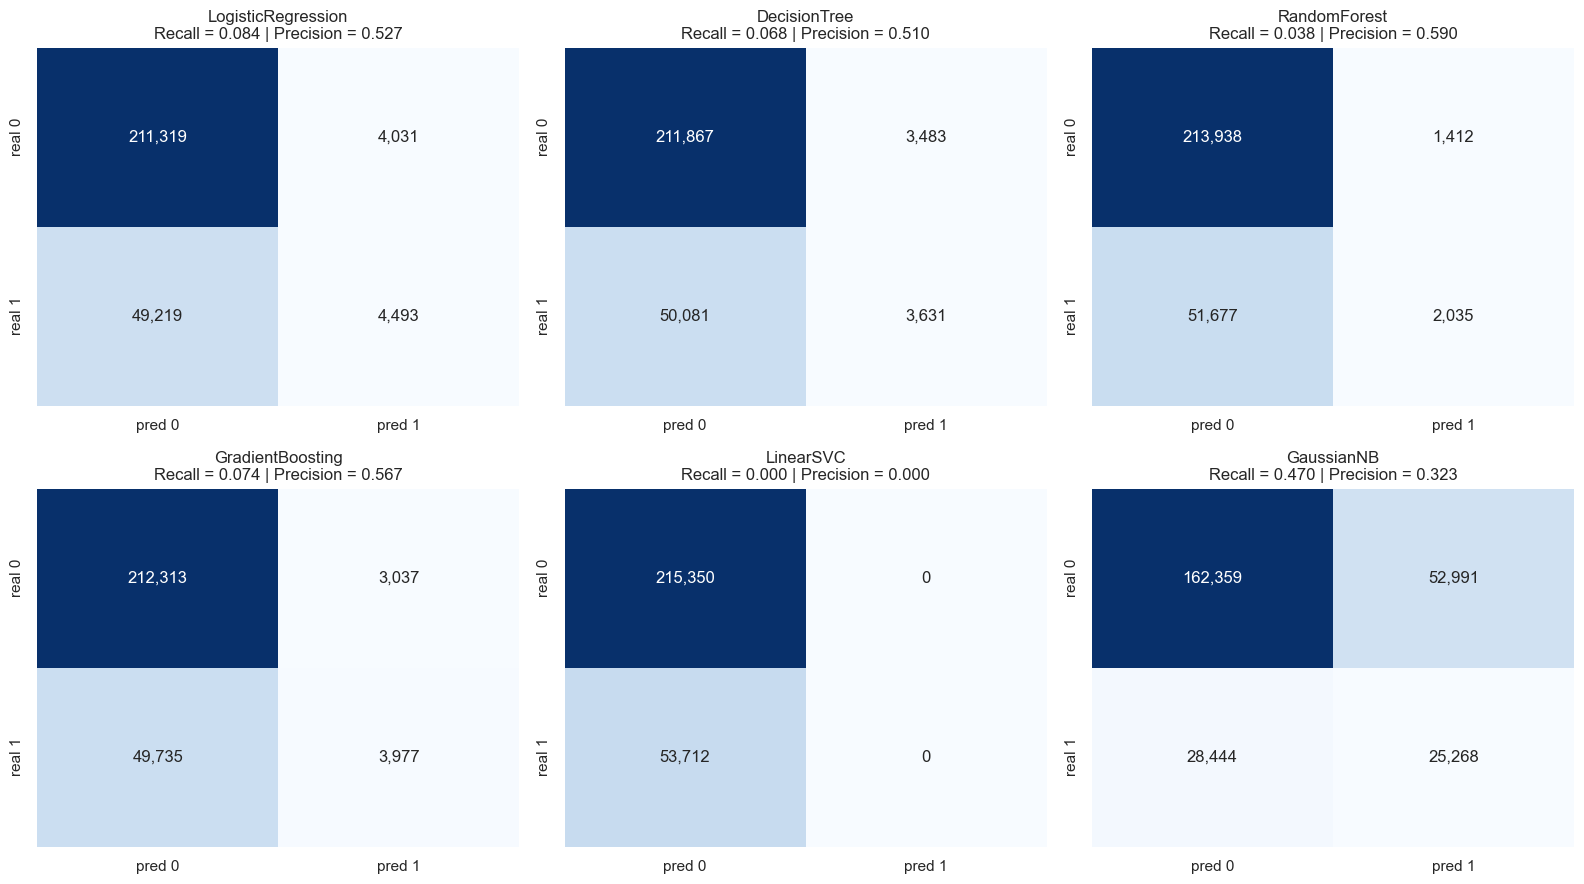

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (nombre, r) in zip(axes.flat, resultados.items()):
    mc = r['matriz_confusion']
    sns.heatmap(mc, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['pred 0', 'pred 1'], yticklabels=['real 0', 'real 1'])
    ax.set_title(f"{nombre}\nRecall = {r['Recall']:.3f} | Precision = {r['Precision']:.3f}")
plt.tight_layout()
plt.show()

**Curvas ROC** de los seis modelos sobre el mismo conjunto de prueba:

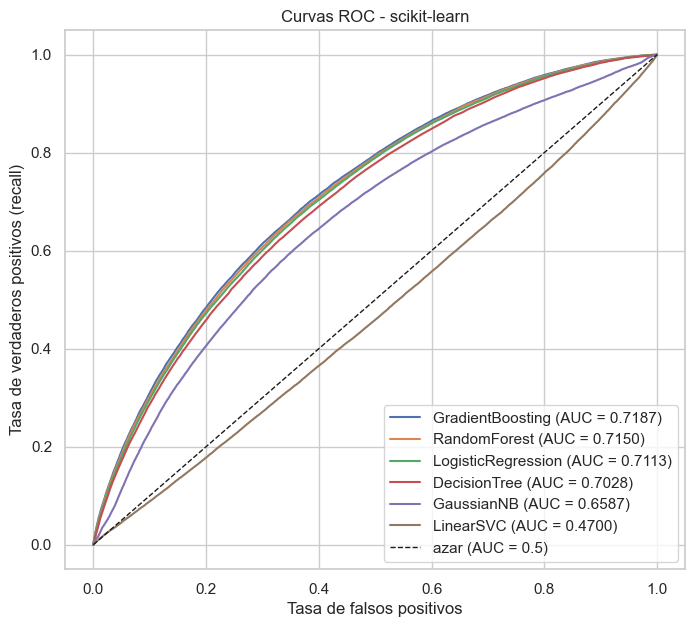

In [62]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))
for nombre in tabla_resultados.index:
    fpr, tpr, _ = roc_curve(y_test, scores_test[f'score_{nombre}'])
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {resultados[nombre]['ROC_AUC']:.4f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='azar (AUC = 0.5)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos (recall)')
plt.title('Curvas ROC - scikit-learn')
plt.legend(loc='lower right')
plt.show()

**Puntuaciones del conjunto de prueba para la prueba de DeLong.** Se guardan en un archivo con `id`, `default` y una columna de puntuación por modelo. PySpark generará un archivo equivalente, y ambos se pueden unir por `id`.

In [63]:
scores_test.to_csv('resultados/scores_test_sklearn.csv', index=False)
print(scores_test.shape)
scores_test.head()

(269062, 8)


,id,default,score_LogisticRegression,score_DecisionTree,score_RandomForest,score_GradientBoosting,score_LinearSVC,score_GaussianNB
0,68355089,0,0.179107,0.106372,0.177964,0.229127,-1.0,1.000000
1,68476807,0,0.379044,0.355928,0.339843,0.306131,-1.0,0.649466
2,68616873,0,0.129677,0.144953,0.126094,0.127847,-1.0,0.023406
3,68577849,0,0.067389,0.146294,0.103551,0.085420,-1.0,0.001217
4,67849662,1,0.173573,0.233482,0.192462,0.181132,-1.0,0.120758


**Comentario de los resultados.**

**Desempeño (ROC AUC en prueba):**

| Modelo | AUC test |
|---|---|
| GradientBoosting | **0.7187** |
| RandomForest | 0.7150 |
| LogisticRegression | 0.7113 |
| DecisionTree | 0.7028 |
| GaussianNB | 0.6587 |
| LinearSVC | 0.4700 (colapsa a la solución trivial, ver diagnóstico) |

- Los cuatro mejores modelos quedan en un rango de solo **0.016** de AUC. La regresión logística, que es lineal, queda a menos de 0.008 del mejor modelo de *boosting*. Esto concuerda con el EDA: ninguna variable separa las clases por sí sola, y las interacciones no lineales aportan poco. Si estas pequeñas diferencias son estadísticamente significativas y relevantes en la práctica se decidirá con la prueba de DeLong (9.10.4.6).
- El AUC de validación cruzada y el de prueba coinciden (prueba incluso ligeramente mayor, con desviaciones de CV de ~0.015), así que **no hay sobreajuste** en los modelos elegidos.
- **Hiperparámetros elegidos:**
  - En la regresión logística los tres valores de $C$ dan prácticamente el mismo AUC (0.7096-0.7097). Con un millón de observaciones, la regularización casi no influye.
  - El árbol de decisión mejora hasta `max_depth=10`, pero con `max_depth=15` **se sobreajusta** (AUC CV cae a 0.664).
  - En el bosque aleatorio y en *gradient boosting* gana la combinación de mayor capacidad (100 árboles, profundidad 15 y 5 respectivamente): promediar o combinar muchos árboles controla el sobreajuste que tiene un árbol profundo individual.

**Métricas con umbral 0.5 (clase positiva = default):**

- La **accuracy no sirve** para comparar: LinearSVC predice todo como "pagado" y obtiene 0.8004, prácticamente lo mismo que el mejor modelo (0.8039). Ese valor es simplemente la proporción de la clase mayoritaria.
- Con el umbral 0.5, los modelos basados en probabilidad detectan muy pocos defaults: **recall de apenas 4-8 %**, con precision de 51-59 %. Como solo el 20 % de los préstamos cae en default, casi ninguna probabilidad supera 0.5. Por eso el F1 es bajo (0.07-0.14). Es un problema del **umbral**, no de la capacidad de ordenamiento (el AUC es de ~0.71).
- GaussianNB tiene el mejor recall (0.47) y el mejor F1 (0.38), pero no porque ordene mejor, ya que su AUC es el más bajo de los modelos funcionales. Sus probabilidades están mal calibradas y muy cargadas hacia 0 y 1, así que más observaciones superan el umbral 0.5.
- **Conclusión práctica:** para usar estos modelos en decisiones de crédito habría que elegir un umbral menor que 0.5, **calculado solo con el conjunto de entrenamiento** (se hará para la prueba de McNemar en 9.10.4.6.2).

**Tiempos** (Intel i5-13420H, 8 núcleos físicos / 12 lógicos, 7.7 GB de RAM, `n_jobs=4`):

- `GradientBoostingClassifier` es con diferencia el más costoso: **2 867 s (≈ 48 min)** para la búsqueda completa, porque construye los árboles de forma secuencial y evalúa todos los cortes exactos.
- Le siguen RandomForest (1 018 s ≈ 17 min), LinearSVC (139 s), la regresión logística (80 s), el árbol de decisión (62 s) y GaussianNB (3 s).
- En predicción, el más lento es RandomForest (10.6 s, porque recorre 100 árboles de profundidad 15). Los demás tardan menos de 2.1 s en puntuar 269 mil préstamos.
- La relación costo/beneficio favorece a la **regresión logística**: logra un AUC a menos de 0.008 del mejor modelo en 36 veces menos tiempo.

**Archivos generados en `resultados/`** (para la prueba de DeLong y la comparación con PySpark):

- `particion_train_test.csv`: asignación `id` → `split`.
- `scores_test_sklearn.csv`: `id`, `default` y la puntuación continua de cada modelo en el conjunto de prueba.
- `metricas_sklearn.csv`: la tabla resumen de métricas y tiempos.